# 8/10 이후

- 변수 조합 1차 비교 및 후보 선정


4개 알고리즘별로 동일한 데이터 분할과 기본 학습 조건을 적용하여 5개 변수 조합을 비교하고, PR-AUC를 중심으로 성능이 우수한 조합 1~3개를 후보로 선정합니다. 알고리즘마다 변수 조합의 효과가 다를 수 있으므로 선정 결과는 달라도 되며, 조합 간 성능 차이가 미미하면 임의로 제외하지 않고 시간순 교차검증과 하이퍼파라미터 튜닝 단계에서 추가로 비교합니다.

In [4]:
## 라이브러리 불러오기

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

RANDOM_STATE = 42
TARGET = "is_fraud"
THRESHOLD = 0.9

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.7.0


In [7]:
## 데이터 불러오기

import os

DATA_PATH = DATA_PATH = r"C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\fraud_full_features.csv"  # BDAI/ 루트에서 실행 기준(팀 공통 경로)
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join("..", DATA_PATH)  # Modeling/ 등 하위 폴더에서 실행한 경우 보정

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["trans_date_trans_time"]
)

print("데이터 크기:", df.shape)
display(df.head())

데이터 크기: (1296675, 31)


,trans_date_trans_time,cc_num,merchant,category,amt,is_fraud,recent_24h_high_amt_count,category_recent_fraud_rate,category_recent_fraud_rate_missing,count_30min,...,amt_to_prior_median_ratio,is_10x_prior_median,has_prior_normal_transaction,outside_trans_hours_80,is_online,risk_time_22_04,interact_repeat_category,merchant_change_count,rolling_sum_amt_1h,is_high_amt
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,0,0,0.000000,0,0,...,NaN,0,0,0,1,0,0.0,0,7.27,0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,0,0,0.006154,0,1,...,7.281981,0,1,0,0,0,0.0,1,52.94,0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,0,0,0.006135,0,2,...,2.726457,0,1,0,0,0,0.0,1,135.02,0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,0,0,0.000000,0,1,...,0.657159,0,1,0,0,0,0.0,1,34.79,0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,0,0,0.000000,0,1,...,0.619628,0,1,0,0,0,0.0,1,61.97,0


In [65]:
## 모든 팀원이 공통으로 사용할 80:20 행 분할

# 전체 데이터의 행 위치
all_indices = np.arange(len(df))

# 전체 타깃
y_all = df[TARGET].astype(int)

# 이상거래 비율을 유지하는 층화 분할
train_idx, val_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_all
)

print("Train 크기:", f"{len(train_idx):,}")
print("Validation 크기:", f"{len(val_idx):,}")

Train 크기: 1,037,340
Validation 크기: 259,335


80:20 분할 잘 됨

In [66]:
## 분할이 제대로 되었는지 확인

y_train_common = y_all.iloc[train_idx]
y_val_common = y_all.iloc[val_idx]

print(
    f"Train 이상거래: {y_train_common.sum():,}건 "
    f"({y_train_common.mean():.4%})"
)

print(
    f"Validation 이상거래: {y_val_common.sum():,}건 "
    f"({y_val_common.mean():.4%})"
)

Train 이상거래: 6,005건 (0.5789%)
Validation 이상거래: 1,501건 (0.5788%)


train셋, val셋에서 이상거래율 비슷 OK

In [67]:
## train 데이터에서 scale_pos_weight(가중치) 계산

n_negative = (y_train_common == 0).sum()
n_positive = (y_train_common == 1).sum()

if n_positive == 0:
    raise ValueError(
        "Train 데이터에 이상거래가 없어 scale_pos_weight를 계산할 수 없습니다."
    )

scale_pos_weight = n_negative / n_positive

print(f"Train 정상거래 수: {n_negative:,}")
print(f"Train 이상거래 수: {n_positive:,}")
print(f"scale_pos_weight: {scale_pos_weight:.6f}")

Train 정상거래 수: 1,031,335
Train 이상거래 수: 6,005
scale_pos_weight: 171.746045


In [68]:
feature_combinations = {
    "조합1": [
        "category",
        "amt",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min"
    ],

    "조합2": [
        "category",
        "amt",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min",
        "merchant_change_count"
    ],

    "조합3": [
        "category",
        "amt",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min",
        "high_speed"
    ],

    "조합4": [
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "category",
        "amt",
        "trans_hour",
        "age"
    ],

    "조합5": [
        "category",
        "amt",
        "is_online",
        "recent_24h_high_amt_count",
        "category_recent_fraud_rate",
        "speed_2",
        "customer_mean_amt",
        "customer_std_amt",
        "amt_ratio_to_mean",
        "amt_zscore_card",
        "customer_transaction_count",
        "trans_hour",
        "age",
        "rolling_sum_amt_1h",
        "prior_normal_median_amt",
        "amt_to_prior_median_ratio",
        "risk_time_22_04",
        "interact_repeat_category",
        "has_prior_normal_transaction"
    ]
}

In [69]:
for combination_name, feature_list in feature_combinations.items():
    print(f"{combination_name}: {len(feature_list)}개 변수")
    print(feature_list)
    print()

조합1: 10개 변수
['category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card', 'prior_normal_median_amt', 'count_30min']

조합2: 11개 변수
['category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card', 'prior_normal_median_amt', 'count_30min', 'merchant_change_count']

조합3: 11개 변수
['category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card', 'prior_normal_median_amt', 'count_30min', 'high_speed']

조합4: 6개 변수
['recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'category', 'amt', 'trans_hour', 'age']

조합5: 19개 변수
['category', 'amt', 'is_online', 'recent_24h_high_amt_count', 'category_recent_fraud_rate', 'speed_2', 'customer_mean_amt', 'customer_std_amt', 'amt_ratio_to_mean', 'amt_zscore_card', 'customer_transaction_count', 'trans_hour', 'age', 'rolling_sum_amt_1

In [70]:
## csv에 누락된 변수가 있는지 확인

all_columns_exist = True

for combination_name, feature_list in feature_combinations.items():
    missing_columns = [
        column
        for column in feature_list
        if column not in df.columns
    ]

    if missing_columns:
        all_columns_exist = False
        print(f"❌ {combination_name} 누락 변수: {missing_columns}")
    else:
        print(f"✅ {combination_name}: 모든 변수 확인 완료")

if all_columns_exist:
    print("\n5개 조합에 필요한 변수가 모두 존재합니다.")
else:
    print("\n누락된 변수의 실제 열 이름을 확인해야 합니다.")

✅ 조합1: 모든 변수 확인 완료
✅ 조합2: 모든 변수 확인 완료
✅ 조합3: 모든 변수 확인 완료
✅ 조합4: 모든 변수 확인 완료
✅ 조합5: 모든 변수 확인 완료

5개 조합에 필요한 변수가 모두 존재합니다.


In [71]:
# 5개 조합에서 사용하는 전체 변수 목록
all_features = list(dict.fromkeys(
    feature
    for feature_list in feature_combinations.values()
    for feature in feature_list
))

print(f"중복 제외 전체 변수 수: {len(all_features)}개")

중복 제외 전체 변수 수: 22개


In [72]:
%pip install jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
feature_check_df = pd.DataFrame({
    "dtype": df[all_features].dtypes.astype(str),
    "결측치수": df[all_features].isna().sum(),
    "결측치비율_pct": (
        df[all_features].isna().mean() * 100
    ),
    "고유값수": df[all_features].nunique(dropna=False)
}).sort_values(
    by="결측치수",
    ascending=False
)

display(
    feature_check_df.style.format({
        "결측치비율_pct": "{:.4f}"
    })
)

,dtype,결측치수,결측치비율_pct,고유값수
amt_to_prior_median_ratio,float64,1649,0.1272,1247936
prior_normal_median_amt,float64,1649,0.1272,15827
amt,float64,0,0.0000,52928
trans_hour,int64,0,0.0000,24
age,int64,0,0.0000,83
category,str,0,0.0000,14
recent_24h_high_amt_count,int64,0,0.0000,10
rolling_sum_amt_1h,float64,0,0.0000,69038
amt_zscore_card,float64,0,0.0000,1294710
count_30min,int64,0,0.0000,6


실무적으로 각 모델의 최대 성능을 비교하려는 것이기 때문에,

category(현재 혼자 str 타입)을 원-핫 인코딩이 아닌, LightGBM 자체 범주형 처리로.

In [74]:
## lightGBM 자체 범주형 처리 (category 변수만)

def prepare_combination_data(
    df,
    feature_list,
    train_idx,
    val_idx,
    target="is_fraud"
):
    # 선택한 변수와 타깃 복사
    X_all = df[feature_list].copy()
    y_all = df[target].astype(int).copy()

    # LightGBM이 자체 처리할 범주형 변수
    categorical_features = []

    if "category" in X_all.columns:
        X_all["category"] = X_all["category"].astype("category")
        categorical_features.append("category")

    # 모든 조합에 동일한 행 분할 적용
    X_train = X_all.iloc[train_idx].copy()
    X_val = X_all.iloc[val_idx].copy()

    y_train = y_all.iloc[train_idx].copy()
    y_val = y_all.iloc[val_idx].copy()

    return {
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "categorical_features": categorical_features
    }

In [75]:
combination1_data = prepare_combination_data(
    df=df,
    feature_list=feature_combinations["조합1"],
    train_idx=train_idx,
    val_idx=val_idx,
    target=TARGET
)

print("Train 크기:", combination1_data["X_train"].shape)
print("Validation 크기:", combination1_data["X_val"].shape)

print("\nTrain 자료형:")
print(combination1_data["X_train"].dtypes)

print(
    "\n범주형 변수:",
    combination1_data["categorical_features"]
)

print(
    "\nTrain 결측치 수:",
    combination1_data["X_train"].isna().sum().sum()
)

print(
    "Validation 결측치 수:",
    combination1_data["X_val"].isna().sum().sum()
)

print(
    "\nTrain 이상거래율:",
    combination1_data["y_train"].mean()
)

print(
    "Validation 이상거래율:",
    combination1_data["y_val"].mean()
)

Train 크기: (1037340, 10)
Validation 크기: (259335, 10)

Train 자료형:
category                     category
amt                           float64
trans_hour                      int64
age                             int64
recent_24h_high_amt_count       int64
amt_to_prior_median_ratio     float64
rolling_sum_amt_1h            float64
amt_zscore_card               float64
prior_normal_median_amt       float64
count_30min                     int64
dtype: object

범주형 변수: ['category']

Train 결측치 수: 2636
Validation 결측치 수: 662

Train 이상거래율: 0.00578884454470087
Validation 이상거래율: 0.005787880540613492


결측치 수는 prior_normal_median_amt, amt_to_prior_median_ratio의 NaN이기 때문에 ㄱㅊ음

In [76]:
from sklearn import set_config

set_config(display="text")

## 조합1 (민정 Model 40)

In [77]:
from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

model_combination1_v2 = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model_combination1_v2.fit(
    combination1_data["X_train"],
    combination1_data["y_train"],
    eval_set=[
        (
            combination1_data["X_val"],
            combination1_data["y_val"]
        )
    ],
    eval_metric="auc",
    categorical_feature=combination1_data["categorical_features"],
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=True
        ),
        log_evaluation(period=100)
    ]
);

Training until validation scores don't improve for 100 rounds

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



[100]	valid_0's auc: 0.998823
[200]	valid_0's auc: 0.999258
[300]	valid_0's auc: 0.999404
[400]	valid_0's auc: 0.99944
[500]	valid_0's auc: 0.999451
Early stopping, best iteration is:
[492]	valid_0's auc: 0.999456
Evaluated only: auc


In [78]:
print("최적 반복 횟수:", model_combination1_v2.best_iteration_)
print("최적 점수:")
print(model_combination1_v2.best_score_)
print("평가 지표:")
print(model_combination1_v2.evals_result_.keys())
print(model_combination1_v2.evals_result_["valid_0"].keys())

최적 반복 횟수: 492
최적 점수:
defaultdict(<class 'collections.OrderedDict'>, {'valid_0': OrderedDict({'auc': np.float64(0.9994557772807843)})})
평가 지표:
dict_keys(['valid_0'])
odict_keys(['auc'])


In [79]:
## 492개 트리를 사용한 예측확률로 임계값 0.90 성능을 계산
## 하기 전에,  예측확률을 변수에 저장만 하는 코드.

val_probability_combination1_v2 = (
    model_combination1_v2.predict_proba(
        combination1_data["X_val"],
        num_iteration=model_combination1_v2.best_iteration_
    )[:, 1]
)

In [80]:
import numpy as np

print("예측확률 개수:", len(val_probability_combination1_v2))
print("Validation 행 수:", len(combination1_data["X_val"]))

print("최소 확률:", val_probability_combination1_v2.min())
print("최대 확률:", val_probability_combination1_v2.max())
print("평균 확률:", val_probability_combination1_v2.mean())

print("\n확률 분위수:")
print(
    np.quantile(
        val_probability_combination1_v2,
        [0, 0.5, 0.9, 0.99, 0.995, 0.999, 1.0]
    )
)

예측확률 개수: 259335
Validation 행 수: 259335
최소 확률: 4.661481550417692e-09
최대 확률: 0.9999905373099288
평균 확률: 0.0114293834569628

확률 분위수:
[4.66148155e-09 7.87283149e-05 2.62484883e-03 4.09374977e-01
 9.92786506e-01 9.99934335e-01 9.99990537e-01]


In [81]:
## 공통 임계값 0.90 적용해서  성능 확인.

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

COMMON_THRESHOLD = 0.90

y_val_combination1 = combination1_data["y_val"].to_numpy()

val_prediction_combination1_v2 = (
    val_probability_combination1_v2 >= COMMON_THRESHOLD
).astype(int)

precision_v2 = precision_score(
    y_val_combination1,
    val_prediction_combination1_v2,
    zero_division=0
)

recall_v2 = recall_score(
    y_val_combination1,
    val_prediction_combination1_v2,
    zero_division=0
)

f1_v2 = f1_score(
    y_val_combination1,
    val_prediction_combination1_v2,
    zero_division=0
)

roc_auc_v2 = roc_auc_score(
    y_val_combination1,
    val_probability_combination1_v2
)

pr_auc_v2 = average_precision_score(
    y_val_combination1,
    val_probability_combination1_v2
)

tn, fp, fn, tp = confusion_matrix(
    y_val_combination1,
    val_prediction_combination1_v2,
    labels=[0, 1]
).ravel()

print(f"최적 반복 횟수: {model_combination1_v2.best_iteration_}")
print(f"공통 임계값: {COMMON_THRESHOLD:.2f}")
print(f"Precision: {precision_v2:.6f}")
print(f"Recall: {recall_v2:.6f}")
print(f"F1-score: {f1_v2:.6f}")
print(f"ROC-AUC: {roc_auc_v2:.6f}")
print(f"PR-AUC: {pr_auc_v2:.6f}")

print("\nConfusion Matrix")
print(f"TN: {tn:,}")
print(f"FP: {fp:,}")
print(f"FN: {fn:,}")
print(f"TP: {tp:,}")

print("\n예측 결과")
print("실제 이상거래 수:", int(y_val_combination1.sum()))
print("예측 이상거래 수:", int(val_prediction_combination1_v2.sum()))

최적 반복 횟수: 492
공통 임계값: 0.90
Precision: 0.899685
Recall: 0.950033
F1-score: 0.924174
ROC-AUC: 0.999456
PR-AUC: 0.972656

Confusion Matrix
TN: 257,675
FP: 159
FN: 75
TP: 1,426

예측 결과
실제 이상거래 수: 1501
예측 이상거래 수: 1585


- 실제 이상거래 1,501건 중 1,426건을 탐지.
- 이상거래를 75건 놓쳤고, 
- 정상거래 159건을 이상거래로 오탐.

##### 다시 한 번 짚고 넘어가는 'lightGBM 기본 설정'
- 동일한 Train/Validation 인덱스
- n_estimators=3000
- learning_rate=0.03
- 동일한 하이퍼파라미터와 scale_pos_weight
- eval_metric="auc"
- early_stopping=100
- first_metric_only=True
- 공통 임계값 0.90
- category는 LightGBM 자체 범주형 처리

## 조합 2 (민정 모델 42)

In [82]:
## 조합2 데이터 준비

combination2_data = prepare_combination_data(
    df=df,
    feature_list=feature_combinations["조합2"],
    train_idx=train_idx,
    val_idx=val_idx,
    target=TARGET
)

print("조합2 변수:")
print(feature_combinations["조합2"])

print("\nTrain 크기:", combination2_data["X_train"].shape)
print("Validation 크기:", combination2_data["X_val"].shape)

print("\n자료형:")
print(combination2_data["X_train"].dtypes)

print(
    "\n범주형 변수:",
    combination2_data["categorical_features"]
)

print(
    "Train/Validation 행 수 일치:",
    len(combination2_data["X_train"]) == len(combination1_data["X_train"])
    and len(combination2_data["X_val"]) == len(combination1_data["X_val"])
)

조합2 변수:
['category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card', 'prior_normal_median_amt', 'count_30min', 'merchant_change_count']

Train 크기: (1037340, 11)
Validation 크기: (259335, 11)

자료형:
category                     category
amt                           float64
trans_hour                      int64
age                             int64
recent_24h_high_amt_count       int64
amt_to_prior_median_ratio     float64
rolling_sum_amt_1h            float64
amt_zscore_card               float64
prior_normal_median_amt       float64
count_30min                     int64
merchant_change_count           int64
dtype: object

범주형 변수: ['category']
Train/Validation 행 수 일치: True


In [83]:
## 학습
# 
from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

model_combination2 = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model_combination2.fit(
    combination2_data["X_train"],
    combination2_data["y_train"],
    eval_set=[
        (
            combination2_data["X_val"],
            combination2_data["y_val"]
        )
    ],
    eval_metric="auc",
    categorical_feature=combination2_data["categorical_features"],
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=True
        ),
        log_evaluation(period=100)
    ]
);

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.998823
[200]	valid_0's auc: 0.999258
[300]	valid_0's auc: 0.999379
[400]	valid_0's auc: 0.999413
[500]	valid_0's auc: 0.999397
Early stopping, best iteration is:
[412]	valid_0's auc: 0.999419
Evaluated only: auc


In [84]:
print("최적 반복 횟수:", model_combination2.best_iteration_)
print("최적 Validation ROC-AUC:")
print(model_combination2.best_score_["valid_0"]["auc"])

최적 반복 횟수: 412
최적 Validation ROC-AUC:
0.9994186618489438


In [85]:
## validation 예측확률 생성

import numpy as np

val_probability_combination2 = model_combination2.predict_proba(
    combination2_data["X_val"],
    num_iteration=model_combination2.best_iteration_
)[:, 1]

print("예측확률 개수:", len(val_probability_combination2))
print("Validation 행 수:", len(combination2_data["X_val"]))
print("최소 확률:", val_probability_combination2.min())
print("최대 확률:", val_probability_combination2.max())
print("평균 확률:", val_probability_combination2.mean())

print("\n확률 분위수:")
print(
    np.quantile(
        val_probability_combination2,
        [0, 0.5, 0.9, 0.99, 0.995, 0.999, 1.0]
    )
)

예측확률 개수: 259335
Validation 행 수: 259335
최소 확률: 3.064396598151915e-08
최대 확률: 0.9999800962378019
평균 확률: 0.012361333401292515

확률 분위수:
[3.06439660e-08 1.22323898e-04 3.48835373e-03 4.67683051e-01
 9.92596283e-01 9.99887321e-01 9.99980096e-01]


In [86]:
## 공통 임계값 0.90으로 평가

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

COMMON_THRESHOLD = 0.90

y_val_combination2 = combination2_data["y_val"].to_numpy()

val_prediction_combination2 = (
    val_probability_combination2 >= COMMON_THRESHOLD
).astype(int)

precision_combination2 = precision_score(
    y_val_combination2,
    val_prediction_combination2,
    zero_division=0
)

recall_combination2 = recall_score(
    y_val_combination2,
    val_prediction_combination2,
    zero_division=0
)

f1_combination2 = f1_score(
    y_val_combination2,
    val_prediction_combination2,
    zero_division=0
)

roc_auc_combination2 = roc_auc_score(
    y_val_combination2,
    val_probability_combination2
)

pr_auc_combination2 = average_precision_score(
    y_val_combination2,
    val_probability_combination2
)

tn2, fp2, fn2, tp2 = confusion_matrix(
    y_val_combination2,
    val_prediction_combination2,
    labels=[0, 1]
).ravel()

print(f"최적 반복 횟수: {model_combination2.best_iteration_}")
print(f"공통 임계값: {COMMON_THRESHOLD:.2f}")
print(f"Precision: {precision_combination2:.6f}")
print(f"Recall: {recall_combination2:.6f}")
print(f"F1-score: {f1_combination2:.6f}")
print(f"ROC-AUC: {roc_auc_combination2:.6f}")
print(f"PR-AUC: {pr_auc_combination2:.6f}")

print("\nConfusion Matrix")
print(f"TN: {tn2:,}")
print(f"FP: {fp2:,}")
print(f"FN: {fn2:,}")
print(f"TP: {tp2:,}")

print("\n예측 결과")
print("실제 이상거래 수:", int(y_val_combination2.sum()))
print("예측 이상거래 수:", int(val_prediction_combination2.sum()))

최적 반복 횟수: 412
공통 임계값: 0.90
Precision: 0.884758
Recall: 0.951366
F1-score: 0.916854
ROC-AUC: 0.999419
PR-AUC: 0.971890

Confusion Matrix
TN: 257,648
FP: 186
FN: 73
TP: 1,428

예측 결과
실제 이상거래 수: 1501
예측 이상거래 수: 1614


조합2는 조합1보다 이상거래를 2건 더 탐지했지만, 정상거래를 이상거래로 잘못 잡은 건수가 27건 증가함. 

그 결과 Precision과 F1-score가 낮아짐.

현재 순위
1. 조합1 (F1 : 0.924174)
2. 조합2 (F1 : 0.916854)

### 조합 3 (민정 모델 44)

In [87]:
## 조합3 데이터 준비

combination3_data = prepare_combination_data(
    df=df,
    feature_list=feature_combinations["조합3"],
    train_idx=train_idx,
    val_idx=val_idx,
    target=TARGET
)

print("조합3 변수:")
print(feature_combinations["조합3"])

print("\nTrain 크기:", combination3_data["X_train"].shape)
print("Validation 크기:", combination3_data["X_val"].shape)
print("\n범주형 변수:", combination3_data["categorical_features"])

print(
    "조합1과 행 수 일치:",
    len(combination3_data["X_train"]) == len(combination1_data["X_train"])
    and len(combination3_data["X_val"]) == len(combination1_data["X_val"])
)

조합3 변수:
['category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card', 'prior_normal_median_amt', 'count_30min', 'high_speed']

Train 크기: (1037340, 11)
Validation 크기: (259335, 11)

범주형 변수: ['category']
조합1과 행 수 일치: True


In [88]:
## 학습

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

model_combination3 = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model_combination3.fit(
    combination3_data["X_train"],
    combination3_data["y_train"],
    eval_set=[
        (
            combination3_data["X_val"],
            combination3_data["y_val"]
        )
    ],
    eval_metric="auc",
    categorical_feature=combination3_data["categorical_features"],
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=True
        ),
        log_evaluation(period=100)
    ]
);

print("최적 반복 횟수:", model_combination3.best_iteration_)
print(
    "최적 Validation ROC-AUC:",
    model_combination3.best_score_["valid_0"]["auc"]
)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.998815
[200]	valid_0's auc: 0.999292
[300]	valid_0's auc: 0.999422
[400]	valid_0's auc: 0.999452
Early stopping, best iteration is:
[381]	valid_0's auc: 0.999456
Evaluated only: auc
최적 반복 횟수: 381
최적 Validation ROC-AUC: 0.9994561687447165


In [89]:
## validation 예측확률 생성

import numpy as np

val_probability_combination3 = model_combination3.predict_proba(
    combination3_data["X_val"],
    num_iteration=model_combination3.best_iteration_
)[:, 1]

print("예측확률 개수:", len(val_probability_combination3))
print("Validation 행 수:", len(combination3_data["X_val"]))
print("최소 확률:", val_probability_combination3.min())
print("최대 확률:", val_probability_combination3.max())
print("평균 확률:", val_probability_combination3.mean())

print("\n확률 분위수:")
print(
    np.quantile(
        val_probability_combination3,
        [0, 0.5, 0.9, 0.99, 0.995, 0.999, 1.0]
    )
)

예측확률 개수: 259335
Validation 행 수: 259335
최소 확률: 1.1469886671787456e-08
최대 확률: 0.9999572619584892
평균 확률: 0.01267587553611143

확률 분위수:
[1.14698867e-08 1.48775063e-04 3.81707442e-03 4.78184645e-01
 9.92843992e-01 9.99852965e-01 9.99957262e-01]


In [90]:
## 공통 임계값 0.90으로 평가

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

COMMON_THRESHOLD = 0.90

y_val_combination3 = combination3_data["y_val"].to_numpy()

val_prediction_combination3 = (
    val_probability_combination3 >= COMMON_THRESHOLD
).astype(int)

precision_combination3 = precision_score(
    y_val_combination3,
    val_prediction_combination3,
    zero_division=0
)

recall_combination3 = recall_score(
    y_val_combination3,
    val_prediction_combination3,
    zero_division=0
)

f1_combination3 = f1_score(
    y_val_combination3,
    val_prediction_combination3,
    zero_division=0
)

roc_auc_combination3 = roc_auc_score(
    y_val_combination3,
    val_probability_combination3
)

pr_auc_combination3 = average_precision_score(
    y_val_combination3,
    val_probability_combination3
)

tn3, fp3, fn3, tp3 = confusion_matrix(
    y_val_combination3,
    val_prediction_combination3,
    labels=[0, 1]
).ravel()

print(f"최적 반복 횟수: {model_combination3.best_iteration_}")
print(f"공통 임계값: {COMMON_THRESHOLD:.2f}")
print(f"Precision: {precision_combination3:.6f}")
print(f"Recall: {recall_combination3:.6f}")
print(f"F1-score: {f1_combination3:.6f}")
print(f"ROC-AUC: {roc_auc_combination3:.6f}")
print(f"PR-AUC: {pr_auc_combination3:.6f}")

print("\nConfusion Matrix")
print(f"TN: {tn3:,}")
print(f"FP: {fp3:,}")
print(f"FN: {fn3:,}")
print(f"TP: {tp3:,}")

print("\n예측 결과")
print("실제 이상거래 수:", int(y_val_combination3.sum()))
print("예측 이상거래 수:", int(val_prediction_combination3.sum()))

최적 반복 횟수: 381
공통 임계값: 0.90
Precision: 0.878844
Recall: 0.952032
F1-score: 0.913975
ROC-AUC: 0.999456
PR-AUC: 0.971038

Confusion Matrix
TN: 257,637
FP: 197
FN: 72
TP: 1,429

예측 결과
실제 이상거래 수: 1501
예측 이상거래 수: 1626


조합3은 조합1보다 이상거래를 3건 더 탐지했지만, 오탐은 38건 더 발생. 이 때문에 Recall은 가장 높지만 Precision과 F1-score는 가장 낮음.

현재 F1-score 순위: 
1. 조합1: 0.924174
2. 조합2: 0.916854
3. 조합3: 0.913975

#### 조합 3개가 모두 최적 iteration이 500이 안 되길래, early_stopping = 200으로 재학습해서 성능 유의미하게 좋아지는지 조합1만 먼저 확인하기 위한 실험.

In [91]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

model_combination1_es200 = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model_combination1_es200.fit(
    combination1_data["X_train"],
    combination1_data["y_train"],
    eval_set=[
        (
            combination1_data["X_val"],
            combination1_data["y_val"]
        )
    ],
    eval_metric="auc",
    categorical_feature=combination1_data["categorical_features"],
    callbacks=[
        early_stopping(
            stopping_rounds=200,
            first_metric_only=True,
            verbose=True
        ),
        log_evaluation(period=100)
    ]
);

print("기존 최적 반복:", model_combination1_v2.best_iteration_)
print("기존 최고 ROC-AUC:",
      model_combination1_v2.best_score_["valid_0"]["auc"])

print("\nES 200 최적 반복:",
      model_combination1_es200.best_iteration_)
print("ES 200 최고 ROC-AUC:",
      model_combination1_es200.best_score_["valid_0"]["auc"])

Training until validation scores don't improve for 200 rounds

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



[100]	valid_0's auc: 0.998823
[200]	valid_0's auc: 0.999258
[300]	valid_0's auc: 0.999404
[400]	valid_0's auc: 0.99944
[500]	valid_0's auc: 0.999451
[600]	valid_0's auc: 0.999388
Early stopping, best iteration is:
[492]	valid_0's auc: 0.999456
Evaluated only: auc
기존 최적 반복: 492
기존 최고 ROC-AUC: 0.9994557772807843

ES 200 최적 반복: 492
ES 200 최고 ROC-AUC: 0.9994557772807843


early stopping을 200으로 늘려도 똑같음. 트리를 500개 이상 만들지 않은 게, 학습 부족이 원인이 아니었음. 기존대로 100 ㄱㄱ

## 조합 4 (다영님 모델)

In [92]:
## 조합4 데이터 준비

combination4_data = prepare_combination_data(
    df=df,
    feature_list=feature_combinations["조합4"],
    train_idx=train_idx,
    val_idx=val_idx,
    target=TARGET
)

print("조합4 변수:")
print(feature_combinations["조합4"])

print("\nTrain 크기:", combination4_data["X_train"].shape)
print("Validation 크기:", combination4_data["X_val"].shape)
print("\n범주형 변수:", combination4_data["categorical_features"])

print(
    "조합1과 행 수 일치:",
    len(combination4_data["X_train"]) == len(combination1_data["X_train"])
    and len(combination4_data["X_val"]) == len(combination1_data["X_val"])
)

조합4 변수:
['recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'category', 'amt', 'trans_hour', 'age']

Train 크기: (1037340, 6)
Validation 크기: (259335, 6)

범주형 변수: ['category']
조합1과 행 수 일치: True


In [93]:
## 학습

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

model_combination4 = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model_combination4.fit(
    combination4_data["X_train"],
    combination4_data["y_train"],
    eval_set=[
        (
            combination4_data["X_val"],
            combination4_data["y_val"]
        )
    ],
    eval_metric="auc",
    categorical_feature=combination4_data["categorical_features"],
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=True
        ),
        log_evaluation(period=100)
    ]
)

print("최적 반복 횟수:", model_combination4.best_iteration_)
print(
    "최적 Validation ROC-AUC:",
    model_combination4.best_score_["valid_0"]["auc"]
)

Training until validation scores don't improve for 100 rounds


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[100]	valid_0's auc: 0.998984
[200]	valid_0's auc: 0.999288
[300]	valid_0's auc: 0.999359
[400]	valid_0's auc: 0.999358
Early stopping, best iteration is:
[343]	valid_0's auc: 0.999372
Evaluated only: auc
최적 반복 횟수: 343
최적 Validation ROC-AUC: 0.999372378667718


In [94]:
## validation 예측확률 생성

import numpy as np

val_probability_combination4 = model_combination4.predict_proba(
    combination4_data["X_val"],
    num_iteration=model_combination4.best_iteration_
)[:, 1]

print("예측확률 개수:", len(val_probability_combination4))
print("Validation 행 수:", len(combination4_data["X_val"]))
print("최소 확률:", val_probability_combination4.min())
print("최대 확률:", val_probability_combination4.max())
print("평균 확률:", val_probability_combination4.mean())

print("\n확률 분위수:")
print(
    np.quantile(
        val_probability_combination4,
        [0, 0.5, 0.9, 0.99, 0.995, 0.999, 1.0]
    )
)

예측확률 개수: 259335
Validation 행 수: 259335
최소 확률: 2.608190268090454e-07
최대 확률: 0.9999477841498874
평균 확률: 0.015166390084457025

확률 분위수:
[2.60819027e-07 2.07452103e-04 3.92909549e-03 6.80076986e-01
 9.91777280e-01 9.99845758e-01 9.99947784e-01]


In [95]:
## 공통 임계값 0.90으로 평가

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

COMMON_THRESHOLD = 0.90

y_val_combination4 = combination4_data["y_val"].to_numpy()

val_prediction_combination4 = (
    val_probability_combination4 >= COMMON_THRESHOLD
).astype(int)

precision_combination4 = precision_score(
    y_val_combination4,
    val_prediction_combination4,
    zero_division=0
)

recall_combination4 = recall_score(
    y_val_combination4,
    val_prediction_combination4,
    zero_division=0
)

f1_combination4 = f1_score(
    y_val_combination4,
    val_prediction_combination4,
    zero_division=0
)

roc_auc_combination4 = roc_auc_score(
    y_val_combination4,
    val_probability_combination4
)

pr_auc_combination4 = average_precision_score(
    y_val_combination4,
    val_probability_combination4
)

tn4, fp4, fn4, tp4 = confusion_matrix(
    y_val_combination4,
    val_prediction_combination4,
    labels=[0, 1]
).ravel()

print(f"최적 반복 횟수: {model_combination4.best_iteration_}")
print(f"공통 임계값: {COMMON_THRESHOLD:.2f}")
print(f"Precision: {precision_combination4:.6f}")
print(f"Recall: {recall_combination4:.6f}")
print(f"F1-score: {f1_combination4:.6f}")
print(f"ROC-AUC: {roc_auc_combination4:.6f}")
print(f"PR-AUC: {pr_auc_combination4:.6f}")

print("\nConfusion Matrix")
print(f"TN: {tn4:,}")
print(f"FP: {fp4:,}")
print(f"FN: {fn4:,}")
print(f"TP: {tp4:,}")

print("\n예측 결과")
print("실제 이상거래 수:", int(y_val_combination4.sum()))
print("예측 이상거래 수:", int(val_prediction_combination4.sum()))

최적 반복 횟수: 343
공통 임계값: 0.90
Precision: 0.806215
Recall: 0.950700
F1-score: 0.872516
ROC-AUC: 0.999372
PR-AUC: 0.965424

Confusion Matrix
TN: 257,491
FP: 343
FN: 74
TP: 1,427

예측 결과
실제 이상거래 수: 1501
예측 이상거래 수: 1770


이상거래를 1건 더 탐지, 오탐이 184건 증가.
Precision이 약 9.35%p 감소

현재 F1-score 순위는:

1. 조합1: 0.924174
2. 조합2: 0.916854
3. 조합3: 0.913975
4. 조합4: 0.872516

## 조합 5 (나겸님 모델)

In [96]:
## 조합 5 데이터 준비

combination5_data = prepare_combination_data(
    df=df,
    feature_list=feature_combinations["조합5"],
    train_idx=train_idx,
    val_idx=val_idx,
    target=TARGET
)

print("조합5 변수:")
print(feature_combinations["조합5"])

print("\nTrain 크기:", combination5_data["X_train"].shape)
print("Validation 크기:", combination5_data["X_val"].shape)
print("\n범주형 변수:", combination5_data["categorical_features"])

print(
    "조합1과 행 수 일치:",
    len(combination5_data["X_train"]) == len(combination1_data["X_train"])
    and len(combination5_data["X_val"]) == len(combination1_data["X_val"])
)

조합5 변수:
['category', 'amt', 'is_online', 'recent_24h_high_amt_count', 'category_recent_fraud_rate', 'speed_2', 'customer_mean_amt', 'customer_std_amt', 'amt_ratio_to_mean', 'amt_zscore_card', 'customer_transaction_count', 'trans_hour', 'age', 'rolling_sum_amt_1h', 'prior_normal_median_amt', 'amt_to_prior_median_ratio', 'risk_time_22_04', 'interact_repeat_category', 'has_prior_normal_transaction']

Train 크기: (1037340, 19)
Validation 크기: (259335, 19)

범주형 변수: ['category']
조합1과 행 수 일치: True


In [97]:
from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

model_combination5 = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model_combination5.fit(
    combination5_data["X_train"],
    combination5_data["y_train"],
    eval_set=[
        (
            combination5_data["X_val"],
            combination5_data["y_val"]
        )
    ],
    eval_metric="auc",
    categorical_feature=combination5_data["categorical_features"],
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=True
        ),
        log_evaluation(period=100)
    ]
)

print("최적 반복 횟수:", model_combination5.best_iteration_)
print(
    "최적 Validation ROC-AUC:",
    model_combination5.best_score_["valid_0"]["auc"]
)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.998278
[200]	valid_0's auc: 0.999048
[300]	valid_0's auc: 0.999314
[400]	valid_0's auc: 0.999459
[500]	valid_0's auc: 0.999545
[600]	valid_0's auc: 0.999602
[700]	valid_0's auc: 0.999621
[800]	valid_0's auc: 0.999637
[900]	valid_0's auc: 0.999654
[1000]	valid_0's auc: 0.999671
[1100]	valid_0's auc: 0.999688
[1200]	valid_0's auc: 0.999703
[1300]	valid_0's auc: 0.999719
[1400]	valid_0's auc: 0.999731
[1500]	valid_0's auc: 0.999744
[1600]	valid_0's auc: 0.999748
[1700]	valid_0's auc: 0.99975
Early stopping, best iteration is:
[1680]	valid_0's auc: 0.999751
Evaluated only: auc
최적 반복 횟수: 1680
최적 Validation ROC-AUC: 0.9997505250745775


In [98]:
import numpy as np

val_probability_combination5 = model_combination5.predict_proba(
    combination5_data["X_val"],
    num_iteration=model_combination5.best_iteration_
)[:, 1]

print("예측확률 개수:", len(val_probability_combination5))
print("Validation 행 수:", len(combination5_data["X_val"]))
print("최소 확률:", val_probability_combination5.min())
print("최대 확률:", val_probability_combination5.max())
print("평균 확률:", val_probability_combination5.mean())

print("\n확률 분위수:")
print(
    np.quantile(
        val_probability_combination5,
        [0, 0.5, 0.9, 0.99, 0.995, 0.999, 1.0]
    )
)

예측확률 개수: 259335
Validation 행 수: 259335
최소 확률: 2.1003004960688718e-13
최대 확률: 0.9999999997525739
평균 확률: 0.006356377687915276

확률 분위수:
[2.10030050e-13 2.35975817e-07 3.54820289e-05 1.76913952e-02
 9.96464774e-01 9.99999697e-01 1.00000000e+00]


In [99]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

COMMON_THRESHOLD = 0.90

y_val_combination5 = combination5_data["y_val"].to_numpy()

val_prediction_combination5 = (
    val_probability_combination5 >= COMMON_THRESHOLD
).astype(int)

precision_combination5 = precision_score(
    y_val_combination5,
    val_prediction_combination5,
    zero_division=0
)

recall_combination5 = recall_score(
    y_val_combination5,
    val_prediction_combination5,
    zero_division=0
)

f1_combination5 = f1_score(
    y_val_combination5,
    val_prediction_combination5,
    zero_division=0
)

roc_auc_combination5 = roc_auc_score(
    y_val_combination5,
    val_probability_combination5
)

pr_auc_combination5 = average_precision_score(
    y_val_combination5,
    val_probability_combination5
)

tn5, fp5, fn5, tp5 = confusion_matrix(
    y_val_combination5,
    val_prediction_combination5,
    labels=[0, 1]
).ravel()

print(f"최적 반복 횟수: {model_combination5.best_iteration_}")
print(f"공통 임계값: {COMMON_THRESHOLD:.2f}")
print(f"Precision: {precision_combination5:.6f}")
print(f"Recall: {recall_combination5:.6f}")
print(f"F1-score: {f1_combination5:.6f}")
print(f"ROC-AUC: {roc_auc_combination5:.6f}")
print(f"PR-AUC: {pr_auc_combination5:.6f}")

print("\nConfusion Matrix")
print(f"TN: {tn5:,}")
print(f"FP: {fp5:,}")
print(f"FN: {fn5:,}")
print(f"TP: {tp5:,}")

print("\n예측 결과")
print("실제 이상거래 수:", int(y_val_combination5.sum()))
print("예측 이상거래 수:", int(val_prediction_combination5.sum()))

최적 반복 횟수: 1680
공통 임계값: 0.90
Precision: 0.968793
Recall: 0.930713
F1-score: 0.949371
ROC-AUC: 0.999751
PR-AUC: 0.982701

Confusion Matrix
TN: 257,789
FP: 45
FN: 104
TP: 1,397

예측 결과
실제 이상거래 수: 1501
예측 이상거래 수: 1442


현재까지 1위였던 조합 1과 비교하면,

조합 5는
- 오탐(FP) 114건 감소 -> Precision 약 6.91%p 상승
- 미탐(FN) 29건 증가 -> Recall 약 1.93%p 하락

조합5는 정상거래를 이상거래로 잘못 탐지하는 문제를 크게 줄인 대신, 이상거래를 조금 더 놓치는 결과.

### 최종 F1 순위는:

1. 조합5: 0.949371 <- 선택.
2. 조합1: 0.924174
3. 조합2: 0.916854
4. 조합3: 0.913975
5. 조합4: 0.872516

## 2. 시간순 교차검증 및 하이퍼파라미터 튜닝

시간순 Fold를 나누기 전에 데이터의 시간 범위와 월별 이상거래 분포부터 확인

In [100]:
### 월별 거래 건수·이상거래 수·이상거래율 확인 코드

import pandas as pd

TIME_COL = "trans_date_trans_time"
TARGET = "is_fraud"

# 시간형으로 변환
df[TIME_COL] = pd.to_datetime(df[TIME_COL])

# 전체 데이터를 거래 발생 시간순으로 정렬
df = (
    df.sort_values(TIME_COL)
      .reset_index(drop=True)
)

print("전체 행 수:", len(df))
print("시작 시점:", df[TIME_COL].min())
print("종료 시점:", df[TIME_COL].max())
print("전체 이상거래 수:", int(df[TARGET].sum()))
print("전체 이상거래율:", df[TARGET].mean())

# 월별 거래 및 이상거래 분포
monthly_distribution = (
    df.assign(month=df[TIME_COL].dt.to_period("M"))
      .groupby("month", observed=True)
      .agg(
          transaction_count=(TARGET, "size"),
          fraud_count=(TARGET, "sum"),
          fraud_rate=(TARGET, "mean")
      )
      .reset_index()
)

monthly_distribution["fraud_rate_pct"] = (
    monthly_distribution["fraud_rate"] * 100
)

print("\n월별 분포")
display(
    monthly_distribution[
        [
            "month",
            "transaction_count",
            "fraud_count",
            "fraud_rate_pct"
        ]
    ]
)

전체 행 수: 1296675
시작 시점: 2019-01-01 00:00:18
종료 시점: 2020-06-21 12:13:37
전체 이상거래 수: 7506
전체 이상거래율: 0.005788651743883394

월별 분포


,month,transaction_count,fraud_count,fraud_rate_pct
0,2019-01,52525,506,0.963351
1,2019-02,49866,517,1.036779
2,2019-03,70939,494,0.696373
3,2019-04,68078,376,0.552308
4,2019-05,72532,408,0.562510
5,2019-06,86064,354,0.411322
6,2019-07,86596,331,0.382235
7,2019-08,87359,382,0.437276
8,2019-09,70652,418,0.591632
9,2019-10,68758,454,0.660287


월별 분포를 보면 모든 달에 이상거래가 300건 이상 있어서, 시간순 검증 구간에 이상거래가 부족할 가능성은 낮음.

 따라서 노션에 적어놓은대로 행 수 기준 3-Fold Expanding Window를 적용.

In [101]:
## Fold 경계만 생성하고 기간/이상거래 분포 확인.
import numpy as np
import pandas as pd

TIME_COL = "trans_date_trans_time"
TARGET = "is_fraud"

# 시간순 정렬 상태 재확인
df[TIME_COL] = pd.to_datetime(df[TIME_COL])

df = (
    df.sort_values(TIME_COL)
      .reset_index(drop=True)
)

n = len(df)

# 전체 데이터를 6개 구간으로 나누기 위한 경계
boundaries = np.linspace(0, n, 7, dtype=int)

time_folds = []

for fold_number in range(1, 4):

    train_end = boundaries[fold_number + 2]
    val_start = train_end
    val_end = boundaries[fold_number + 3]

    train_idx_fold = np.arange(0, train_end)
    val_idx_fold = np.arange(val_start, val_end)

    time_folds.append(
        {
            "fold": fold_number,
            "train_idx": train_idx_fold,
            "val_idx": val_idx_fold
        }
    )

    train_part = df.iloc[train_idx_fold]
    val_part = df.iloc[val_idx_fold]

    print(f"\n===== Fold {fold_number} =====")

    print(
        "Train 기간:",
        train_part[TIME_COL].min(),
        "~",
        train_part[TIME_COL].max()
    )
    print("Train 행 수:", len(train_part))
    print("Train 이상거래 수:", int(train_part[TARGET].sum()))
    print("Train 이상거래율:", train_part[TARGET].mean())

    print(
        "\nValidation 기간:",
        val_part[TIME_COL].min(),
        "~",
        val_part[TIME_COL].max()
    )
    print("Validation 행 수:", len(val_part))
    print("Validation 이상거래 수:", int(val_part[TARGET].sum()))
    print("Validation 이상거래율:", val_part[TARGET].mean())

    print(
        "\n시간 순서 정상:",
        train_part[TIME_COL].max()
        <= val_part[TIME_COL].min()
    )


===== Fold 1 =====
Train 기간: 2019-01-01 00:00:18 ~ 2019-10-03 07:35:11
Train 행 수: 648337
Train 이상거래 수: 3827
Train 이상거래율: 0.005902794380083198

Validation 기간: 2019-10-03 07:35:47 ~ 2019-12-18 17:06:47
Validation 행 수: 216113
Validation 이상거래 수: 1091
Validation 이상거래율: 0.0050482849250160795

시간 순서 정상: True

===== Fold 2 =====
Train 기간: 2019-01-01 00:00:18 ~ 2019-12-18 17:06:47
Train 행 수: 864450
Train 이상거래 수: 4918
Train 이상거래율: 0.005689166522066053

Validation 기간: 2019-12-18 17:07:05 ~ 2020-03-24 15:14:25
Validation 행 수: 216112
Validation 이상거래 수: 1363
Validation 이상거래율: 0.0063069149329977045

시간 순서 정상: True

===== Fold 3 =====
Train 기간: 2019-01-01 00:00:18 ~ 2020-03-24 15:14:25
Train 행 수: 1080562
Train 이상거래 수: 6281
Train 이상거래율: 0.005812715975575673

Validation 기간: 2020-03-24 15:14:30 ~ 2020-06-21 12:13:37
Validation 행 수: 216113
Validation 이상거래 수: 1225
Validation 이상거래율: 0.005668330919472683

시간 순서 정상: True


In [102]:
## 조합 1 Fold별 데이터 준비

combination1_timefold_data = []

for fold_info in time_folds:
    
    fold_number = fold_info["fold"]
    
    fold_data = prepare_combination_data(
        df=df,
        feature_list=feature_combinations["조합1"],
        train_idx=fold_info["train_idx"],
        val_idx=fold_info["val_idx"],
        target=TARGET
    )
    
    combination1_timefold_data.append(
        {
            "fold": fold_number,
            **fold_data
        }
    )
    
    print(f"\n===== 조합1 Fold {fold_number} =====")
    print("Train 크기:", fold_data["X_train"].shape)
    print("Validation 크기:", fold_data["X_val"].shape)
    print("Train 이상거래 수:", int(fold_data["y_train"].sum()))
    print("Validation 이상거래 수:", int(fold_data["y_val"].sum()))
    print("범주형 변수:", fold_data["categorical_features"])


===== 조합1 Fold 1 =====
Train 크기: (648337, 10)
Validation 크기: (216113, 10)
Train 이상거래 수: 3827
Validation 이상거래 수: 1091
범주형 변수: ['category']

===== 조합1 Fold 2 =====
Train 크기: (864450, 10)
Validation 크기: (216112, 10)
Train 이상거래 수: 4918
Validation 이상거래 수: 1363
범주형 변수: ['category']

===== 조합1 Fold 3 =====
Train 크기: (1080562, 10)
Validation 크기: (216113, 10)
Train 이상거래 수: 6281
Validation 이상거래 수: 1225
범주형 변수: ['category']


In [103]:
## 조합 5의 Fold별 데이터 준비

combination5_timefold_data = []

for fold_info in time_folds:
    
    fold_number = fold_info["fold"]
    
    fold_data = prepare_combination_data(
        df=df,
        feature_list=feature_combinations["조합5"],
        train_idx=fold_info["train_idx"],
        val_idx=fold_info["val_idx"],
        target=TARGET
    )
    
    combination5_timefold_data.append(
        {
            "fold": fold_number,
            **fold_data
        }
    )
    
    print(f"\n===== 조합5 Fold {fold_number} =====")
    print("Train 크기:", fold_data["X_train"].shape)
    print("Validation 크기:", fold_data["X_val"].shape)
    print("Train 이상거래 수:", int(fold_data["y_train"].sum()))
    print("Validation 이상거래 수:", int(fold_data["y_val"].sum()))
    print("범주형 변수:", fold_data["categorical_features"])


===== 조합5 Fold 1 =====
Train 크기: (648337, 19)
Validation 크기: (216113, 19)
Train 이상거래 수: 3827
Validation 이상거래 수: 1091
범주형 변수: ['category']

===== 조합5 Fold 2 =====
Train 크기: (864450, 19)
Validation 크기: (216112, 19)
Train 이상거래 수: 4918
Validation 이상거래 수: 1363
범주형 변수: ['category']

===== 조합5 Fold 3 =====
Train 크기: (1080562, 19)
Validation 크기: (216113, 19)
Train 이상거래 수: 6281
Validation 이상거래 수: 1225
범주형 변수: ['category']


하이퍼파라미터 튜닝의 1차 기준은 불균형 데이터에 적합한 3개 Fold의 평균 PR-AUC.

- 1차 기준: 평균 PR-AUC가 높은 설정
- 2차 기준: Fold별 PR-AUC 표준편차가 작은 설정

참고 지표: ROC-AUC

F1-score: 아직 사용하지 않음
→ 임계값에 영향을 받기 때문에 최종 모델 선정 후 별도로 튜닝

In [104]:
## 조합1의 기본 설정 시간순 교차검증
## scale_pos_weight도 각 Fold의 학습 데이터만으로 다시 계산해 미래 정보가 들어가지 않게함.

import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

combination1_baseline_results = []

for fold_data in combination1_timefold_data:

    fold_number = fold_data["fold"]

    X_train = fold_data["X_train"]
    y_train = fold_data["y_train"]
    X_val = fold_data["X_val"]
    y_val = fold_data["y_val"]

    # Fold별 학습 데이터에서만 불균형 비율 계산
    fold_scale_pos_weight = (
        (y_train == 0).sum() / (y_train == 1).sum()
    )

    model = LGBMClassifier(
        objective="binary",
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=31,
        scale_pos_weight=fold_scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="average_precision",
        categorical_feature=fold_data["categorical_features"],
        callbacks=[
            early_stopping(
                stopping_rounds=100,
                first_metric_only=True,
                verbose=False
            ),
            log_evaluation(period=0)
        ]
    )

    val_probability = model.predict_proba(
        X_val,
        num_iteration=model.best_iteration_
    )[:, 1]

    fold_pr_auc = average_precision_score(
        y_val,
        val_probability
    )

    fold_roc_auc = roc_auc_score(
        y_val,
        val_probability
    )

    combination1_baseline_results.append(
        {
            "fold": fold_number,
            "best_iteration": model.best_iteration_,
            "scale_pos_weight": fold_scale_pos_weight,
            "pr_auc": fold_pr_auc,
            "roc_auc": fold_roc_auc
        }
    )

    print(
        f"Fold {fold_number} 완료 | "
        f"Best iteration: {model.best_iteration_} | "
        f"PR-AUC: {fold_pr_auc:.6f} | "
        f"ROC-AUC: {fold_roc_auc:.6f}"
    )

combination1_baseline_df = pd.DataFrame(
    combination1_baseline_results
)

print("\n조합1 기본 설정 결과")
display(combination1_baseline_df)

print(
    f"평균 PR-AUC: "
    f"{combination1_baseline_df['pr_auc'].mean():.6f}"
)
print(
    f"PR-AUC 표준편차: "
    f"{combination1_baseline_df['pr_auc'].std(ddof=1):.6f}"
)
print(
    f"평균 ROC-AUC: "
    f"{combination1_baseline_df['roc_auc'].mean():.6f}"
)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 완료 | Best iteration: 613 | PR-AUC: 0.966643 | ROC-AUC: 0.999171


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 완료 | Best iteration: 1185 | PR-AUC: 0.977094 | ROC-AUC: 0.999203


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 완료 | Best iteration: 713 | PR-AUC: 0.974724 | ROC-AUC: 0.999511

조합1 기본 설정 결과


,fold,best_iteration,scale_pos_weight,pr_auc,roc_auc
0,1,613,168.411288,0.966643,0.999171
1,2,1185,174.772672,0.977094,0.999203
2,3,713,171.036618,0.974724,0.999511


평균 PR-AUC: 0.972820
PR-AUC 표준편차: 0.005479
평균 ROC-AUC: 0.999295


Fold1이 조금 낮지만, 편차가 크지않아, 시간 구간이 바뀌어도 비교적 안정적인 성능.

In [105]:
## 동일한 기본 설정으로, 조합 5만 시간순 교차검증.

combination5_baseline_results = []

for fold_data in combination5_timefold_data:

    fold_number = fold_data["fold"]

    X_train = fold_data["X_train"]
    y_train = fold_data["y_train"]
    X_val = fold_data["X_val"]
    y_val = fold_data["y_val"]

    # 각 Fold의 학습 데이터만으로 계산
    fold_scale_pos_weight = (
        (y_train == 0).sum() / (y_train == 1).sum()
    )

    model = LGBMClassifier(
        objective="binary",
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=31,
        scale_pos_weight=fold_scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_X=X_val,
        eval_y=y_val,
        eval_metric="average_precision",
        categorical_feature=fold_data["categorical_features"],
        callbacks=[
            early_stopping(
                stopping_rounds=100,
                first_metric_only=True,
                verbose=False
            ),
            log_evaluation(period=0)
        ]
    )

    val_probability = model.predict_proba(
        X_val,
        num_iteration=model.best_iteration_
    )[:, 1]

    fold_pr_auc = average_precision_score(
        y_val,
        val_probability
    )

    fold_roc_auc = roc_auc_score(
        y_val,
        val_probability
    )

    combination5_baseline_results.append(
        {
            "fold": fold_number,
            "best_iteration": model.best_iteration_,
            "scale_pos_weight": fold_scale_pos_weight,
            "pr_auc": fold_pr_auc,
            "roc_auc": fold_roc_auc
        }
    )

    print(
        f"Fold {fold_number} 완료 | "
        f"Best iteration: {model.best_iteration_} | "
        f"PR-AUC: {fold_pr_auc:.6f} | "
        f"ROC-AUC: {fold_roc_auc:.6f}"
    )

combination5_baseline_df = pd.DataFrame(
    combination5_baseline_results
)

print("\n조합5 기본 설정 결과")
display(combination5_baseline_df)

print(
    f"평균 PR-AUC: "
    f"{combination5_baseline_df['pr_auc'].mean():.6f}"
)
print(
    f"PR-AUC 표준편차: "
    f"{combination5_baseline_df['pr_auc'].std(ddof=1):.6f}"
)
print(
    f"평균 ROC-AUC: "
    f"{combination5_baseline_df['roc_auc'].mean():.6f}"
)

Fold 1 완료 | Best iteration: 600 | PR-AUC: 0.961376 | ROC-AUC: 0.998033
Fold 2 완료 | Best iteration: 231 | PR-AUC: 0.961957 | ROC-AUC: 0.998903
Fold 3 완료 | Best iteration: 865 | PR-AUC: 0.972417 | ROC-AUC: 0.999485

조합5 기본 설정 결과


,fold,best_iteration,scale_pos_weight,pr_auc,roc_auc
0,1,600,168.411288,0.961376,0.998033
1,2,231,174.772672,0.961957,0.998903
2,3,865,171.036618,0.972417,0.999485


평균 PR-AUC: 0.965250
PR-AUC 표준편차: 0.006214
평균 ROC-AUC: 0.998807


## 시간순 교차검증에서는, 조합1이 조합5보다 성능과 안정성 모두 조금 더 우수.

조합5는 기존 무작위 Validation에서는 가장 좋았지만, 시간순 교차검증에서는 조합1보다 낮아짐. 추가 변수들이 특정 시기에서는 강했지만 미래 구간으로 넘어가면서 관계가 조금 변했을 가능성이 있음. 다만 아직 기본 설정 결과이므로, 계획대로 두 조합 모두 같은 범위에서 튜닝한 뒤 최종 판단해야 함.

그리고 조합3도 추가. 총 3개 모델(조합1(민정40), 조합3(민정44), 조합5(나겸)) 비교.

In [106]:
## 조합3의 Fold별 데이터 준비

combination3_timefold_data = []

for fold_info in time_folds:
    
    fold_number = fold_info["fold"]
    
    fold_data = prepare_combination_data(
        df=df,
        feature_list=feature_combinations["조합3"],
        train_idx=fold_info["train_idx"],
        val_idx=fold_info["val_idx"],
        target=TARGET
    )
    
    combination3_timefold_data.append(
        {
            "fold": fold_number,
            **fold_data
        }
    )
    
    print(f"\n===== 조합3 Fold {fold_number} =====")
    print("Train 크기:", fold_data["X_train"].shape)
    print("Validation 크기:", fold_data["X_val"].shape)
    print("Train 이상거래 수:", int(fold_data["y_train"].sum()))
    print("Validation 이상거래 수:", int(fold_data["y_val"].sum()))
    print("범주형 변수:", fold_data["categorical_features"])


===== 조합3 Fold 1 =====
Train 크기: (648337, 11)
Validation 크기: (216113, 11)
Train 이상거래 수: 3827
Validation 이상거래 수: 1091
범주형 변수: ['category']

===== 조합3 Fold 2 =====
Train 크기: (864450, 11)
Validation 크기: (216112, 11)
Train 이상거래 수: 4918
Validation 이상거래 수: 1363
범주형 변수: ['category']

===== 조합3 Fold 3 =====
Train 크기: (1080562, 11)
Validation 크기: (216113, 11)
Train 이상거래 수: 6281
Validation 이상거래 수: 1225
범주형 변수: ['category']


In [107]:
## 조합3 시간순 3-Fold 교차검증

combination3_baseline_results = []

for fold_data in combination3_timefold_data:

    fold_number = fold_data["fold"]

    X_train = fold_data["X_train"]
    y_train = fold_data["y_train"]
    X_val = fold_data["X_val"]
    y_val = fold_data["y_val"]

    # 해당 Fold의 학습 데이터만 이용해 불균형 비율 계산
    fold_scale_pos_weight = (
        (y_train == 0).sum() / (y_train == 1).sum()
    )

    model = LGBMClassifier(
        objective="binary",
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=20,
        scale_pos_weight=fold_scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_X=X_val,
        eval_y=y_val,
        eval_metric="average_precision",
        categorical_feature=fold_data["categorical_features"],
        callbacks=[
            early_stopping(
                stopping_rounds=100,
                first_metric_only=True,
                verbose=False
            ),
            log_evaluation(period=0)
        ]
    )

    val_probability = model.predict_proba(
        X_val,
        num_iteration=model.best_iteration_
    )[:, 1]

    fold_pr_auc = average_precision_score(
        y_val,
        val_probability
    )

    fold_roc_auc = roc_auc_score(
        y_val,
        val_probability
    )

    combination3_baseline_results.append(
        {
            "fold": fold_number,
            "best_iteration": model.best_iteration_,
            "scale_pos_weight": fold_scale_pos_weight,
            "pr_auc": fold_pr_auc,
            "roc_auc": fold_roc_auc
        }
    )

    print(
        f"Fold {fold_number} 완료 | "
        f"Best iteration: {model.best_iteration_} | "
        f"PR-AUC: {fold_pr_auc:.6f} | "
        f"ROC-AUC: {fold_roc_auc:.6f}"
    )

combination3_baseline_df = pd.DataFrame(
    combination3_baseline_results
)

print("\n조합3 기본 설정 결과")
display(combination3_baseline_df)

print(
    f"평균 PR-AUC: "
    f"{combination3_baseline_df['pr_auc'].mean():.6f}"
)
print(
    f"PR-AUC 표준편차: "
    f"{combination3_baseline_df['pr_auc'].std(ddof=1):.6f}"
)
print(
    f"평균 ROC-AUC: "
    f"{combination3_baseline_df['roc_auc'].mean():.6f}"
)

Fold 1 완료 | Best iteration: 1486 | PR-AUC: 0.968004 | ROC-AUC: 0.999027
Fold 2 완료 | Best iteration: 695 | PR-AUC: 0.976293 | ROC-AUC: 0.999357
Fold 3 완료 | Best iteration: 881 | PR-AUC: 0.975818 | ROC-AUC: 0.999549

조합3 기본 설정 결과


,fold,best_iteration,scale_pos_weight,pr_auc,roc_auc
0,1,1486,168.411288,0.968004,0.999027
1,2,695,174.772672,0.976293,0.999357
2,3,881,171.036618,0.975818,0.999549


평균 PR-AUC: 0.973372
PR-AUC 표준편차: 0.004655
평균 ROC-AUC: 0.999311


기본 설정 기준으로는 조합3이 세 조합 중 가장 우수함.

## 각 조합마다 개별적으로 튜닝하기

In [108]:
required_variables = [
    "combination1_timefold_data",
    "combination1_baseline_df"
]

for variable in required_variables:
    print(
        variable,
        "✅ 준비됨" if variable in globals() else "❌ 없음"
    )

combination1_timefold_data ✅ 준비됨
combination1_baseline_df ✅ 준비됨


트리 복잡도 튜닝 진행 방식

① 비교할 파라미터 설정

기존 기본 설정과 두 가지 후보를 비교한다.

- 기본 설정: num_leaves=31, min_child_samples=20
- 단순·보수적 설정: num_leaves=15, min_child_samples=100
- 복잡·규제 적용 설정: num_leaves=63, min_child_samples=300

기본 설정은 이전 시간순 3-Fold 검증 결과를 재사용하고, 새로 추가한 두 후보만 학습한다.

② 후보별 시간순 3-Fold 교차검증

각 파라미터 후보를 고정한 상태에서 시간순으로 구성된 Fold 1, Fold 2, Fold 3에 각각 적용한다.

모든 Fold에서 과거 구간을 학습 데이터로 사용하고, 그보다 이후 시점의 데이터를 검증 데이터로 사용한다. 따라서 미래 정보를 이용해 과거를 예측하는 데이터 누수를 방지할 수 있다.

③ 총 6회 모델 학습

단순·보수적 설정을 Fold 1~3에 적용하여 3회 학습하고, 복잡·규제 적용 설정도 동일한 Fold 1~3에 적용하여 3회 학습한다.

- 파라미터 후보 2개 × 시간순 3-Fold = 총 6회 신규 학습

한 번의 학습에서 3-Fold가 모두 실행되는 것이 아니라, 한 번의 학습이 하나의 Fold를 담당한다.

④ Fold별 성능 산출

각 학습에서는 해당 Fold의 Validation 데이터에 대한 PR-AUC를 계산한다. 또한 Validation PR-AUC가 100회 연속 개선되지 않으면 Early Stopping을 적용해 학습을 종료하고, 성능이 가장 좋았던 반복 횟수를 best_iteration으로 저장한다.

⑤ 파라미터별 성능 비교

각 후보에서 얻은 세 Fold의 PR-AUC를 이용해 평균과 표준편차를 계산한다.

평균 PR-AUC: 전반적인 예측 성능
PR-AUC 표준편차: 시점이 달라져도 성능이 안정적으로 유지되는지 확인
평균 Best iteration: 적절한 학습 반복 횟수 참고

⑥ 최종 파라미터 선정

새롭게 검증한 두 후보의 결과와 기존 기본 설정의 3-Fold 결과를 함께 비교한다. 평균 PR-AUC가 높은 설정을 우선하되, 성능 차이가 크지 않다면 표준편차가 작고 모델 복잡도가 낮은 설정을 함께 고려해 최종 파라미터를 선택한다.

## 조합 1 (민정 모델40) 튜닝

In [109]:
# ============================================================
# 조합1 트리 복잡도 튜닝
# - CPU 사용
# - 기존 기본 설정 결과 재사용
# - 새 후보 2개 × 시간순 3-Fold = 총 6회 학습
# ============================================================

import time
import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import average_precision_score


# ============================================================
# 1. 필요한 변수 확인
# ============================================================

required_variables = [
    "combination1_timefold_data",
    "combination1_baseline_df"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "다음 변수가 준비되지 않았습니다: "
        + ", ".join(missing_variables)
    )

if len(combination1_timefold_data) != 3:
    raise ValueError(
        "combination1_timefold_data에 Fold가 3개 있어야 합니다. "
        f"현재 Fold 수: {len(combination1_timefold_data)}"
    )

required_baseline_columns = {
    "fold",
    "pr_auc",
    "best_iteration"
}

missing_columns = (
    required_baseline_columns
    - set(combination1_baseline_df.columns)
)

if missing_columns:
    raise ValueError(
        "combination1_baseline_df에 다음 열이 없습니다: "
        + ", ".join(sorted(missing_columns))
    )

print("✅ 필요한 변수 확인 완료")
print(f"시간순 Fold 수: {len(combination1_timefold_data)}")


# ============================================================
# 2. 새로 학습할 트리 복잡도 후보
# ============================================================

# 기본 설정 (31, 20)은 이미 검증했으므로 다시 학습하지 않음

complexity_candidates = [
    {
        "candidate": 2,
        "setting": "단순·보수적",
        "num_leaves": 15,
        "min_child_samples": 100
    },
    {
        "candidate": 3,
        "setting": "복잡·규제 적용",
        "num_leaves": 63,
        "min_child_samples": 300
    }
]

total_new_runs = (
    len(complexity_candidates)
    * len(combination1_timefold_data)
)

print(f"새로 실행할 학습 횟수: {total_new_runs}회")


# ============================================================
# 3. 기존 기본 설정 결과 불러오기
# ============================================================

baseline_df = (
    combination1_baseline_df
    .sort_values("fold")
    .reset_index(drop=True)
)

if len(baseline_df) != 3:
    raise ValueError(
        "combination1_baseline_df에는 Fold별 결과가 3행 있어야 합니다. "
        f"현재 행 수: {len(baseline_df)}"
    )

baseline_fold_scores = baseline_df["pr_auc"].to_numpy()

combination1_complexity_results = [
    {
        "candidate": 1,
        "setting": "기본 설정",
        "num_leaves": 31,
        "min_child_samples": 20,
        "fold1_pr_auc": baseline_fold_scores[0],
        "fold2_pr_auc": baseline_fold_scores[1],
        "fold3_pr_auc": baseline_fold_scores[2],
        "mean_pr_auc": baseline_df["pr_auc"].mean(),
        "std_pr_auc": baseline_df["pr_auc"].std(ddof=1),
        "mean_best_iteration": baseline_df["best_iteration"].mean(),
        "elapsed_minutes": 0.0
    }
]

print("\n===== 기존 기본 설정 결과 =====")
print("num_leaves: 31")
print("min_child_samples: 20")
print(f"평균 PR-AUC: {baseline_df['pr_auc'].mean():.6f}")
print("기본 설정은 재학습하지 않습니다.")


# ============================================================
# 4. 후보 2개를 CPU로 시간순 3-Fold 학습
# ============================================================

overall_start_time = time.perf_counter()
completed_runs = 0

for params in complexity_candidates:

    candidate_start_time = time.perf_counter()

    fold_scores = []
    fold_iterations = []

    print(
        f"\n{'=' * 65}\n"
        f"후보 {params['candidate']} | {params['setting']}\n"
        f"num_leaves={params['num_leaves']}, "
        f"min_child_samples={params['min_child_samples']}\n"
        f"{'=' * 65}"
    )

    for fold_data in combination1_timefold_data:

        fold_start_time = time.perf_counter()

        fold_number = fold_data["fold"]

        X_train = fold_data["X_train"]
        y_train = fold_data["y_train"]
        X_val = fold_data["X_val"]
        y_val = fold_data["y_val"]

        fold_scale_pos_weight = (
            (y_train == 0).sum()
            / (y_train == 1).sum()
        )

        print(
            f"\nFold {fold_number} 학습 시작 "
            f"({completed_runs + 1}/{total_new_runs})"
        )
        print(
            f"Train: {len(X_train):,}행 | "
            f"Validation: {len(X_val):,}행 | "
            f"scale_pos_weight: {fold_scale_pos_weight:.2f}"
        )

        model = LGBMClassifier(
            objective="binary",
            n_estimators=3000,
            learning_rate=0.03,

            num_leaves=params["num_leaves"],
            min_child_samples=params["min_child_samples"],

            max_bin=255,
            scale_pos_weight=fold_scale_pos_weight,

            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="average_precision",
            categorical_feature=fold_data["categorical_features"],
            callbacks=[
                early_stopping(
                    stopping_rounds=100,
                    first_metric_only=True,
                    verbose=False
                ),
                log_evaluation(period=0)
            ]
        )

        val_probability = model.predict_proba(
            X_val,
            num_iteration=model.best_iteration_
        )[:, 1]

        fold_pr_auc = average_precision_score(
            y_val,
            val_probability
        )

        fold_elapsed_minutes = (
            time.perf_counter() - fold_start_time
        ) / 60

        fold_scores.append(fold_pr_auc)
        fold_iterations.append(model.best_iteration_)

        completed_runs += 1

        print(
            f"✅ Fold {fold_number} 완료 | "
            f"Best iteration: {model.best_iteration_} | "
            f"PR-AUC: {fold_pr_auc:.6f} | "
            f"소요 시간: {fold_elapsed_minutes:.1f}분"
        )

    candidate_elapsed_minutes = (
        time.perf_counter() - candidate_start_time
    ) / 60

    combination1_complexity_results.append(
        {
            "candidate": params["candidate"],
            "setting": params["setting"],
            "num_leaves": params["num_leaves"],
            "min_child_samples": params["min_child_samples"],
            "fold1_pr_auc": fold_scores[0],
            "fold2_pr_auc": fold_scores[1],
            "fold3_pr_auc": fold_scores[2],
            "mean_pr_auc": np.mean(fold_scores),
            "std_pr_auc": np.std(fold_scores, ddof=1),
            "mean_best_iteration": np.mean(fold_iterations),
            "elapsed_minutes": candidate_elapsed_minutes
        }
    )

    print(
        f"\n후보 {params['candidate']} 완료 | "
        f"평균 PR-AUC: {np.mean(fold_scores):.6f} | "
        f"표준편차: {np.std(fold_scores, ddof=1):.6f} | "
        f"소요 시간: {candidate_elapsed_minutes:.1f}분"
    )


# ============================================================
# 5. 기본 설정을 포함한 최종 비교표
# ============================================================

combination1_complexity_df = (
    pd.DataFrame(combination1_complexity_results)
    .sort_values(
        ["mean_pr_auc", "std_pr_auc"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

combination1_complexity_df.insert(
    0,
    "rank",
    range(1, len(combination1_complexity_df) + 1)
)

overall_elapsed_minutes = (
    time.perf_counter() - overall_start_time
) / 60

print("\n===== 조합1 트리 복잡도 튜닝 결과 =====")

display(
    combination1_complexity_df.style.format(
        {
            "fold1_pr_auc": "{:.6f}",
            "fold2_pr_auc": "{:.6f}",
            "fold3_pr_auc": "{:.6f}",
            "mean_pr_auc": "{:.6f}",
            "std_pr_auc": "{:.6f}",
            "mean_best_iteration": "{:.1f}",
            "elapsed_minutes": "{:.1f}"
        }
    )
)


# ============================================================
# 6. 최고 성능 설정 출력
# ============================================================

combination1_best_complexity = (
    combination1_complexity_df.iloc[0]
)

print("\n===== 조합1 최고 설정 =====")
print(
    f"설정: {combination1_best_complexity['setting']}"
)
print(
    f"num_leaves: "
    f"{int(combination1_best_complexity['num_leaves'])}"
)
print(
    f"min_child_samples: "
    f"{int(combination1_best_complexity['min_child_samples'])}"
)
print(
    f"평균 PR-AUC: "
    f"{combination1_best_complexity['mean_pr_auc']:.6f}"
)
print(
    f"PR-AUC 표준편차: "
    f"{combination1_best_complexity['std_pr_auc']:.6f}"
)
print(
    f"평균 Best iteration: "
    f"{combination1_best_complexity['mean_best_iteration']:.1f}"
)

print("\n===== 실행 완료 =====")
print(f"새로 수행한 학습: {completed_runs}회")
print(f"전체 소요 시간: {overall_elapsed_minutes:.1f}분")

✅ 필요한 변수 확인 완료
시간순 Fold 수: 3
새로 실행할 학습 횟수: 6회

===== 기존 기본 설정 결과 =====
num_leaves: 31
min_child_samples: 20
평균 PR-AUC: 0.972820
기본 설정은 재학습하지 않습니다.

후보 2 | 단순·보수적
num_leaves=15, min_child_samples=100

Fold 1 학습 시작 (1/6)
Train: 648,337행 | Validation: 216,113행 | scale_pos_weight: 168.41


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 1 완료 | Best iteration: 2080 | PR-AUC: 0.972019 | 소요 시간: 0.3분

Fold 2 학습 시작 (2/6)
Train: 864,450행 | Validation: 216,112행 | scale_pos_weight: 174.77


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 2 완료 | Best iteration: 1244 | PR-AUC: 0.978122 | 소요 시간: 0.2분

Fold 3 학습 시작 (3/6)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


...

✅ Fold 2 완료 | Best iteration: 504 | PR-AUC: 0.976836 | 소요 시간: 0.1분

Fold 3 학습 시작 (6/6)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 3 완료 | Best iteration: 657 | PR-AUC: 0.974872 | 소요 시간: 0.2분

후보 3 완료 | 평균 PR-AUC: 0.973815 | 표준편차: 0.003666 | 소요 시간: 0.5분

===== 조합1 트리 복잡도 튜닝 결과 =====


,rank,candidate,setting,num_leaves,min_child_samples,fold1_pr_auc,fold2_pr_auc,fold3_pr_auc,mean_pr_auc,std_pr_auc,mean_best_iteration,elapsed_minutes
0,1,2,단순·보수적,15,100,0.972019,0.978122,0.973359,0.974500,0.003208,1369.7,0.7
1,2,3,복잡·규제 적용,63,300,0.969737,0.976836,0.974872,0.973815,0.003666,643.7,0.5
2,3,1,기본 설정,31,20,0.966643,0.977094,0.974724,0.972820,0.005479,837.0,0.0



===== 조합1 최고 설정 =====
설정: 단순·보수적
num_leaves: 15
min_child_samples: 100
평균 PR-AUC: 0.974500
PR-AUC 표준편차: 0.003208
평균 Best iteration: 1369.7

===== 실행 완료 =====
새로 수행한 학습: 6회
전체 소요 시간: 1.3분


조합1의 최종 트리 복잡도는 단순·보수적 설정으로 선택하면 됨.

기본 설정과 비교하면:

- 평균 PR-AUC: 0.972820 → 0.974500으로 0.001680 상승
- 표준편차: 0.005479 → 0.003208로 감소
- 세 Fold 모두 기본 설정보다 PR-AUC가 높음

즉, 트리 구조를 단순화하고 리프당 최소 표본 수를 늘렸을 때 평균 성능과 시간대별 안정성이 모두 좋아짐.

## 조합3 (민정 모델44) 튜닝

In [110]:
required_variables = [
    "combination3_timefold_data",
    "combination3_baseline_df"
]

for variable in required_variables:
    print(
        variable,
        "✅ 준비됨" if variable in globals() else "❌ 없음"
    )

combination3_timefold_data ✅ 준비됨
combination3_baseline_df ✅ 준비됨


In [111]:
# ============================================================
# 조합3 트리 복잡도 튜닝
# - CPU 사용
# - 기존 기본 설정 결과 재사용
# - 새 후보 2개 × 시간순 3-Fold = 총 6회 학습
# ============================================================

import time
import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import average_precision_score


# ============================================================
# 1. 필요한 변수 확인
# ============================================================

required_variables = [
    "combination3_timefold_data",
    "combination3_baseline_df"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "다음 변수가 준비되지 않았습니다: "
        + ", ".join(missing_variables)
    )

if len(combination3_timefold_data) != 3:
    raise ValueError(
        "combination3_timefold_data에 Fold가 3개 있어야 합니다. "
        f"현재 Fold 수: {len(combination3_timefold_data)}"
    )

required_baseline_columns = {
    "fold",
    "pr_auc",
    "best_iteration"
}

missing_columns = (
    required_baseline_columns
    - set(combination3_baseline_df.columns)
)

if missing_columns:
    raise ValueError(
        "combination3_baseline_df에 다음 열이 없습니다: "
        + ", ".join(sorted(missing_columns))
    )

print("✅ 필요한 변수 확인 완료")
print(f"시간순 Fold 수: {len(combination3_timefold_data)}")


# ============================================================
# 2. 새로 학습할 트리 복잡도 후보
# ============================================================

# 기본 설정 (31, 20)은 기존 결과를 재사용하므로 다시 학습하지 않음

complexity_candidates = [
    {
        "candidate": 2,
        "setting": "단순·보수적",
        "num_leaves": 15,
        "min_child_samples": 100
    },
    {
        "candidate": 3,
        "setting": "복잡·규제 적용",
        "num_leaves": 63,
        "min_child_samples": 300
    }
]

total_new_runs = (
    len(complexity_candidates)
    * len(combination3_timefold_data)
)

print(f"새로 실행할 학습 횟수: {total_new_runs}회")


# ============================================================
# 3. 기존 기본 설정 결과 불러오기
# ============================================================

baseline_df = (
    combination3_baseline_df
    .sort_values("fold")
    .reset_index(drop=True)
)

if len(baseline_df) != 3:
    raise ValueError(
        "combination3_baseline_df에는 Fold별 결과가 3행 있어야 합니다. "
        f"현재 행 수: {len(baseline_df)}"
    )

baseline_fold_scores = baseline_df["pr_auc"].to_numpy()

combination3_complexity_results = [
    {
        "candidate": 1,
        "setting": "기본 설정",
        "num_leaves": 31,
        "min_child_samples": 20,
        "fold1_pr_auc": baseline_fold_scores[0],
        "fold2_pr_auc": baseline_fold_scores[1],
        "fold3_pr_auc": baseline_fold_scores[2],
        "mean_pr_auc": baseline_df["pr_auc"].mean(),
        "std_pr_auc": baseline_df["pr_auc"].std(ddof=1),
        "mean_best_iteration": baseline_df["best_iteration"].mean(),
        "elapsed_minutes": 0.0
    }
]

print("\n===== 기존 기본 설정 결과 =====")
print("num_leaves: 31")
print("min_child_samples: 20")
print(f"평균 PR-AUC: {baseline_df['pr_auc'].mean():.6f}")
print("기본 설정은 재학습하지 않습니다.")


# ============================================================
# 4. 후보 2개를 CPU로 시간순 3-Fold 학습
# ============================================================

overall_start_time = time.perf_counter()
completed_runs = 0

for params in complexity_candidates:

    candidate_start_time = time.perf_counter()

    fold_scores = []
    fold_iterations = []

    print(
        f"\n{'=' * 65}\n"
        f"후보 {params['candidate']} | {params['setting']}\n"
        f"num_leaves={params['num_leaves']}, "
        f"min_child_samples={params['min_child_samples']}\n"
        f"{'=' * 65}"
    )

    for fold_data in combination3_timefold_data:

        fold_start_time = time.perf_counter()

        fold_number = fold_data["fold"]

        X_train = fold_data["X_train"]
        y_train = fold_data["y_train"]
        X_val = fold_data["X_val"]
        y_val = fold_data["y_val"]

        fold_scale_pos_weight = (
            (y_train == 0).sum()
            / (y_train == 1).sum()
        )

        print(
            f"\nFold {fold_number} 학습 시작 "
            f"({completed_runs + 1}/{total_new_runs})"
        )
        print(
            f"Train: {len(X_train):,}행 | "
            f"Validation: {len(X_val):,}행 | "
            f"scale_pos_weight: {fold_scale_pos_weight:.2f}"
        )

        model = LGBMClassifier(
            objective="binary",
            n_estimators=3000,
            learning_rate=0.03,

            num_leaves=params["num_leaves"],
            min_child_samples=params["min_child_samples"],

            max_bin=255,
            scale_pos_weight=fold_scale_pos_weight,

            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="average_precision",
            categorical_feature=fold_data["categorical_features"],
            callbacks=[
                early_stopping(
                    stopping_rounds=100,
                    first_metric_only=True,
                    verbose=False
                ),
                log_evaluation(period=0)
            ]
        )

        val_probability = model.predict_proba(
            X_val,
            num_iteration=model.best_iteration_
        )[:, 1]

        fold_pr_auc = average_precision_score(
            y_val,
            val_probability
        )

        fold_elapsed_minutes = (
            time.perf_counter() - fold_start_time
        ) / 60

        fold_scores.append(fold_pr_auc)
        fold_iterations.append(model.best_iteration_)

        completed_runs += 1

        print(
            f"✅ Fold {fold_number} 완료 | "
            f"Best iteration: {model.best_iteration_} | "
            f"PR-AUC: {fold_pr_auc:.6f} | "
            f"소요 시간: {fold_elapsed_minutes:.1f}분"
        )

    candidate_elapsed_minutes = (
        time.perf_counter() - candidate_start_time
    ) / 60

    combination3_complexity_results.append(
        {
            "candidate": params["candidate"],
            "setting": params["setting"],
            "num_leaves": params["num_leaves"],
            "min_child_samples": params["min_child_samples"],
            "fold1_pr_auc": fold_scores[0],
            "fold2_pr_auc": fold_scores[1],
            "fold3_pr_auc": fold_scores[2],
            "mean_pr_auc": np.mean(fold_scores),
            "std_pr_auc": np.std(fold_scores, ddof=1),
            "mean_best_iteration": np.mean(fold_iterations),
            "elapsed_minutes": candidate_elapsed_minutes
        }
    )

    print(
        f"\n후보 {params['candidate']} 완료 | "
        f"평균 PR-AUC: {np.mean(fold_scores):.6f} | "
        f"표준편차: {np.std(fold_scores, ddof=1):.6f} | "
        f"소요 시간: {candidate_elapsed_minutes:.1f}분"
    )


# ============================================================
# 5. 기본 설정을 포함한 최종 비교표
# ============================================================

combination3_complexity_df = (
    pd.DataFrame(combination3_complexity_results)
    .sort_values(
        ["mean_pr_auc", "std_pr_auc"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

combination3_complexity_df.insert(
    0,
    "rank",
    range(1, len(combination3_complexity_df) + 1)
)

overall_elapsed_minutes = (
    time.perf_counter() - overall_start_time
) / 60

print("\n===== 조합3 트리 복잡도 튜닝 결과 =====")

display(
    combination3_complexity_df.style.format(
        {
            "fold1_pr_auc": "{:.6f}",
            "fold2_pr_auc": "{:.6f}",
            "fold3_pr_auc": "{:.6f}",
            "mean_pr_auc": "{:.6f}",
            "std_pr_auc": "{:.6f}",
            "mean_best_iteration": "{:.1f}",
            "elapsed_minutes": "{:.1f}"
        }
    )
)


# ============================================================
# 6. 최고 성능 설정 출력
# ============================================================

combination3_best_complexity = (
    combination3_complexity_df.iloc[0]
)

print("\n===== 조합3 최고 설정 =====")
print(
    f"설정: {combination3_best_complexity['setting']}"
)
print(
    f"num_leaves: "
    f"{int(combination3_best_complexity['num_leaves'])}"
)
print(
    f"min_child_samples: "
    f"{int(combination3_best_complexity['min_child_samples'])}"
)
print(
    f"평균 PR-AUC: "
    f"{combination3_best_complexity['mean_pr_auc']:.6f}"
)
print(
    f"PR-AUC 표준편차: "
    f"{combination3_best_complexity['std_pr_auc']:.6f}"
)
print(
    f"평균 Best iteration: "
    f"{combination3_best_complexity['mean_best_iteration']:.1f}"
)

print("\n===== 실행 완료 =====")
print(f"새로 수행한 학습: {completed_runs}회")
print(f"전체 소요 시간: {overall_elapsed_minutes:.1f}분")

✅ 필요한 변수 확인 완료
시간순 Fold 수: 3
새로 실행할 학습 횟수: 6회

===== 기존 기본 설정 결과 =====
num_leaves: 31
min_child_samples: 20
평균 PR-AUC: 0.973372
기본 설정은 재학습하지 않습니다.

후보 2 | 단순·보수적
num_leaves=15, min_child_samples=100

Fold 1 학습 시작 (1/6)
Train: 648,337행 | Validation: 216,113행 | scale_pos_weight: 168.41


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 1 완료 | Best iteration: 1039 | PR-AUC: 0.970885 | 소요 시간: 0.2분

Fold 2 학습 시작 (2/6)
Train: 864,450행 | Validation: 216,112행 | scale_pos_weight: 174.77


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 2 완료 | Best iteration: 1312 | PR-AUC: 0.978991 | 소요 시간: 0.2분

Fold 3 학습 시작 (3/6)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


...

✅ Fold 2 완료 | Best iteration: 463 | PR-AUC: 0.976352 | 소요 시간: 0.1분

Fold 3 학습 시작 (6/6)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 3 완료 | Best iteration: 543 | PR-AUC: 0.975039 | 소요 시간: 0.2분

후보 3 완료 | 평균 PR-AUC: 0.973833 | 표준편차: 0.003291 | 소요 시간: 0.5분

===== 조합3 트리 복잡도 튜닝 결과 =====


,rank,candidate,setting,num_leaves,min_child_samples,fold1_pr_auc,fold2_pr_auc,fold3_pr_auc,mean_pr_auc,std_pr_auc,mean_best_iteration,elapsed_minutes
0,1,2,단순·보수적,15,100,0.970885,0.978991,0.974993,0.974956,0.004053,1195.7,0.7
1,2,3,복잡·규제 적용,63,300,0.970109,0.976352,0.975039,0.973833,0.003291,642.3,0.5
2,3,1,기본 설정,31,20,0.968004,0.976293,0.975818,0.973372,0.004655,1020.7,0.0



===== 조합3 최고 설정 =====
설정: 단순·보수적
num_leaves: 15
min_child_samples: 100
평균 PR-AUC: 0.974956
PR-AUC 표준편차: 0.004053
평균 Best iteration: 1195.7

===== 실행 완료 =====
새로 수행한 학습: 6회
전체 소요 시간: 1.2분


조합3도 단순·보수적 설정을 최종 선택.

조합3의 트리 복잡도를 비교한 결과, num_leaves=15, min_child_samples=100인 단순·보수적 설정이 평균 PR-AUC 0.974956으로 가장 높은 성능을 보였다. 기본 설정보다 평균 PR-AUC가 0.001584 상승했으며, 표준편차도 0.004655에서 0.004053으로 감소하였다.

## 조합 5(나겸님 모델)

In [112]:
# ============================================================
# 조합5 트리 복잡도 튜닝
# - CPU 사용
# - 기존 기본 설정 결과 재사용
# - 새 후보 2개 × 시간순 3-Fold = 총 6회 학습
# ============================================================

import time
import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import average_precision_score


# ============================================================
# 1. 필요한 변수 확인
# ============================================================

required_variables = [
    "combination5_timefold_data",
    "combination5_baseline_df"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "다음 변수가 준비되지 않았습니다: "
        + ", ".join(missing_variables)
    )

if len(combination5_timefold_data) != 3:
    raise ValueError(
        "combination5_timefold_data에 Fold가 3개 있어야 합니다. "
        f"현재 Fold 수: {len(combination5_timefold_data)}"
    )

required_baseline_columns = {
    "fold",
    "pr_auc",
    "best_iteration"
}

missing_columns = (
    required_baseline_columns
    - set(combination5_baseline_df.columns)
)

if missing_columns:
    raise ValueError(
        "combination5_baseline_df에 다음 열이 없습니다: "
        + ", ".join(sorted(missing_columns))
    )

print("✅ 필요한 변수 확인 완료")
print(f"시간순 Fold 수: {len(combination5_timefold_data)}")


# ============================================================
# 2. 새로 학습할 트리 복잡도 후보
# ============================================================

# 기본 설정 (31, 20)은 기존 결과를 재사용하므로 다시 학습하지 않음

complexity_candidates = [
    {
        "candidate": 2,
        "setting": "단순·보수적",
        "num_leaves": 15,
        "min_child_samples": 100
    },
    {
        "candidate": 3,
        "setting": "복잡·규제 적용",
        "num_leaves": 63,
        "min_child_samples": 300
    }
]

total_new_runs = (
    len(complexity_candidates)
    * len(combination5_timefold_data)
)

print(f"새로 실행할 학습 횟수: {total_new_runs}회")


# ============================================================
# 3. 기존 기본 설정 결과 불러오기
# ============================================================

baseline_df = (
    combination5_baseline_df
    .sort_values("fold")
    .reset_index(drop=True)
)

if len(baseline_df) != 3:
    raise ValueError(
        "combination5_baseline_df에는 Fold별 결과가 3행 있어야 합니다. "
        f"현재 행 수: {len(baseline_df)}"
    )

baseline_fold_scores = baseline_df["pr_auc"].to_numpy()

combination5_complexity_results = [
    {
        "candidate": 1,
        "setting": "기본 설정",
        "num_leaves": 31,
        "min_child_samples": 20,
        "fold1_pr_auc": baseline_fold_scores[0],
        "fold2_pr_auc": baseline_fold_scores[1],
        "fold3_pr_auc": baseline_fold_scores[2],
        "mean_pr_auc": baseline_df["pr_auc"].mean(),
        "std_pr_auc": baseline_df["pr_auc"].std(ddof=1),
        "mean_best_iteration": baseline_df["best_iteration"].mean(),
        "elapsed_minutes": 0.0
    }
]

print("\n===== 기존 기본 설정 결과 =====")
print("num_leaves: 31")
print("min_child_samples: 20")
print(f"평균 PR-AUC: {baseline_df['pr_auc'].mean():.6f}")
print("기본 설정은 재학습하지 않습니다.")


# ============================================================
# 4. 후보 2개를 CPU로 시간순 3-Fold 학습
# ============================================================

overall_start_time = time.perf_counter()
completed_runs = 0

for params in complexity_candidates:

    candidate_start_time = time.perf_counter()

    fold_scores = []
    fold_iterations = []

    print(
        f"\n{'=' * 65}\n"
        f"후보 {params['candidate']} | {params['setting']}\n"
        f"num_leaves={params['num_leaves']}, "
        f"min_child_samples={params['min_child_samples']}\n"
        f"{'=' * 65}"
    )

    for fold_data in combination5_timefold_data:

        fold_start_time = time.perf_counter()

        fold_number = fold_data["fold"]

        X_train = fold_data["X_train"]
        y_train = fold_data["y_train"]
        X_val = fold_data["X_val"]
        y_val = fold_data["y_val"]

        negative_count = (y_train == 0).sum()
        positive_count = (y_train == 1).sum()

        if positive_count == 0:
            raise ValueError(
                f"Fold {fold_number}의 학습 데이터에 "
                "이상거래 클래스가 없습니다."
            )

        fold_scale_pos_weight = (
            negative_count / positive_count
        )

        print(
            f"\nFold {fold_number} 학습 시작 "
            f"({completed_runs + 1}/{total_new_runs})"
        )
        print(
            f"Train: {len(X_train):,}행 | "
            f"Validation: {len(X_val):,}행 | "
            f"scale_pos_weight: {fold_scale_pos_weight:.2f}"
        )

        model = LGBMClassifier(
            objective="binary",
            n_estimators=3000,
            learning_rate=0.03,

            num_leaves=params["num_leaves"],
            min_child_samples=params["min_child_samples"],

            max_bin=255,
            scale_pos_weight=fold_scale_pos_weight,

            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="average_precision",
            categorical_feature=fold_data["categorical_features"],
            callbacks=[
                early_stopping(
                    stopping_rounds=100,
                    first_metric_only=True,
                    verbose=False
                ),
                log_evaluation(period=0)
            ]
        )

        val_probability = model.predict_proba(
            X_val,
            num_iteration=model.best_iteration_
        )[:, 1]

        fold_pr_auc = average_precision_score(
            y_val,
            val_probability
        )

        fold_elapsed_minutes = (
            time.perf_counter() - fold_start_time
        ) / 60

        fold_scores.append(fold_pr_auc)
        fold_iterations.append(model.best_iteration_)

        completed_runs += 1

        print(
            f"✅ Fold {fold_number} 완료 | "
            f"Best iteration: {model.best_iteration_} | "
            f"PR-AUC: {fold_pr_auc:.6f} | "
            f"소요 시간: {fold_elapsed_minutes:.1f}분"
        )

    candidate_elapsed_minutes = (
        time.perf_counter() - candidate_start_time
    ) / 60

    combination5_complexity_results.append(
        {
            "candidate": params["candidate"],
            "setting": params["setting"],
            "num_leaves": params["num_leaves"],
            "min_child_samples": params["min_child_samples"],
            "fold1_pr_auc": fold_scores[0],
            "fold2_pr_auc": fold_scores[1],
            "fold3_pr_auc": fold_scores[2],
            "mean_pr_auc": np.mean(fold_scores),
            "std_pr_auc": np.std(fold_scores, ddof=1),
            "mean_best_iteration": np.mean(fold_iterations),
            "elapsed_minutes": candidate_elapsed_minutes
        }
    )

    print(
        f"\n후보 {params['candidate']} 완료 | "
        f"평균 PR-AUC: {np.mean(fold_scores):.6f} | "
        f"표준편차: {np.std(fold_scores, ddof=1):.6f} | "
        f"소요 시간: {candidate_elapsed_minutes:.1f}분"
    )


# ============================================================
# 5. 기본 설정을 포함한 최종 비교표
# ============================================================

combination5_complexity_df = (
    pd.DataFrame(combination5_complexity_results)
    .sort_values(
        ["mean_pr_auc", "std_pr_auc"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

combination5_complexity_df.insert(
    0,
    "rank",
    range(1, len(combination5_complexity_df) + 1)
)

overall_elapsed_minutes = (
    time.perf_counter() - overall_start_time
) / 60

print("\n===== 조합5 트리 복잡도 튜닝 결과 =====")

display(
    combination5_complexity_df.style.format(
        {
            "fold1_pr_auc": "{:.6f}",
            "fold2_pr_auc": "{:.6f}",
            "fold3_pr_auc": "{:.6f}",
            "mean_pr_auc": "{:.6f}",
            "std_pr_auc": "{:.6f}",
            "mean_best_iteration": "{:.1f}",
            "elapsed_minutes": "{:.1f}"
        }
    )
)


# ============================================================
# 6. 최고 성능 설정 출력
# ============================================================

combination5_best_complexity = (
    combination5_complexity_df.iloc[0]
)

print("\n===== 조합5 최고 설정 =====")
print(
    f"설정: {combination5_best_complexity['setting']}"
)
print(
    f"num_leaves: "
    f"{int(combination5_best_complexity['num_leaves'])}"
)
print(
    f"min_child_samples: "
    f"{int(combination5_best_complexity['min_child_samples'])}"
)
print(
    f"평균 PR-AUC: "
    f"{combination5_best_complexity['mean_pr_auc']:.6f}"
)
print(
    f"PR-AUC 표준편차: "
    f"{combination5_best_complexity['std_pr_auc']:.6f}"
)
print(
    f"평균 Best iteration: "
    f"{combination5_best_complexity['mean_best_iteration']:.1f}"
)

print("\n===== 실행 완료 =====")
print(f"새로 수행한 학습: {completed_runs}회")
print(f"전체 소요 시간: {overall_elapsed_minutes:.1f}분")

✅ 필요한 변수 확인 완료
시간순 Fold 수: 3
새로 실행할 학습 횟수: 6회

===== 기존 기본 설정 결과 =====
num_leaves: 31
min_child_samples: 20
평균 PR-AUC: 0.965250
기본 설정은 재학습하지 않습니다.

후보 2 | 단순·보수적
num_leaves=15, min_child_samples=100

Fold 1 학습 시작 (1/6)
Train: 648,337행 | Validation: 216,113행 | scale_pos_weight: 168.41


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 1 완료 | Best iteration: 922 | PR-AUC: 0.959721 | 소요 시간: 0.2분

Fold 2 학습 시작 (2/6)
Train: 864,450행 | Validation: 216,112행 | scale_pos_weight: 174.77


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 2 완료 | Best iteration: 599 | PR-AUC: 0.956758 | 소요 시간: 0.1분

Fold 3 학습 시작 (3/6)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


...

✅ Fold 2 완료 | Best iteration: 232 | PR-AUC: 0.959901 | 소요 시간: 0.1분

Fold 3 학습 시작 (6/6)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 3 완료 | Best iteration: 714 | PR-AUC: 0.972687 | 소요 시간: 0.3분

후보 3 완료 | 평균 PR-AUC: 0.965676 | 표준편차: 0.006482 | 소요 시간: 0.6분

===== 조합5 트리 복잡도 튜닝 결과 =====


,rank,candidate,setting,num_leaves,min_child_samples,fold1_pr_auc,fold2_pr_auc,fold3_pr_auc,mean_pr_auc,std_pr_auc,mean_best_iteration,elapsed_minutes
0,1,3,복잡·규제 적용,63,300,0.964439,0.959901,0.972687,0.965676,0.006482,620.0,0.6
1,2,1,기본 설정,31,20,0.961376,0.961957,0.972417,0.965250,0.006214,565.3,0.0
2,3,2,단순·보수적,15,100,0.959721,0.956758,0.972827,0.963102,0.008551,1052.0,0.7



===== 조합5 최고 설정 =====
설정: 복잡·규제 적용
num_leaves: 63
min_child_samples: 300
평균 PR-AUC: 0.965676
PR-AUC 표준편차: 0.006482
평균 Best iteration: 620.0

===== 실행 완료 =====
새로 수행한 학습: 6회
전체 소요 시간: 1.3분


조합5는 복잡·규제 적용 설정을 최종 선택.

조합5 최종 설정:

- num_leaves = 63
- min_child_samples = 300
- 평균 PR-AUC: 0.965676
- 표준편차: 0.006482
- 평균 Best iteration: 620.0

기본 설정과 비교하면:

- 평균 PR-AUC: 0.965250 → 0.965676
- 성능 향상: +0.000426
- 표준편차: 0.006214 → 0.006482
- 표준편차 변화: +0.000268

평균 성능은 복잡·규제 적용 설정이 가장 높지만, 기본 설정과의 차이는 매우 작고 표준편차는 오히려 조금 커짐. 그래도 이번 기준이 평균 PR-AUC 우선이므로 복잡·규제 적용 설정을 선택

## 현재 세 조합 중에는 조합 3(민정 모델44)의 평균 PR-AUC가 가장 높음.


# 3. 모델별 임계값 조정 및 성능 비교

튜닝이 완료된 모델의 각 검증 Fold에서 이상거래 예측확률을 수집한 뒤, 여러 임계값을 적용하여 Precision, Recall, F1, FP, FN을 계산. 알고리즘마다 예측확률 분포가 다르므로 같은 임계값을 적용하지 않고, 각 모델에서 F1이 최대가 되는 임계값을 선정하여 최종 성능을 비교.

In [113]:
## 예측 확률 생성 안했어서 해야함..

# ============================================================
# 3. 조합별 최적 임계값 탐색
# - 확정된 트리 복잡도 사용
# - 조합 3개 × 시간순 3-Fold = 총 9회 학습
# - Fold별 Validation 예측값을 통합하여 최적 임계값 탐색
# ============================================================

import time
import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. 필요한 변수 확인
# ============================================================

required_variables = [
    "combination1_timefold_data",
    "combination3_timefold_data",
    "combination5_timefold_data"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "다음 변수가 준비되지 않았습니다: "
        + ", ".join(missing_variables)
    )

for variable in required_variables:
    fold_data = globals()[variable]

    if len(fold_data) != 3:
        raise ValueError(
            f"{variable}에 Fold가 3개 있어야 합니다. "
            f"현재 Fold 수: {len(fold_data)}"
        )

print("✅ 필요한 변수 확인 완료")


# ============================================================
# 2. 조합별 최종 트리 복잡도 설정
# ============================================================

final_combination_settings = [
    {
        "combination": "조합1",
        "timefold_data": combination1_timefold_data,
        "setting": "단순·보수적",
        "num_leaves": 15,
        "min_child_samples": 100
    },
    {
        "combination": "조합3",
        "timefold_data": combination3_timefold_data,
        "setting": "단순·보수적",
        "num_leaves": 15,
        "min_child_samples": 100
    },
    {
        "combination": "조합5",
        "timefold_data": combination5_timefold_data,
        "setting": "복잡·규제 적용",
        "num_leaves": 63,
        "min_child_samples": 300
    }
]

total_runs = sum(
    len(item["timefold_data"])
    for item in final_combination_settings
)

print(f"전체 학습 횟수: {total_runs}회")


# ============================================================
# 3. 결과 저장 객체
# ============================================================

threshold_summary_results = []
fold_performance_results = []
validation_prediction_results = {}

completed_runs = 0
overall_start_time = time.perf_counter()


# ============================================================
# 4. 조합별 시간순 3-Fold 재학습
# ============================================================

for combination_info in final_combination_settings:

    combination_name = combination_info["combination"]
    timefold_data = combination_info["timefold_data"]

    num_leaves = combination_info["num_leaves"]
    min_child_samples = combination_info["min_child_samples"]

    combination_start_time = time.perf_counter()

    pooled_y_true = []
    pooled_y_probability = []

    fold_scores = []
    fold_iterations = []

    print(
        f"\n{'=' * 70}\n"
        f"{combination_name} 임계값 탐색용 재학습\n"
        f"설정: {combination_info['setting']}\n"
        f"num_leaves={num_leaves}, "
        f"min_child_samples={min_child_samples}\n"
        f"{'=' * 70}"
    )

    for fold_data in timefold_data:

        fold_start_time = time.perf_counter()

        fold_number = fold_data["fold"]

        X_train = fold_data["X_train"]
        y_train = fold_data["y_train"]

        X_val = fold_data["X_val"]
        y_val = fold_data["y_val"]

        negative_count = (y_train == 0).sum()
        positive_count = (y_train == 1).sum()

        if positive_count == 0:
            raise ValueError(
                f"{combination_name} Fold {fold_number}의 "
                "학습 데이터에 이상거래가 없습니다."
            )

        fold_scale_pos_weight = (
            negative_count / positive_count
        )

        print(
            f"\n{combination_name} Fold {fold_number} 학습 시작 "
            f"({completed_runs + 1}/{total_runs})"
        )

        print(
            f"Train: {len(X_train):,}행 | "
            f"Validation: {len(X_val):,}행 | "
            f"scale_pos_weight: {fold_scale_pos_weight:.2f}"
        )

        model = LGBMClassifier(
            objective="binary",

            n_estimators=3000,
            learning_rate=0.03,

            num_leaves=num_leaves,
            min_child_samples=min_child_samples,

            max_bin=255,
            scale_pos_weight=fold_scale_pos_weight,

            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        model.fit(
            X_train,
            y_train,

            eval_set=[(X_val, y_val)],
            eval_metric="average_precision",

            categorical_feature=fold_data[
                "categorical_features"
            ],

            callbacks=[
                early_stopping(
                    stopping_rounds=100,
                    first_metric_only=True,
                    verbose=False
                ),
                log_evaluation(period=0)
            ]
        )

        val_probability = model.predict_proba(
            X_val,
            num_iteration=model.best_iteration_
        )[:, 1]

        y_val_array = np.asarray(y_val).astype(int)

        fold_pr_auc = average_precision_score(
            y_val_array,
            val_probability
        )

        pooled_y_true.extend(y_val_array)
        pooled_y_probability.extend(val_probability)

        fold_scores.append(fold_pr_auc)
        fold_iterations.append(model.best_iteration_)

        fold_elapsed_minutes = (
            time.perf_counter() - fold_start_time
        ) / 60

        fold_performance_results.append(
            {
                "combination": combination_name,
                "fold": fold_number,
                "num_leaves": num_leaves,
                "min_child_samples": min_child_samples,
                "best_iteration": model.best_iteration_,
                "pr_auc": fold_pr_auc,
                "validation_size": len(y_val_array),
                "validation_positive": int(
                    y_val_array.sum()
                ),
                "elapsed_minutes": fold_elapsed_minutes
            }
        )

        completed_runs += 1

        print(
            f"✅ {combination_name} Fold {fold_number} 완료 | "
            f"Best iteration: {model.best_iteration_} | "
            f"PR-AUC: {fold_pr_auc:.6f} | "
            f"소요 시간: {fold_elapsed_minutes:.1f}분"
        )


    # ========================================================
    # 5. 세 Fold의 Validation 예측 결과 통합
    # ========================================================

    pooled_y_true = np.asarray(
        pooled_y_true,
        dtype=int
    )

    pooled_y_probability = np.asarray(
        pooled_y_probability,
        dtype=float
    )

    validation_prediction_results[combination_name] = (
        pd.DataFrame(
            {
                "y_true": pooled_y_true,
                "y_probability": pooled_y_probability
            }
        )
    )

    pooled_pr_auc = average_precision_score(
        pooled_y_true,
        pooled_y_probability
    )


    # ========================================================
    # 6. F1-score 최대 임계값 탐색
    # ========================================================

    precisions, recalls, thresholds = (
        precision_recall_curve(
            pooled_y_true,
            pooled_y_probability
        )
    )

    # precision_recall_curve의 precision과 recall은
    # thresholds보다 원소가 하나 더 많으므로 마지막 값 제외
    valid_precisions = precisions[:-1]
    valid_recalls = recalls[:-1]

    denominator = valid_precisions + valid_recalls

    f1_scores = np.divide(
        2 * valid_precisions * valid_recalls,
        denominator,
        out=np.zeros_like(denominator),
        where=denominator != 0
    )

    best_index = int(np.argmax(f1_scores))

    best_threshold = float(thresholds[best_index])
    best_curve_precision = float(
        valid_precisions[best_index]
    )
    best_curve_recall = float(
        valid_recalls[best_index]
    )
    best_curve_f1 = float(f1_scores[best_index])


    # ========================================================
    # 7. 선택된 임계값으로 최종 Validation 지표 계산
    # ========================================================

    pooled_prediction = (
        pooled_y_probability >= best_threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        pooled_y_true,
        pooled_prediction,
        labels=[0, 1]
    ).ravel()

    final_precision = precision_score(
        pooled_y_true,
        pooled_prediction,
        zero_division=0
    )

    final_recall = recall_score(
        pooled_y_true,
        pooled_prediction,
        zero_division=0
    )

    final_f1 = f1_score(
        pooled_y_true,
        pooled_prediction,
        zero_division=0
    )

    predicted_positive = int(
        pooled_prediction.sum()
    )

    actual_positive = int(
        pooled_y_true.sum()
    )

    combination_elapsed_minutes = (
        time.perf_counter() - combination_start_time
    ) / 60

    threshold_summary_results.append(
        {
            "combination": combination_name,
            "setting": combination_info["setting"],
            "num_leaves": num_leaves,
            "min_child_samples": min_child_samples,

            "mean_fold_pr_auc": np.mean(fold_scores),
            "std_fold_pr_auc": np.std(
                fold_scores,
                ddof=1
            ),
            "pooled_pr_auc": pooled_pr_auc,
            "mean_best_iteration": np.mean(
                fold_iterations
            ),

            "optimal_threshold": best_threshold,
            "precision": final_precision,
            "recall": final_recall,
            "f1_score": final_f1,

            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),

            "actual_positive": actual_positive,
            "predicted_positive": predicted_positive,

            "validation_size": len(pooled_y_true),
            "elapsed_minutes": combination_elapsed_minutes
        }
    )

    print(
        f"\n===== {combination_name} 최적 임계값 ====="
    )
    print(f"통합 Validation PR-AUC: {pooled_pr_auc:.6f}")
    print(f"최적 임계값: {best_threshold:.6f}")
    print(f"Precision: {final_precision:.6f}")
    print(f"Recall: {final_recall:.6f}")
    print(f"F1-score: {final_f1:.6f}")
    print(f"TN: {tn:,} | FP: {fp:,}")
    print(f"FN: {fn:,} | TP: {tp:,}")
    print(
        f"{combination_name} 소요 시간: "
        f"{combination_elapsed_minutes:.1f}분"
    )


# ============================================================
# 8. Fold별 재학습 결과표
# ============================================================

threshold_fold_performance_df = pd.DataFrame(
    fold_performance_results
)

print("\n===== Fold별 재학습 결과 =====")

display(
    threshold_fold_performance_df.style.format(
        {
            "pr_auc": "{:.6f}",
            "elapsed_minutes": "{:.1f}"
        }
    )
)

✅ 필요한 변수 확인 완료
전체 학습 횟수: 9회

조합1 임계값 탐색용 재학습
설정: 단순·보수적
num_leaves=15, min_child_samples=100

조합1 Fold 1 학습 시작 (1/9)
Train: 648,337행 | Validation: 216,113행 | scale_pos_weight: 168.41


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ 조합1 Fold 1 완료 | Best iteration: 2080 | PR-AUC: 0.972019 | 소요 시간: 0.3분

조합1 Fold 2 학습 시작 (2/9)
Train: 864,450행 | Validation: 216,112행 | scale_pos_weight: 174.77


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ 조합1 Fold 2 완료 | Best iteration: 1244 | PR-AUC: 0.978122 | 소요 시간: 0.2분

조합1 Fold 3 학습 시작 (3/9)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


...

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ 조합5 Fold 2 완료 | Best iteration: 232 | PR-AUC: 0.959901 | 소요 시간: 0.1분

조합5 Fold 3 학습 시작 (9/9)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ 조합5 Fold 3 완료 | Best iteration: 714 | PR-AUC: 0.972687 | 소요 시간: 0.3분

===== 조합5 최적 임계값 =====
통합 Validation PR-AUC: 0.959111
최적 임계값: 0.817684
Precision: 0.955768
Recall: 0.898614
F1-score: 0.926310
TN: 644,506 | FP: 153
FN: 373 | TP: 3,306
조합5 소요 시간: 0.6분

===== Fold별 재학습 결과 =====


,combination,fold,num_leaves,min_child_samples,best_iteration,pr_auc,validation_size,validation_positive,elapsed_minutes
0,조합1,1,15,100,2080,0.972019,216113,1091,0.3
1,조합1,2,15,100,1244,0.978122,216112,1363,0.2
2,조합1,3,15,100,785,0.973359,216113,1225,0.2
3,조합3,1,15,100,1039,0.970885,216113,1091,0.2
4,조합3,2,15,100,1312,0.978991,216112,1363,0.2
5,조합3,3,15,100,1236,0.974993,216113,1225,0.3
6,조합5,1,63,300,914,0.964439,216113,1091,0.2
7,조합5,2,63,300,232,0.959901,216112,1363,0.1
8,조합5,3,63,300,714,0.972687,216113,1225,0.3


In [114]:
# 9. 조합별 최적 임계값 비교표

combination_threshold_df = (
    pd.DataFrame(threshold_summary_results)
    .sort_values(
        ["f1_score", "pooled_pr_auc"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

combination_threshold_df.insert(
    0,
    "f1_rank",
    range(1, len(combination_threshold_df) + 1)
)

print("\n===== 조합별 최적 임계값 및 성능 비교 =====")

display(
    combination_threshold_df.style.format(
        {
            "mean_fold_pr_auc": "{:.6f}",
            "std_fold_pr_auc": "{:.6f}",
            "pooled_pr_auc": "{:.6f}",
            "mean_best_iteration": "{:.1f}",
            "optimal_threshold": "{:.6f}",
            "precision": "{:.6f}",
            "recall": "{:.6f}",
            "f1_score": "{:.6f}",
            "elapsed_minutes": "{:.1f}"
        }
    )
)


# 10. F1-score 기준 최고 조합 출력

best_threshold_result = combination_threshold_df.iloc[0]

overall_elapsed_minutes = (
    time.perf_counter() - overall_start_time
) / 60

print("\n===== 최적 임계값 적용 시 최고 조합 =====")
print(f"조합: {best_threshold_result['combination']}")
print(
    f"최적 임계값: "
    f"{best_threshold_result['optimal_threshold']:.6f}"
)
print(
    f"통합 Validation PR-AUC: "
    f"{best_threshold_result['pooled_pr_auc']:.6f}"
)
print(
    f"Precision: "
    f"{best_threshold_result['precision']:.6f}"
)
print(
    f"Recall: "
    f"{best_threshold_result['recall']:.6f}"
)
print(
    f"F1-score: "
    f"{best_threshold_result['f1_score']:.6f}"
)
print(
    f"FP: {int(best_threshold_result['fp']):,} | "
    f"FN: {int(best_threshold_result['fn']):,}"
)

print("\n===== 3번 실행 완료 =====")
print(f"전체 학습 횟수: {completed_runs}회")
print(f"전체 소요 시간: {overall_elapsed_minutes:.1f}분")


===== 조합별 최적 임계값 및 성능 비교 =====


,f1_rank,combination,setting,num_leaves,min_child_samples,mean_fold_pr_auc,std_fold_pr_auc,pooled_pr_auc,mean_best_iteration,optimal_threshold,precision,recall,f1_score,tn,fp,fn,tp,actual_positive,predicted_positive,validation_size,elapsed_minutes
0,1,조합3,단순·보수적,15,100,0.974956,0.004053,0.975170,1195.7,0.971298,0.961375,0.920087,0.940278,644523,136,294,3385,3679,3521,648338,0.7
1,2,조합1,단순·보수적,15,100,0.974500,0.003208,0.973112,1369.7,0.948156,0.945781,0.929329,0.937483,644463,196,260,3419,3679,3615,648338,0.7
2,3,조합5,복잡·규제 적용,63,300,0.965676,0.006482,0.959111,620.0,0.817684,0.955768,0.898614,0.926310,644506,153,373,3306,3679,3459,648338,0.6



===== 최적 임계값 적용 시 최고 조합 =====
조합: 조합3
최적 임계값: 0.971298
통합 Validation PR-AUC: 0.975170
Precision: 0.961375
Recall: 0.920087
F1-score: 0.940278
FP: 136 | FN: 294

===== 3번 실행 완료 =====
전체 학습 횟수: 9회
전체 소요 시간: 2.1분


In [115]:

# ============================================================
# 10. F1-score 기준 최고 조합 출력
# ============================================================

best_threshold_result = combination_threshold_df.iloc[0]

overall_elapsed_minutes = (
    time.perf_counter() - overall_start_time
) / 60

print("\n===== 최적 임계값 적용 시 최고 조합 =====")
print(
    f"조합: {best_threshold_result['combination']}"
)
print(
    f"최적 임계값: "
    f"{best_threshold_result['optimal_threshold']:.6f}"
)
print(
    f"통합 Validation PR-AUC: "
    f"{best_threshold_result['pooled_pr_auc']:.6f}"
)
print(
    f"Precision: "
    f"{best_threshold_result['precision']:.6f}"
)
print(
    f"Recall: "
    f"{best_threshold_result['recall']:.6f}"
)
print(
    f"F1-score: "
    f"{best_threshold_result['f1_score']:.6f}"
)
print(
    f"FP: {int(best_threshold_result['fp']):,} | "
    f"FN: {int(best_threshold_result['fn']):,}"
)

print("\n===== 3번 실행 완료 =====")
print(f"전체 학습 횟수: {completed_runs}회")
print(f"전체 소요 시간: {overall_elapsed_minutes:.1f}분")


===== 최적 임계값 적용 시 최고 조합 =====
조합: 조합3
최적 임계값: 0.971298
통합 Validation PR-AUC: 0.975170
Precision: 0.961375
Recall: 0.920087
F1-score: 0.940278
FP: 136 | FN: 294

===== 3번 실행 완료 =====
전체 학습 횟수: 9회
전체 소요 시간: 2.1분


80:20 으로 단순 분할 실험했을 때는, 조합 5가 압도적으로 좋게 나옴.
하지만, 튜닝을 해 보니, 조합3->조합1->조합5 순으로 좋음.

- 조합 5가 80:20 에서는 좋았는데, 지금 성능이 낮아진 이유

:조합5의 변수들이 특정 80:20 분할에서는 효과적이었지만 시간대가 달라지는 3개 Fold 전반에서는 성능이 일정하게 유지되지 않았기 때문.

순위  조합	최적 임계값   PR-AUC     Precision    Recall        F1
 1   조합3	0.971298	0.975170	0.961375	0.920087	0.940278
 2   조합1	0.948156	0.973112	0.945781	0.929329	0.937483
 3   조합5	0.817684	0.959111	0.955768	0.898614	0.926310

Recall은 조합1이 제일 좋고
나머지는 모두 조합3이 제일 성능 좋음.

# 80:20 분할 다시(시간순으로)

In [116]:
import os

print(os.getcwd())

c:\Users\user\Desktop\bdai부캠\BDAI\Modeling


In [117]:
import os
import pandas as pd

DATA_PATH = "data/fraud_full_features.csv"  # BDAI/ 루트에서 실행 기준(팀 공통 경로)
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join("..", DATA_PATH)  # Modeling/ 등 하위 폴더에서 실행한 경우 보정

df = pd.read_csv(DATA_PATH)

print("전체 데이터 크기:", df.shape)
display(df.head())

전체 데이터 크기: (1296675, 31)


,trans_date_trans_time,cc_num,merchant,category,amt,is_fraud,recent_24h_high_amt_count,category_recent_fraud_rate,category_recent_fraud_rate_missing,count_30min,...,amt_to_prior_median_ratio,is_10x_prior_median,has_prior_normal_transaction,outside_trans_hours_80,is_online,risk_time_22_04,interact_repeat_category,merchant_change_count,rolling_sum_amt_1h,is_high_amt
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,0,0,0.000000,0,0,...,NaN,0,0,0,1,0,0.0,0,7.27,0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,0,0,0.006154,0,1,...,7.281981,0,1,0,0,0,0.0,1,52.94,0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,0,0,0.006135,0,2,...,2.726457,0,1,0,0,0,0.0,1,135.02,0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,0,0,0.000000,0,1,...,0.657159,0,1,0,0,0,0.0,1,34.79,0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,0,0,0.000000,0,1,...,0.619628,0,1,0,0,0,0.0,1,61.97,0


In [118]:
## 시간순 정렬 확인 후 80:20 분할(이미 시간순으로 정렬돼 있어도, 시간 컬럼을 날짜형으로 변환하고 다시 정렬 안전하게.)

# 실제 시간 컬럼명 확인
time_col = "trans_date_trans_time"
target_col = "is_fraud"

df[time_col] = pd.to_datetime(df[time_col])

# 시간순 오름차순 정렬
df = (
    df.sort_values(time_col)
      .reset_index(drop=True)
)

print("시간순 정렬 여부:", df[time_col].is_monotonic_increasing)
print("전체 시작:", df[time_col].min())
print("전체 종료:", df[time_col].max())

시간순 정렬 여부: True
전체 시작: 2019-01-01 00:00:18
전체 종료: 2020-06-21 12:13:37


In [119]:
## 시간순 앞80%, 뒤20%로 분리

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
valid_df = df.iloc[split_idx:].copy()

print("Train 크기:", train_df.shape)
print("Validation 크기:", valid_df.shape)

print("\nTrain 기간")
print(train_df[time_col].min(), "~", train_df[time_col].max())

print("\nValidation 기간")
print(valid_df[time_col].min(), "~", valid_df[time_col].max())

print("\nTrain 이상거래율:", train_df[target_col].mean())
print("Validation 이상거래율:", valid_df[target_col].mean())

Train 크기: (1037340, 31)
Validation 크기: (259335, 31)

Train 기간
2019-01-01 00:00:18 ~ 2020-03-06 07:15:17

Validation 기간
2020-03-06 07:16:43 ~ 2020-06-21 12:13:37

Train 이상거래율: 0.005753176393467908
Validation 이상거래율: 0.005930553145545337


In [120]:
assert train_df[time_col].max() <= valid_df[time_col].min()

print("시간순 분할 정상 완료")

시간순 분할 정상 완료


In [121]:
feature_combinations = {
    "조합1": [
        "category",
        "amt",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min"
    ],

    "조합2": [
        "category",
        "amt",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min",
        "merchant_change_count"
    ],

    "조합3": [
        "category",
        "amt",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min",
        "high_speed"
    ],

    "조합4": [
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "category",
        "amt",
        "trans_hour",
        "age"
    ],

    "조합5": [
        "category",
        "amt",
        "is_online",
        "recent_24h_high_amt_count",
        "category_recent_fraud_rate",
        "speed_2",
        "customer_mean_amt",
        "customer_std_amt",
        "amt_ratio_to_mean",
        "amt_zscore_card",
        "customer_transaction_count",
        "trans_hour",
        "age",
        "rolling_sum_amt_1h",
        "prior_normal_median_amt",
        "amt_to_prior_median_ratio",
        "risk_time_22_04",
        "interact_repeat_category",
        "has_prior_normal_transaction"
    ]
}

In [122]:
# 조합별 변수 개수 및 누락 변수 확인
for combination_name, features in feature_combinations.items():
    missing_columns = [
        column for column in features
        if column not in df.columns
    ]

    print(f"{combination_name}: {len(features)}개 변수")

    if missing_columns:
        print("  ❌ 누락 변수:", missing_columns)
    else:
        print("  ✅ 모든 변수 존재")

조합1: 10개 변수
  ✅ 모든 변수 존재
조합2: 11개 변수
  ✅ 모든 변수 존재
조합3: 11개 변수
  ✅ 모든 변수 존재
조합4: 6개 변수
  ✅ 모든 변수 존재
조합5: 19개 변수
  ✅ 모든 변수 존재


In [123]:
import pandas as pd
import numpy as np

TIME_COL = "trans_date_trans_time"
TARGET = "is_fraud"

# 시간 컬럼 변환
df[TIME_COL] = pd.to_datetime(
    df[TIME_COL],
    errors="raise"
)

# 오래된 거래 → 최근 거래 순으로 정렬
df = (
    df.sort_values(TIME_COL)
      .reset_index(drop=True)
)

print("시간순 정렬 여부:", df[TIME_COL].is_monotonic_increasing)

# 앞 80% Train, 뒤 20% Validation
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
valid_df = df.iloc[split_idx:].copy()

print("\n전체 데이터:", len(df))
print("Train:", len(train_df))
print("Validation:", len(valid_df))

print("\nTrain 기간")
print(
    train_df[TIME_COL].min(),
    "~",
    train_df[TIME_COL].max()
)

print("\nValidation 기간")
print(
    valid_df[TIME_COL].min(),
    "~",
    valid_df[TIME_COL].max()
)

print("\nTrain 이상거래 수:", int(train_df[TARGET].sum()))
print("Train 이상거래율:", train_df[TARGET].mean())

print("\nValidation 이상거래 수:", int(valid_df[TARGET].sum()))
print("Validation 이상거래율:", valid_df[TARGET].mean())

# 시간 역전 여부 확인
assert (
    train_df[TIME_COL].max()
    <= valid_df[TIME_COL].min()
), "Train과 Validation의 시간 순서가 잘못되었습니다."

print("\n✅ 시간순 80:20 분할 완료")

시간순 정렬 여부: True

전체 데이터: 1296675
Train: 1037340
Validation: 259335

Train 기간
2019-01-01 00:00:18 ~ 2020-03-06 07:15:17

Validation 기간
2020-03-06 07:16:43 ~ 2020-06-21 12:13:37

Train 이상거래 수: 5968
Train 이상거래율: 0.005753176393467908

Validation 이상거래 수: 1538
Validation 이상거래율: 0.005930553145545337

✅ 시간순 80:20 분할 완료


In [124]:
from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------

# '시간순 정렬 후' 80:20 분할 (수정본)

In [125]:
import os
import pandas as pd
import numpy as np

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

DATA_PATH = "data/fraud_full_features.csv"  # BDAI/ 루트에서 실행 기준(팀 공통 경로)
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join("..", DATA_PATH)  # Modeling/ 등 하위 폴더에서 실행한 경우 보정

df = pd.read_csv(DATA_PATH)

print("전체 데이터 크기:", df.shape)
display(df.head())

전체 데이터 크기: (1296675, 31)


,trans_date_trans_time,cc_num,merchant,category,amt,is_fraud,recent_24h_high_amt_count,category_recent_fraud_rate,category_recent_fraud_rate_missing,count_30min,...,amt_to_prior_median_ratio,is_10x_prior_median,has_prior_normal_transaction,outside_trans_hours_80,is_online,risk_time_22_04,interact_repeat_category,merchant_change_count,rolling_sum_amt_1h,is_high_amt
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,0,0,0.000000,0,0,...,NaN,0,0,0,1,0,0.0,0,7.27,0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,0,0,0.006154,0,1,...,7.281981,0,1,0,0,0,0.0,1,52.94,0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,0,0,0.006135,0,2,...,2.726457,0,1,0,0,0,0.0,1,135.02,0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,0,0,0.000000,0,1,...,0.657159,0,1,0,0,0,0.0,1,34.79,0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,0,0,0.000000,0,1,...,0.619628,0,1,0,0,0,0.0,1,61.97,0


In [126]:
TIME_COL = "trans_date_trans_time"
TARGET = "is_fraud"

# 날짜·시간 자료형으로 변환
df[TIME_COL] = pd.to_datetime(
    df[TIME_COL],
    errors="raise"
)

# 시간순 오름차순 정렬
df = (
    df.sort_values(TIME_COL)
      .reset_index(drop=True)
)

print(
    "시간순 정렬 여부:",
    df[TIME_COL].is_monotonic_increasing
)

# 시간순 앞 80%, 뒤 20%
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
valid_df = df.iloc[split_index:].copy()

print("\n전체 데이터:", f"{len(df):,}")
print("Train:", f"{len(train_df):,}")
print("Validation:", f"{len(valid_df):,}")

print("\nTrain 기간")
print(
    train_df[TIME_COL].min(),
    "~",
    train_df[TIME_COL].max()
)

print("\nValidation 기간")
print(
    valid_df[TIME_COL].min(),
    "~",
    valid_df[TIME_COL].max()
)

print("\nTrain 이상거래 수:")
print(f"{int(train_df[TARGET].sum()):,}")

print("Train 이상거래율:")
print(f"{train_df[TARGET].mean():.6%}")

print("\nValidation 이상거래 수:")
print(f"{int(valid_df[TARGET].sum()):,}")

print("Validation 이상거래율:")
print(f"{valid_df[TARGET].mean():.6%}")

assert (
    train_df[TIME_COL].max()
    <= valid_df[TIME_COL].min()
), "시간순 분할에 문제가 있습니다."

print("\n✅ 시간순 80:20 분할 완료")

시간순 정렬 여부: True

전체 데이터: 1,296,675
Train: 1,037,340
Validation: 259,335

Train 기간
2019-01-01 00:00:18 ~ 2020-03-06 07:15:17

Validation 기간
2020-03-06 07:16:43 ~ 2020-06-21 12:13:37

Train 이상거래 수:
5,968
Train 이상거래율:
0.575318%

Validation 이상거래 수:
1,538
Validation 이상거래율:
0.593055%

✅ 시간순 80:20 분할 완료


In [127]:
# =========================================================
# 팀 공통 조건 설정
# =========================================================

# 반드시 Validation이 아닌 Train 데이터에서만 계산
train_normal_count = int((y_train == 0).sum())
train_fraud_count = int((y_train == 1).sum())

# 정상거래 수 ÷ 이상거래 수
scale_pos_weight = (
    train_normal_count / train_fraud_count
)

COMMON_N_ESTIMATORS = 100
COMMON_THRESHOLD = 0.90
COMMON_RANDOM_STATE = 42

print("Train 정상거래 수:", f"{train_normal_count:,}")
print("Train 이상거래 수:", f"{train_fraud_count:,}")
print(
    "계산식:",
    f"{train_normal_count:,} / {train_fraud_count:,}"
)
print(
    "scale_pos_weight:",   ## 공통가중치
    f"{scale_pos_weight:.6f}"  
)
print("공통 트리 수:", COMMON_N_ESTIMATORS)
print("공통 임계값:", COMMON_THRESHOLD)
print("공통 random_state:", COMMON_RANDOM_STATE)


Train 정상거래 수: 1,074,281
Train 이상거래 수: 6,281
계산식: 1,074,281 / 6,281
scale_pos_weight: 171.036618
공통 트리 수: 100
공통 임계값: 0.9
공통 random_state: 42


In [128]:
# 1. 타깃 분리ㄹ
y_train = train_df[TARGET].astype(int)
y_valid = valid_df[TARGET].astype(int)

# 2. Train 데이터 기준 가중치 계산
train_normal_count = int((y_train == 0).sum())
train_fraud_count = int((y_train == 1).sum())

if train_fraud_count == 0:
    raise ValueError(
        "Train 데이터에 이상거래가 없어 "
        "scale_pos_weight를 계산할 수 없습니다."
    )

scale_pos_weight = (
    train_normal_count / train_fraud_count
)

# 3. 나머지 공통 조건
COMMON_N_ESTIMATORS = 100
COMMON_THRESHOLD = 0.90
COMMON_RANDOM_STATE = 42

print("Train 정상거래 수:", f"{train_normal_count:,}")
print("Train 이상거래 수:", f"{train_fraud_count:,}")
print(
    "scale_pos_weight = 정상거래 수 / 이상거래 수"
)
print(
    f"scale_pos_weight = "
    f"{train_normal_count:,} / {train_fraud_count:,} "
    f"= {scale_pos_weight:.6f}"
)

Train 정상거래 수: 1,031,372
Train 이상거래 수: 5,968
scale_pos_weight = 정상거래 수 / 이상거래 수
scale_pos_weight = 1,031,372 / 5,968 = 172.817024


In [129]:
# =========================================================
# LightGBM 변수 조합 5개 비교 — 최종 수정본
#
# 공통 조건
# - 시간순 80:20 분할
# - scale_pos_weight = Train 정상거래 수 / 이상거래 수
# - 최대 트리 수: 3000
# - PR-AUC 기준 early stopping: 100
# - 공통 임계값: 0.90
# - random_state: 42
# =========================================================

import pandas as pd
import numpy as np

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# =========================================================
# 1. 타깃 및 가중치 준비
# =========================================================

y_train = train_df[TARGET].astype(int)
y_valid = valid_df[TARGET].astype(int)

train_normal_count = int((y_train == 0).sum())
train_fraud_count = int((y_train == 1).sum())

if train_fraud_count == 0:
    raise ValueError(
        "Train 데이터에 이상거래가 없어 "
        "가중치를 계산할 수 없습니다."
    )

scale_pos_weight = (
    train_normal_count / train_fraud_count
)


# =========================================================
# 2. 팀 공통 조건
# =========================================================

MAX_N_ESTIMATORS = 3000
EARLY_STOPPING_ROUNDS = 100
COMMON_THRESHOLD = 0.90
COMMON_RANDOM_STATE = 42

print("===== 공통 학습 조건 =====")
print("분할: 시간순 80:20")
print("Train 정상거래:", f"{train_normal_count:,}")
print("Train 이상거래:", f"{train_fraud_count:,}")
print(
    "scale_pos_weight:",
    f"{scale_pos_weight:.6f}"
)
print("최대 트리 수:", MAX_N_ESTIMATORS)
print(
    "Early stopping:",
    f"PR-AUC 미개선 {EARLY_STOPPING_ROUNDS}회"
)
print("공통 임계값:", COMMON_THRESHOLD)
print("random_state:", COMMON_RANDOM_STATE)


# =========================================================
# 3. 결과 저장 객체 초기화
# 이전의 잘못된 결과를 덮어씀
# =========================================================

comparison_results = []
trained_models = {}
validation_results = {}


# =========================================================
# 4. 변수 조합 1~5 학습
# =========================================================

for combination_name, features in feature_combinations.items():

    print("\n" + "=" * 70)
    print(f"{combination_name} 학습 시작")
    print(f"변수 수: {len(features)}개")

    X_train = train_df[features].copy()
    X_valid = valid_df[features].copy()

    categorical_features = []

    # -----------------------------------------------------
    # category 범주형 처리
    # -----------------------------------------------------

    if "category" in features:

        train_categories = (
            X_train["category"]
            .dropna()
            .unique()
            .tolist()
        )

        category_dtype = pd.CategoricalDtype(
            categories=train_categories
        )

        X_train["category"] = (
            X_train["category"]
            .astype(category_dtype)
        )

        X_valid["category"] = (
            X_valid["category"]
            .astype(category_dtype)
        )

        categorical_features.append("category")

    # -----------------------------------------------------
    # PR-AUC를 유일한 평가 지표로 명시
    # -----------------------------------------------------

    model = LGBMClassifier(
        objective="binary",

        # 기본 binary_logloss 평가를 제거하고 PR-AUC로 고정
        metric="average_precision",

        n_estimators=MAX_N_ESTIMATORS,
        learning_rate=0.03,
        num_leaves=31,
        scale_pos_weight=scale_pos_weight,
        random_state=COMMON_RANDOM_STATE,
        n_jobs=-1,
        device_type="cpu",
        verbosity=-1
    )

    # -----------------------------------------------------
    # PR-AUC 기준 Early stopping
    # -----------------------------------------------------

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="average_precision",
        categorical_feature=categorical_features,
        callbacks=[
            early_stopping(
                stopping_rounds=EARLY_STOPPING_ROUNDS,
                first_metric_only=True,
                verbose=False
            ),
            log_evaluation(period=0)
        ]
    )

    # 평가 지표가 PR-AUC 하나인지 즉시 검증
    recorded_metrics = list(
        model.evals_result_["valid_0"].keys()
    )

    if recorded_metrics != ["average_precision"]:
        raise RuntimeError(
            f"{combination_name}: 평가 지표가 "
            f"PR-AUC 하나로 고정되지 않았습니다. "
            f"기록 지표={recorded_metrics}"
        )

    # -----------------------------------------------------
    # 최적 PR-AUC 반복 횟수로 예측
    # -----------------------------------------------------

    valid_probability = model.predict_proba(
        X_valid,
        num_iteration=model.best_iteration_
    )[:, 1]

    valid_prediction = (
        valid_probability >= COMMON_THRESHOLD
    ).astype(int)

    # -----------------------------------------------------
    # 성능 계산
    # -----------------------------------------------------

    pr_auc = average_precision_score(
        y_valid,
        valid_probability
    )

    precision = precision_score(
        y_valid,
        valid_prediction,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        valid_prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        valid_prediction,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        valid_prediction,
        labels=[0, 1]
    ).ravel()

    # -----------------------------------------------------
    # 결과 저장
    # -----------------------------------------------------

    comparison_results.append({
        "combination": combination_name,
        "n_features": len(features),
        "scale_pos_weight": scale_pos_weight,
        "max_n_estimators": MAX_N_ESTIMATORS,
        "early_stopping_rounds": (
            EARLY_STOPPING_ROUNDS
        ),
        "early_stopping_metric": "PR-AUC",
        "best_iteration": int(
            model.best_iteration_
        ),
        "threshold": COMMON_THRESHOLD,
        "pr_auc": pr_auc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "actual_positive": int(
            y_valid.sum()
        ),
        "predicted_positive": int(
            valid_prediction.sum()
        )
    })

    trained_models[combination_name] = model

    validation_results[combination_name] = {
        "y_true": y_valid.to_numpy(),
        "probability": valid_probability,
        "prediction": valid_prediction,
        "features": features
    }

    print(f"평가 지표: {recorded_metrics}")
    print(
        f"PR-AUC 기준 best iteration: "
        f"{model.best_iteration_}"
    )
    print(f"PR-AUC: {pr_auc:.6f}")
    print(f"Precision: {precision:.6f}")
    print(f"Recall: {recall:.6f}")
    print(f"F1-score: {f1:.6f}")
    print(f"TN: {tn:,} | FP: {fp:,}")
    print(f"FN: {fn:,} | TP: {tp:,}")


# =========================================================
# 5. 최종 비교표
# =========================================================

comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df = (
    comparison_df
    .sort_values(
        by=["pr_auc", "f1_score"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

comparison_df.insert(
    0,
    "rank",
    range(1, len(comparison_df) + 1)
)

print("\n===== LightGBM 변수 조합 비교 결과 =====")

display(
    comparison_df.style.format({
        "scale_pos_weight": "{:.6f}",
        "threshold": "{:.2f}",
        "pr_auc": "{:.6f}",
        "precision": "{:.6f}",
        "recall": "{:.6f}",
        "f1_score": "{:.6f}"
    })
)


# =========================================================
# 6. 상위 3개 후보
# =========================================================

candidate_df = comparison_df.head(3).copy()

print("\n===== 상위 변수 조합 후보 =====")

display(
    candidate_df[
        [
            "rank",
            "combination",
            "n_features",
            "best_iteration",
            "pr_auc",
            "precision",
            "recall",
            "f1_score",
            "fp",
            "fn",
            "tp"
        ]
    ].style.format({
        "pr_auc": "{:.6f}",
        "precision": "{:.6f}",
        "recall": "{:.6f}",
        "f1_score": "{:.6f}"
    })
)

===== 공통 학습 조건 =====
분할: 시간순 80:20
Train 정상거래: 1,031,372
Train 이상거래: 5,968
scale_pos_weight: 172.817024
최대 트리 수: 3000
Early stopping: PR-AUC 미개선 100회
공통 임계값: 0.9
random_state: 42

조합1 학습 시작
변수 수: 10개


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


평가 지표: ['average_precision']
PR-AUC 기준 best iteration: 803
PR-AUC: 0.976193
Precision: 0.930218
Recall: 0.944733
F1-score: 0.937419
TN: 257,688 | FP: 109
FN: 85 | TP: 1,453

조합2 학습 시작
변수 수: 11개


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


평가 지표: ['average_precision']
PR-AUC 기준 best iteration: 1380
PR-AUC: 0.976115
Precision: 0.952918
Recall: 0.934330
F1-score: 0.943533
TN: 257,726 | FP: 71
FN: 101 | TP: 1,437

조합3 학습 시작
변수 수: 11개


...

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


평가 지표: ['average_precision']
PR-AUC 기준 best iteration: 960
PR-AUC: 0.974381
Precision: 0.973296
Recall: 0.900520
F1-score: 0.935495
TN: 257,759 | FP: 38
FN: 153 | TP: 1,385

===== LightGBM 변수 조합 비교 결과 =====


,rank,combination,n_features,scale_pos_weight,max_n_estimators,early_stopping_rounds,early_stopping_metric,best_iteration,threshold,pr_auc,precision,recall,f1_score,tn,fp,fn,tp,actual_positive,predicted_positive
0,1,조합1,10,172.817024,3000,100,PR-AUC,803,0.90,0.976193,0.930218,0.944733,0.937419,257688,109,85,1453,1538,1562
1,2,조합2,11,172.817024,3000,100,PR-AUC,1380,0.90,0.976115,0.952918,0.934330,0.943533,257726,71,101,1437,1538,1508
2,3,조합3,11,172.817024,3000,100,PR-AUC,770,0.90,0.975076,0.923518,0.942133,0.932733,257677,120,89,1449,1538,1569
3,4,조합5,19,172.817024,3000,100,PR-AUC,960,0.90,0.974381,0.973296,0.900520,0.935495,257759,38,153,1385,1538,1423
4,5,조합4,6,172.817024,3000,100,PR-AUC,936,0.90,0.970941,0.876214,0.938882,0.906466,257593,204,94,1444,1538,1648



===== 상위 변수 조합 후보 =====


,rank,combination,n_features,best_iteration,pr_auc,precision,recall,f1_score,fp,fn,tp
0,1,조합1,10,803,0.976193,0.930218,0.944733,0.937419,109,85,1453
1,2,조합2,11,1380,0.976115,0.952918,0.934330,0.943533,71,101,1437
2,3,조합3,11,770,0.975076,0.923518,0.942133,0.932733,120,89,1449


In [130]:
# =========================================================
# 행 개수 기준 Expanding Window 3-Fold
# 실제 기간 길이 비교
# =========================================================

import pandas as pd
import numpy as np

TIME_COL = "trans_date_trans_time"
TARGET = "is_fraud"

# ---------------------------------------------------------
# 1. 시간형 변환 및 시간순 정렬
# ---------------------------------------------------------

df[TIME_COL] = pd.to_datetime(
    df[TIME_COL],
    errors="raise"
)

df = (
    df.sort_values(TIME_COL)
      .reset_index(drop=True)
)

assert df[TIME_COL].is_monotonic_increasing

print("전체 거래 수:", f"{len(df):,}")
print(
    "전체 기간:",
    df[TIME_COL].min(),
    "~",
    df[TIME_COL].max()
)


# ---------------------------------------------------------
# 2. 전체 데이터를 동일 행 개수의 6개 구간으로 분할
# ---------------------------------------------------------

n = len(df)

boundaries = np.linspace(
    0,
    n,
    7,
    dtype=int
)

row_based_period_results = []


# ---------------------------------------------------------
# 3. Expanding Window 3-Fold 생성
#
# Fold 1: 구간 1~3 Train → 구간 4 Validation
# Fold 2: 구간 1~4 Train → 구간 5 Validation
# Fold 3: 구간 1~5 Train → 구간 6 Validation
# ---------------------------------------------------------

for fold_number in range(1, 4):

    train_end_idx = boundaries[
        fold_number + 2
    ]

    valid_start_idx = train_end_idx

    valid_end_idx = boundaries[
        fold_number + 3
    ]

    train_part = df.iloc[
        :train_end_idx
    ].copy()

    valid_part = df.iloc[
        valid_start_idx:valid_end_idx
    ].copy()

    train_start_time = (
        train_part[TIME_COL].min()
    )

    train_end_time = (
        train_part[TIME_COL].max()
    )

    valid_start_time = (
        valid_part[TIME_COL].min()
    )

    valid_end_time = (
        valid_part[TIME_COL].max()
    )

    train_duration = (
        train_end_time - train_start_time
    )

    valid_duration = (
        valid_end_time - valid_start_time
    )

    row_based_period_results.append({
        "fold": fold_number,

        "train_start":
            train_start_time,

        "train_end":
            train_end_time,

        "train_transactions":
            len(train_part),

        "train_duration_days":
            train_duration.total_seconds()
            / (60 * 60 * 24),

        "valid_start":
            valid_start_time,

        "valid_end":
            valid_end_time,

        "valid_transactions":
            len(valid_part),

        "valid_duration_days":
            valid_duration.total_seconds()
            / (60 * 60 * 24),

        "valid_fraud_count":
            int(valid_part[TARGET].sum()),

        "valid_fraud_rate":
            valid_part[TARGET].mean()
    })


# ---------------------------------------------------------
# 4. 결과표 생성
# ---------------------------------------------------------

row_based_period_df = pd.DataFrame(
    row_based_period_results
)

print("\n===== 행 기준 Fold별 실제 기간 =====")

display(
    row_based_period_df.style.format({
        "train_transactions": "{:,.0f}",
        "train_duration_days": "{:.2f}",
        "valid_transactions": "{:,.0f}",
        "valid_duration_days": "{:.2f}",
        "valid_fraud_count": "{:,.0f}",
        "valid_fraud_rate": "{:.6%}"
    })
)


# ---------------------------------------------------------
# 5. Validation 기간 차이 요약
# ---------------------------------------------------------

min_valid_days = (
    row_based_period_df[
        "valid_duration_days"
    ].min()
)

max_valid_days = (
    row_based_period_df[
        "valid_duration_days"
    ].max()
)

difference_days = (
    max_valid_days - min_valid_days
)

mean_valid_days = (
    row_based_period_df[
        "valid_duration_days"
    ].mean()
)

std_valid_days = (
    row_based_period_df[
        "valid_duration_days"
    ].std()
)

print("\n===== Validation 기간 길이 비교 =====")
print(f"가장 짧은 구간: {min_valid_days:.2f}일")
print(f"가장 긴 구간: {max_valid_days:.2f}일")
print(f"최대 차이: {difference_days:.2f}일")
print(f"평균 기간: {mean_valid_days:.2f}일")
print(f"기간 표준편차: {std_valid_days:.2f}일")


# ---------------------------------------------------------
# 6. Fold별 읽기 쉬운 출력
# ---------------------------------------------------------

for _, row in row_based_period_df.iterrows():

    print("\n" + "=" * 65)
    print(f"Fold {int(row['fold'])}")

    print(
        "Train:",
        row["train_start"],
        "~",
        row["train_end"]
    )

    print(
        f"Train 누적 기간: "
        f"{row['train_duration_days']:.2f}일"
    )

    print(
        "Validation:",
        row["valid_start"],
        "~",
        row["valid_end"]
    )

    print(
        f"Validation 기간: "
        f"{row['valid_duration_days']:.2f}일"
    )

    print(
        f"Validation 거래 수: "
        f"{int(row['valid_transactions']):,}"
    )

    print(
        f"Validation 이상거래 수: "
        f"{int(row['valid_fraud_count']):,}"
    )

    print(
        f"Validation 이상거래율: "
        f"{row['valid_fraud_rate']:.6%}"
    )

전체 거래 수: 1,296,675
전체 기간: 2019-01-01 00:00:18 ~ 2020-06-21 12:13:37

===== 행 기준 Fold별 실제 기간 =====


,fold,train_start,train_end,train_transactions,train_duration_days,valid_start,valid_end,valid_transactions,valid_duration_days,valid_fraud_count,valid_fraud_rate
0,1,2019-01-01 00:00:18,2019-10-03 07:35:11,"648,337",275.32,2019-10-03 07:35:47,2019-12-18 17:06:47,"216,113",76.40,"1,091",0.504828%
1,2,2019-01-01 00:00:18,2019-12-18 17:06:47,"864,450",351.71,2019-12-18 17:07:05,2020-03-24 15:14:25,"216,112",96.92,"1,363",0.630691%
2,3,2019-01-01 00:00:18,2020-03-24 15:14:25,"1,080,562",448.63,2020-03-24 15:14:30,2020-06-21 12:13:37,"216,113",88.87,"1,225",0.566833%



===== Validation 기간 길이 비교 =====
가장 짧은 구간: 76.40일
가장 긴 구간: 96.92일
최대 차이: 20.53일
평균 기간: 87.40일
기간 표준편차: 10.34일

Fold 1
Train: 2019-01-01 00:00:18 ~ 2019-10-03 07:35:11
Train 누적 기간: 275.32일
Validation: 2019-10-03 07:35:47 ~ 2019-12-18 17:06:47
Validation 기간: 76.40일
Validation 거래 수: 216,113
Validation 이상거래 수: 1,091
Validation 이상거래율: 0.504828%

Fold 2
Train: 2019-01-01 00:00:18 ~ 2019-12-18 17:06:47
Train 누적 기간: 351.71일
Validation: 2019-12-18 17:07:05 ~ 2020-03-24 15:14:25
Validation 기간: 96.92일
Validation 거래 수: 216,112
Validation 이상거래 수: 1,363
Validation 이상거래율: 0.630691%

Fold 3
Train: 2019-01-01 00:00:18 ~ 2020-03-24 15:14:25
Train 누적 기간: 448.63일
Validation: 2020-03-24 15:14:30 ~ 2020-06-21 12:13:37
Validation 기간: 88.87일
Validation 거래 수: 216,113
Validation 이상거래 수: 1,225
Validation 이상거래율: 0.566833%


# 5. 최종 학습 및 Test 평가

## 5-1. 최종 선정된 lightGBM + 조합3 으로, 하이퍼파라미터 더 세밀하게 튜닝, 그에 따른 임계값 최적화.

[과거에 했던 방식]

- 1차 선정(수요일에 해간 것) 설정: num_leaves=15, min_child_samples=100
- 선정 기준: 평균 PR-AUC가 높고 Fold별 표준편차가 작은 설정

##### 1단계: lightGBM 조합3 세부 튜닝

기존 설정은 이미 동일한 3-Fold 결과가 있으므로 재학습하지 않고, 신규 후보 3개만 학습. 

총 9회이며 OOF 확률도 함께 저장.

In [131]:
import os
# ============================================================
# LightGBM 최종 튜닝 전 최소 준비 코드
# - 데이터 불러오기
# - 시간순 정렬
# - 기존과 동일한 행 기준 Expanding Window 3-Fold 복원
# ============================================================

import numpy as np
import pandas as pd
import lightgbm as lgb

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. 기본 설정
# ============================================================

DATA_PATH = "data/fraud_full_features.csv"  # BDAI/ 루트에서 실행 기준(팀 공통 경로)
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join("..", DATA_PATH)  # Modeling/ 등 하위 폴더에서 실행한 경우 보정

TARGET = "is_fraud"
TIME_COL = "trans_date_trans_time"
RANDOM_STATE = 42
MAX_BIN = 255
EARLY_STOPPING_ROUNDS = 100


# ============================================================
# 2. 조합3 변수
# ============================================================

FINAL_FEATURES = [
    "category",
    "amt",
    "trans_hour",
    "age",
    "recent_24h_high_amt_count",
    "amt_to_prior_median_ratio",
    "rolling_sum_amt_1h",
    "amt_zscore_card",
    "prior_normal_median_amt",
    "count_30min",
    "high_speed"
]

CATEGORICAL_FEATURES = [
    "category"
]


# ============================================================
# 3. 데이터 불러오기
# ============================================================

df = pd.read_csv(DATA_PATH)

df[TIME_COL] = pd.to_datetime(
    df[TIME_COL],
    errors="raise"
)

df = (
    df.sort_values(TIME_COL)
      .reset_index(drop=True)
)


# ============================================================
# 4. 필요한 변수 확인
# ============================================================

required_columns = (
    [TIME_COL, TARGET]
    + FINAL_FEATURES
)

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "다음 변수가 데이터에 없습니다: "
        + ", ".join(missing_columns)
    )


# ============================================================
# 5. 기존과 동일한 행 기준 3-Fold 복원
# ============================================================

number_of_rows = len(df)

boundaries = np.linspace(
    0,
    number_of_rows,
    7,
    dtype=int
)

time_folds = []

for fold_number in range(1, 4):

    train_end = boundaries[
        fold_number + 2
    ]

    validation_start = train_end

    validation_end = boundaries[
        fold_number + 3
    ]

    time_folds.append({
        "fold": fold_number,

        "train_idx": np.arange(
            0,
            train_end
        ),

        "val_idx": np.arange(
            validation_start,
            validation_end
        )
    })


# ============================================================
# 6. Fold 확인
# ============================================================

fold_check_results = []

for fold_info in time_folds:

    fold_number = fold_info["fold"]

    train_part = df.iloc[
        fold_info["train_idx"]
    ]

    validation_part = df.iloc[
        fold_info["val_idx"]
    ]

    fold_check_results.append({
        "fold": fold_number,

        "train_start":
            train_part[TIME_COL].min(),

        "train_end":
            train_part[TIME_COL].max(),

        "validation_start":
            validation_part[TIME_COL].min(),

        "validation_end":
            validation_part[TIME_COL].max(),

        "train_count":
            len(train_part),

        "validation_count":
            len(validation_part),

        "train_positive":
            int(train_part[TARGET].sum()),

        "validation_positive":
            int(
                validation_part[TARGET].sum()
            ),

        "scale_pos_weight": (
            (train_part[TARGET] == 0).sum()
            /
            (train_part[TARGET] == 1).sum()
        )
    })


fold_check_df = pd.DataFrame(
    fold_check_results
)

print("✅ 최소 준비 완료")
print("LightGBM 버전:", lgb.__version__)
print("전체 데이터:", df.shape)
print("Fold 수:", len(time_folds))

display(fold_check_df)

✅ 최소 준비 완료
LightGBM 버전: 4.7.0
전체 데이터: (1296675, 31)
Fold 수: 3


,fold,train_start,train_end,validation_start,validation_end,train_count,validation_count,train_positive,validation_positive,scale_pos_weight
0,1,2019-01-01 00:00:18,2019-10-03 07:35:11,2019-10-03 07:35:47,2019-12-18 17:06:47,648337,216113,3827,1091,168.411288
1,2,2019-01-01 00:00:18,2019-12-18 17:06:47,2019-12-18 17:07:05,2020-03-24 15:14:25,864450,216112,4918,1363,174.772672
2,3,2019-01-01 00:00:18,2020-03-24 15:14:25,2020-03-24 15:14:30,2020-06-21 12:13:37,1080562,216113,6281,1225,171.036618


In [132]:
# ============================================================
# LightGBM + 조합3 최종 세부 튜닝
# - 후보 3개 × 시간순 3-Fold = 총 9회
# - 모든 후보의 OOF 예측확률 저장
# ============================================================

import gc
import time
import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import average_precision_score


# ============================================================
# 1. 튜닝 후보
# ============================================================

tuning_candidates = [
    {
        "candidate": "후보1_기존설정",

        "num_leaves": 15,
        "max_depth": -1,
        "min_child_samples": 100,

        "learning_rate": 0.03,

        "subsample": 1.00,
        "subsample_freq": 0,
        "colsample_bytree": 1.00,

        "reg_alpha": 0.00,
        "reg_lambda": 0.00,

        "min_split_gain": 0.00
    },

    {
        "candidate": "후보2_균형형",

        "num_leaves": 23,
        "max_depth": 5,
        "min_child_samples": 150,

        "learning_rate": 0.03,

        "subsample": 0.90,
        "subsample_freq": 1,
        "colsample_bytree": 0.90,

        "reg_alpha": 0.10,
        "reg_lambda": 1.00,

        "min_split_gain": 0.00
    },

    {
        "candidate": "후보3_규제강화형",

        "num_leaves": 31,
        "max_depth": 6,
        "min_child_samples": 200,

        "learning_rate": 0.03,

        "subsample": 0.80,
        "subsample_freq": 1,
        "colsample_bytree": 0.90,

        "reg_alpha": 0.50,
        "reg_lambda": 3.00,

        "min_split_gain": 0.01
    }
]

print("튜닝 후보:", len(tuning_candidates))
print("전체 학습 횟수:", len(tuning_candidates) * 3)


# ============================================================
# 2. Fold 데이터 준비 함수
# ============================================================

def prepare_tuning_fold(
    source_df,
    train_indices,
    validation_indices
):

    X_train = (
        source_df.iloc[train_indices]
        [FINAL_FEATURES]
        .copy()
        .reset_index(drop=True)
    )

    X_validation = (
        source_df.iloc[validation_indices]
        [FINAL_FEATURES]
        .copy()
        .reset_index(drop=True)
    )

    y_train = (
        source_df.iloc[train_indices][TARGET]
        .astype(np.int8)
        .reset_index(drop=True)
    )

    y_validation = (
        source_df.iloc[validation_indices][TARGET]
        .astype(np.int8)
        .reset_index(drop=True)
    )

    # Fold Train에 존재하는 category를 기준으로 통일
    for column in CATEGORICAL_FEATURES:

        train_categories = (
            X_train[column]
            .astype("string")
            .fillna("missing")
            .unique()
            .tolist()
        )

        X_train[column] = pd.Categorical(
            X_train[column]
            .astype("string")
            .fillna("missing"),
            categories=train_categories
        )

        X_validation[column] = pd.Categorical(
            X_validation[column]
            .astype("string")
            .fillna("missing"),
            categories=train_categories
        )

    return (
        X_train,
        X_validation,
        y_train,
        y_validation
    )


# ============================================================
# 3. 결과 저장 공간
# ============================================================

final_tuning_results = []

# 후보별 Fold 상세 결과
tuning_fold_results = []

# 후보별 OOF 확률
tuning_oof_by_candidate = {}

total_runs = (
    len(tuning_candidates)
    * len(time_folds)
)

completed_runs = 0
total_start_time = time.perf_counter()


# ============================================================
# 4. 후보별 시간순 3-Fold 학습
# ============================================================

for params in tuning_candidates:

    candidate_name = params["candidate"]
    candidate_start_time = time.perf_counter()

    fold_pr_auc_scores = []
    fold_best_iterations = []
    candidate_oof_parts = []

    print("\n")
    print("=" * 75)
    print(candidate_name)
    print("=" * 75)

    print(
        f"num_leaves={params['num_leaves']} | "
        f"max_depth={params['max_depth']} | "
        f"min_child_samples="
        f"{params['min_child_samples']}"
    )

    print(
        f"subsample={params['subsample']} | "
        f"colsample_bytree="
        f"{params['colsample_bytree']} | "
        f"L1={params['reg_alpha']} | "
        f"L2={params['reg_lambda']}"
    )

    for fold_info in time_folds:

        fold_number = fold_info["fold"]
        fold_start_time = time.perf_counter()

        train_idx = fold_info["train_idx"]
        val_idx = fold_info["val_idx"]

        (
            X_train_tuning,
            X_val_tuning,
            y_train_tuning,
            y_val_tuning
        ) = prepare_tuning_fold(
            source_df=df,
            train_indices=train_idx,
            validation_indices=val_idx
        )

        # Fold Train 기준 가중치
        negative_count = int(
            (y_train_tuning == 0).sum()
        )

        positive_count = int(
            (y_train_tuning == 1).sum()
        )

        fold_scale_pos_weight = (
            negative_count / positive_count
        )

        completed_runs += 1

        print(
            f"\nFold {fold_number} 시작 "
            f"({completed_runs}/{total_runs})"
        )

        print(
            f"Train={len(X_train_tuning):,} | "
            f"Validation={len(X_val_tuning):,} | "
            f"scale_pos_weight="
            f"{fold_scale_pos_weight:.6f}"
        )

        # ----------------------------------------------------
        # 모델 생성
        # ----------------------------------------------------

        model = LGBMClassifier(
            objective="binary",

            # 충분히 크게 설정하고 Early Stopping 적용
            n_estimators=2500,

            learning_rate=
                params["learning_rate"],

            num_leaves=
                params["num_leaves"],

            max_depth=
                params["max_depth"],

            min_child_samples=
                params["min_child_samples"],

            subsample=
                params["subsample"],

            subsample_freq=
                params["subsample_freq"],

            colsample_bytree=
                params["colsample_bytree"],

            reg_alpha=
                params["reg_alpha"],

            reg_lambda=
                params["reg_lambda"],

            min_split_gain=
                params["min_split_gain"],

            max_bin=MAX_BIN,

            scale_pos_weight=
                fold_scale_pos_weight,

            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        )

        # ----------------------------------------------------
        # 학습
        # ----------------------------------------------------

        model.fit(
            X_train_tuning,
            y_train_tuning,

            eval_set=[
                (
                    X_val_tuning,
                    y_val_tuning
                )
            ],

            eval_metric="average_precision",

            categorical_feature=
                CATEGORICAL_FEATURES,

            callbacks=[
                early_stopping(
                    stopping_rounds=
                        EARLY_STOPPING_ROUNDS,

                    first_metric_only=True,
                    verbose=False
                ),

                log_evaluation(period=0)
            ]
        )

        # ----------------------------------------------------
        # Validation 예측확률
        # ----------------------------------------------------

        val_probability = model.predict_proba(
            X_val_tuning,
            num_iteration=model.best_iteration_
        )[:, 1]

        fold_pr_auc = average_precision_score(
            y_val_tuning,
            val_probability
        )

        fold_elapsed_minutes = (
            time.perf_counter()
            - fold_start_time
        ) / 60

        fold_pr_auc_scores.append(
            fold_pr_auc
        )

        fold_best_iterations.append(
            model.best_iteration_
        )

        # Fold 상세 결과
        tuning_fold_results.append({
            "candidate": candidate_name,
            "fold": fold_number,
            "scale_pos_weight":
                fold_scale_pos_weight,
            "best_iteration":
                model.best_iteration_,
            "validation_pr_auc":
                fold_pr_auc,
            "elapsed_minutes":
                fold_elapsed_minutes
        })

        # OOF 확률
        candidate_oof_parts.append(
            pd.DataFrame({
                "algorithm": "LightGBM",
                "combination": "조합3",
                "candidate": candidate_name,
                "fold": fold_number,
                "original_index": val_idx,
                "y_true":
                    y_val_tuning.to_numpy(),
                "y_probability":
                    val_probability
            })
        )

        print(
            f"✅ Fold {fold_number} 완료 | "
            f"Best iteration="
            f"{model.best_iteration_} | "
            f"PR-AUC={fold_pr_auc:.6f} | "
            f"{fold_elapsed_minutes:.2f}분"
        )

        del (
            X_train_tuning,
            X_val_tuning,
            y_train_tuning,
            y_val_tuning,
            val_probability,
            model
        )

        gc.collect()

    # --------------------------------------------------------
    # 후보 단위 결과
    # --------------------------------------------------------

    candidate_elapsed_minutes = (
        time.perf_counter()
        - candidate_start_time
    ) / 60

    final_tuning_results.append({
        **params,

        "fold1_pr_auc":
            fold_pr_auc_scores[0],

        "fold2_pr_auc":
            fold_pr_auc_scores[1],

        "fold3_pr_auc":
            fold_pr_auc_scores[2],

        "mean_pr_auc":
            np.mean(fold_pr_auc_scores),

        "std_pr_auc":
            np.std(
                fold_pr_auc_scores,
                ddof=1
            ),

        "last_fold_pr_auc":
            fold_pr_auc_scores[2],

        "mean_best_iteration":
            np.mean(
                fold_best_iterations
            ),

        "median_best_iteration":
            np.median(
                fold_best_iterations
            ),

        "elapsed_minutes":
            candidate_elapsed_minutes
    })

    tuning_oof_by_candidate[
        candidate_name
    ] = (
        pd.concat(
            candidate_oof_parts,
            ignore_index=True
        )
        .sort_values("original_index")
        .reset_index(drop=True)
    )

    print(
        f"\n✅ {candidate_name} 완료 | "
        f"평균 PR-AUC="
        f"{np.mean(fold_pr_auc_scores):.6f} | "
        f"표준편차="
        f"{np.std(fold_pr_auc_scores, ddof=1):.6f}"
    )


# ============================================================
# 5. 결과표 생성
# ============================================================

tuning_fold_results_df = pd.DataFrame(
    tuning_fold_results
)

final_tuning_df = pd.DataFrame(
    final_tuning_results
)

final_tuning_df = (
    final_tuning_df
    .sort_values(
        by=[
            "mean_pr_auc",
            "std_pr_auc",
            "last_fold_pr_auc"
        ],
        ascending=[
            False,
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

final_tuning_df.insert(
    0,
    "rank",
    np.arange(
        1,
        len(final_tuning_df) + 1
    )
)


# ============================================================
# 6. 최고 후보 및 OOF 자동 저장
# ============================================================

best_candidate_row = (
    final_tuning_df.iloc[0]
)

best_candidate_name = (
    best_candidate_row["candidate"]
)

best_lgbm_oof_predictions_df = (
    tuning_oof_by_candidate[
        best_candidate_name
    ].copy()
)

best_lgbm_params = {
    "num_leaves":
        int(best_candidate_row["num_leaves"]),

    "max_depth":
        int(best_candidate_row["max_depth"]),

    "min_child_samples":
        int(
            best_candidate_row[
                "min_child_samples"
            ]
        ),

    "learning_rate":
        float(
            best_candidate_row[
                "learning_rate"
            ]
        ),

    "subsample":
        float(best_candidate_row["subsample"]),

    "subsample_freq":
        int(
            best_candidate_row[
                "subsample_freq"
            ]
        ),

    "colsample_bytree":
        float(
            best_candidate_row[
                "colsample_bytree"
            ]
        ),

    "reg_alpha":
        float(best_candidate_row["reg_alpha"]),

    "reg_lambda":
        float(best_candidate_row["reg_lambda"]),

    "min_split_gain":
        float(
            best_candidate_row[
                "min_split_gain"
            ]
        ),

    "max_bin": MAX_BIN
}

total_elapsed_minutes = (
    time.perf_counter()
    - total_start_time
) / 60


# ============================================================
# 7. 출력
# ============================================================

print("\n")
print("=" * 100)
print("LightGBM 조합3 최종 세부 튜닝 결과")
print("=" * 100)

display(
    final_tuning_df.style.format({
        "fold1_pr_auc": "{:.6f}",
        "fold2_pr_auc": "{:.6f}",
        "fold3_pr_auc": "{:.6f}",
        "mean_pr_auc": "{:.6f}",
        "std_pr_auc": "{:.6f}",
        "last_fold_pr_auc": "{:.6f}",
        "mean_best_iteration": "{:.1f}",
        "median_best_iteration": "{:.1f}",
        "elapsed_minutes": "{:.2f}"
    })
)

print("\nFold별 상세 결과")
display(tuning_fold_results_df)

print("\n")
print("=" * 100)
print("자동 선택된 최고 후보")
print("=" * 100)

print("후보:", best_candidate_name)

print(
    "평균 PR-AUC:",
    f"{best_candidate_row['mean_pr_auc']:.6f}"
)

print(
    "표준편차:",
    f"{best_candidate_row['std_pr_auc']:.6f}"
)

print(
    "마지막 Fold PR-AUC:",
    f"{best_candidate_row['last_fold_pr_auc']:.6f}"
)

print(
    "평균 Best iteration:",
    f"{best_candidate_row['mean_best_iteration']:.1f}"
)

print(
    "중앙값 Best iteration:",
    f"{best_candidate_row['median_best_iteration']:.1f}"
)

print("\n선택 파라미터")
print(best_lgbm_params)

print(
    "\n전체 튜닝 시간:",
    f"{total_elapsed_minutes:.2f}분"
)

print(
    "최종 후보 OOF 행 수:",
    f"{len(best_lgbm_oof_predictions_df):,}"
)

print("\n✅ 세부 튜닝 완료")
print("✅ 최종 후보 OOF 예측확률 저장 완료")

튜닝 후보: 3
전체 학습 횟수: 9


후보1_기존설정
num_leaves=15 | max_depth=-1 | min_child_samples=100
subsample=1.0 | colsample_bytree=1.0 | L1=0.0 | L2=0.0

Fold 1 시작 (1/9)
Train=648,337 | Validation=216,113 | scale_pos_weight=168.411288


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 1 완료 | Best iteration=1374 | PR-AUC=0.971486 | 0.24분

Fold 2 시작 (2/9)
Train=864,450 | Validation=216,112 | scale_pos_weight=174.772672


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 2 완료 | Best iteration=1559 | PR-AUC=0.978479 | 0.29분

Fold 3 시작 (3/9)
Train=1,080,562 | Validation=216,113 | scale_pos_weight=171.036618


...

✅ Fold 3 완료 | Best iteration=1214 | PR-AUC=0.977987 | 0.34분

✅ 후보3_규제강화형 완료 | 평균 PR-AUC=0.977557 | 표준편차=0.003665


LightGBM 조합3 최종 세부 튜닝 결과


,rank,candidate,num_leaves,max_depth,min_child_samples,learning_rate,subsample,subsample_freq,colsample_bytree,reg_alpha,reg_lambda,min_split_gain,fold1_pr_auc,fold2_pr_auc,fold3_pr_auc,mean_pr_auc,std_pr_auc,last_fold_pr_auc,mean_best_iteration,median_best_iteration,elapsed_minutes
0,1,후보2_균형형,23,5,150,0.030000,0.900000,1,0.900000,0.100000,1.000000,0.000000,0.974564,0.980634,0.977638,0.977612,0.003035,0.977638,1752.0,1756.0,1.19
1,2,후보3_규제강화형,31,6,200,0.030000,0.800000,1,0.900000,0.500000,3.000000,0.010000,0.973696,0.980988,0.977987,0.977557,0.003665,0.977987,1533.0,1602.0,1.12
2,3,후보1_기존설정,15,-1,100,0.030000,1.000000,0,1.000000,0.000000,0.000000,0.000000,0.971486,0.978479,0.973519,0.974495,0.003597,0.973519,1357.7,1374.0,0.78



Fold별 상세 결과


,candidate,fold,scale_pos_weight,best_iteration,validation_pr_auc,elapsed_minutes
0,후보1_기존설정,1,168.411288,1374,0.971486,0.238717
1,후보1_기존설정,2,174.772672,1559,0.978479,0.292791
2,후보1_기존설정,3,171.036618,1140,0.973519,0.243545
3,후보2_균형형,1,168.411288,2214,0.974564,0.429336
4,후보2_균형형,2,174.772672,1286,0.980634,0.305880
5,후보2_균형형,3,171.036618,1756,0.977638,0.454350
6,후보3_규제강화형,1,168.411288,1602,0.973696,0.343007
7,후보3_규제강화형,2,174.772672,1783,0.980988,0.431220
8,후보3_규제강화형,3,171.036618,1214,0.977987,0.338147




자동 선택된 최고 후보
후보: 후보2_균형형
평균 PR-AUC: 0.977612
표준편차: 0.003035
마지막 Fold PR-AUC: 0.977638
평균 Best iteration: 1752.0
중앙값 Best iteration: 1756.0

선택 파라미터
{'num_leaves': 23, 'max_depth': 5, 'min_child_samples': 150, 'learning_rate': 0.03, 'subsample': 0.9, 'subsample_freq': 1, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'min_split_gain': 0.0, 'max_bin': 255}

전체 튜닝 시간: 3.09분
최종 후보 OOF 행 수: 648,338

✅ 세부 튜닝 완료
✅ 최종 후보 OOF 예측확률 저장 완료


후보 2 균형형을 최종 하이퍼파라미터로 확정.

확정 파라미터 : 
{
    "num_leaves": 23,
    "max_depth": 5,
    "min_child_samples": 150,
    "learning_rate": 0.03,
    "subsample": 0.9,
    "subsample_freq": 1,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "min_split_gain": 0.0,
    "max_bin": 255
}

In [133]:
# ============================================================
# 최종화 2단계
# 최종 LightGBM 후보의 OOF 임계값 최적화
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. OOF 정답과 예측확률
# ============================================================

final_oof_df = (
    best_lgbm_oof_predictions_df
    .sort_values("original_index")
    .reset_index(drop=True)
)

y_oof = final_oof_df[
    "y_true"
].to_numpy()

oof_probability = final_oof_df[
    "y_probability"
].to_numpy()

print("최종 후보:", best_candidate_name)
print("OOF 거래 수:", len(final_oof_df))
print("OOF 이상거래 수:", int(y_oof.sum()))


# ============================================================
# 2. 임계값별 Precision, Recall, F1
# ============================================================

precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_oof,
        oof_probability
    )
)

# 마지막 Precision과 Recall에는 대응 임계값이 없음
precision_for_threshold = (
    precision_values[:-1]
)

recall_for_threshold = (
    recall_values[:-1]
)

f1_values = np.divide(
    (
        2
        * precision_for_threshold
        * recall_for_threshold
    ),

    (
        precision_for_threshold
        + recall_for_threshold
    ),

    out=np.zeros_like(
        precision_for_threshold
    ),

    where=(
        precision_for_threshold
        + recall_for_threshold
    ) != 0
)


# ============================================================
# 3. F1 최대 임계값
# ============================================================

best_f1_index = int(
    np.argmax(f1_values)
)

f1_optimal_threshold = float(
    thresholds[best_f1_index]
)


# ============================================================
# 4. Recall 0.93 이상에서 Precision 최대 임계값
# ============================================================

TARGET_RECALL = 0.93

valid_recall_indices = np.where(
    recall_for_threshold
    >= TARGET_RECALL
)[0]

if len(valid_recall_indices) == 0:
    raise ValueError(
        f"Recall {TARGET_RECALL:.2f}를 "
        "만족하는 임계값이 없습니다."
    )

valid_precision_values = (
    precision_for_threshold[
        valid_recall_indices
    ]
)

maximum_precision = (
    valid_precision_values.max()
)

precision_best_indices = (
    valid_recall_indices[
        np.isclose(
            valid_precision_values,
            maximum_precision
        )
    ]
)

# Precision이 같으면 더 높은 임계값 선택
target_recall_index = int(
    precision_best_indices[
        np.argmax(
            thresholds[
                precision_best_indices
            ]
        )
    ]
)

recall_optimal_threshold = float(
    thresholds[
        target_recall_index
    ]
)


# ============================================================
# 5. 평가 함수
# ============================================================

def evaluate_final_threshold(
    threshold_name,
    threshold
):

    prediction = (
        oof_probability >= threshold
    ).astype(np.int8)

    tn, fp, fn, tp = confusion_matrix(
        y_oof,
        prediction,
        labels=[0, 1]
    ).ravel()

    return {
        "selection_method":
            threshold_name,

        "threshold":
            threshold,

        "pr_auc":
            average_precision_score(
                y_oof,
                oof_probability
            ),

        "precision":
            precision_score(
                y_oof,
                prediction,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_oof,
                prediction,
                zero_division=0
            ),

        "f1_score":
            f1_score(
                y_oof,
                prediction,
                zero_division=0
            ),

        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,

        "actual_positive":
            int(y_oof.sum()),

        "predicted_positive":
            int(prediction.sum())
    }


# ============================================================
# 6. 두 임계값 비교
# ============================================================

final_threshold_comparison_df = pd.DataFrame([
    evaluate_final_threshold(
        threshold_name="F1 최대",
        threshold=f1_optimal_threshold
    ),

    evaluate_final_threshold(
        threshold_name="Recall 0.93 이상",
        threshold=recall_optimal_threshold
    )
])

print("\n")
print("=" * 90)
print("최종 LightGBM OOF 임계값 최적화")
print("=" * 90)

display(
    final_threshold_comparison_df.style.format({
        "threshold": "{:.6f}",
        "pr_auc": "{:.6f}",
        "precision": "{:.6f}",
        "recall": "{:.6f}",
        "f1_score": "{:.6f}"
    })
)


# ============================================================
# 7. 프로젝트 기준 최종 임계값 확정
# - 팀 기준: F1 최대 임계값
# ============================================================

FINAL_THRESHOLD = (
    f1_optimal_threshold
)

final_threshold_result = (
    final_threshold_comparison_df[
        final_threshold_comparison_df[
            "selection_method"
        ] == "F1 최대"
    ]
    .iloc[0]
)

print("\n")
print("=" * 90)
print("최종 확정 임계값")
print("=" * 90)

print(
    "최종 임계값:",
    f"{FINAL_THRESHOLD:.6f}"
)

print(
    "OOF PR-AUC:",
    f"{final_threshold_result['pr_auc']:.6f}"
)

print(
    "Precision:",
    f"{final_threshold_result['precision']:.6f}"
)

print(
    "Recall:",
    f"{final_threshold_result['recall']:.6f}"
)

print(
    "F1:",
    f"{final_threshold_result['f1_score']:.6f}"
)

print(
    "FP:",
    int(final_threshold_result["fp"])
)

print(
    "FN:",
    int(final_threshold_result["fn"])
)

print("\n✅ 최종 OOF 임계값 확정 완료")

최종 후보: 후보2_균형형
OOF 거래 수: 648338
OOF 이상거래 수: 3679


최종 LightGBM OOF 임계값 최적화


,selection_method,threshold,pr_auc,precision,recall,f1_score,tn,fp,fn,tp,actual_positive,predicted_positive
0,F1 최대,0.928939,0.976837,0.955216,0.933406,0.944185,644498,161,245,3434,3679,3595
1,Recall 0.93 이상,0.933813,0.976837,0.956437,0.930959,0.943526,644503,156,254,3425,3679,3581




최종 확정 임계값
최종 임계값: 0.928939
OOF PR-AUC: 0.976837
Precision: 0.955216
Recall: 0.933406
F1: 0.944185
FP: 161
FN: 245

✅ 최종 OOF 임계값 확정 완료


## 5-2. Train 데이터 전체로 모델을 다시 학습.

In [134]:
# ============================================================
# 최종화 3단계
# 전체 Train 데이터로 최종 LightGBM 모델 학습
# ============================================================

import time
import joblib
import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier


# ============================================================
# 1. 최종 설정
# ============================================================

FINAL_N_ESTIMATORS = 1756

# 앞 단계에서 확정된 값
print("최종 임계값:", FINAL_THRESHOLD)
print("최종 트리 수:", FINAL_N_ESTIMATORS)
print("최종 파라미터:", best_lgbm_params)


# ============================================================
# 2. 전체 Train 데이터 준비
# ============================================================

X_final_train = (
    df[FINAL_FEATURES]
    .copy()
    .reset_index(drop=True)
)

y_final_train = (
    df[TARGET]
    .astype(np.int8)
    .reset_index(drop=True)
)


# ============================================================
# 3. 범주형 변수 처리
# ============================================================

final_category_levels = {}

for column in CATEGORICAL_FEATURES:

    category_levels = (
        X_final_train[column]
        .astype("string")
        .fillna("missing")
        .unique()
        .tolist()
    )

    final_category_levels[column] = (
        category_levels
    )

    X_final_train[column] = pd.Categorical(
        X_final_train[column]
        .astype("string")
        .fillna("missing"),
        categories=category_levels
    )


# ============================================================
# 4. 전체 Train 기준 가중치 계산
# ============================================================

final_negative_count = int(
    (y_final_train == 0).sum()
)

final_positive_count = int(
    (y_final_train == 1).sum()
)

FINAL_SCALE_POS_WEIGHT = (
    final_negative_count
    / final_positive_count
)

print("\n")
print("=" * 80)
print("최종 전체 Train 정보")
print("=" * 80)

print(
    "전체 거래 수:",
    f"{len(y_final_train):,}"
)

print(
    "정상거래 수:",
    f"{final_negative_count:,}"
)

print(
    "이상거래 수:",
    f"{final_positive_count:,}"
)

print(
    "scale_pos_weight:",
    f"{FINAL_SCALE_POS_WEIGHT:.6f}"
)


# ============================================================
# 5. 최종 LightGBM 모델
# ============================================================

final_lgbm_model = LGBMClassifier(
    objective="binary",

    n_estimators=FINAL_N_ESTIMATORS,

    num_leaves=
        best_lgbm_params["num_leaves"],

    max_depth=
        best_lgbm_params["max_depth"],

    min_child_samples=
        best_lgbm_params["min_child_samples"],

    learning_rate=
        best_lgbm_params["learning_rate"],

    subsample=
        best_lgbm_params["subsample"],

    subsample_freq=
        best_lgbm_params["subsample_freq"],

    colsample_bytree=
        best_lgbm_params["colsample_bytree"],

    reg_alpha=
        best_lgbm_params["reg_alpha"],

    reg_lambda=
        best_lgbm_params["reg_lambda"],

    min_split_gain=
        best_lgbm_params["min_split_gain"],

    max_bin=255,

    scale_pos_weight=
        FINAL_SCALE_POS_WEIGHT,

    random_state=42,
    n_jobs=-1,
    verbosity=-1
)


# ============================================================
# 6. 전체 Train 학습
# ============================================================

final_training_start = time.perf_counter()

final_lgbm_model.fit(
    X_final_train,
    y_final_train,

    categorical_feature=
        CATEGORICAL_FEATURES
)

final_training_minutes = (
    time.perf_counter()
    - final_training_start
) / 60


# ============================================================
# 7. 최종 모델 저장
# ============================================================

final_model_package = {
    "model": final_lgbm_model,

    "features": FINAL_FEATURES,

    "categorical_features":
        CATEGORICAL_FEATURES,

    "category_levels":
        final_category_levels,

    "threshold":
        FINAL_THRESHOLD,

    "n_estimators":
        FINAL_N_ESTIMATORS,

    "scale_pos_weight":
        FINAL_SCALE_POS_WEIGHT,

    "hyperparameters":
        best_lgbm_params
}

FINAL_MODEL_PATH = (
    "final_lightgbm_combination3.joblib"
)

joblib.dump(
    final_model_package,
    FINAL_MODEL_PATH
)


# ============================================================
# 8. 결과 확인
# ============================================================

print("\n")
print("=" * 80)
print("최종 LightGBM 전체 Train 학습 완료")
print("=" * 80)

print(
    "최종 트리 수:",
    FINAL_N_ESTIMATORS
)

print(
    "최종 임계값:",
    f"{FINAL_THRESHOLD:.6f}"
)

print(
    "최종 가중치:",
    f"{FINAL_SCALE_POS_WEIGHT:.6f}"
)

print(
    "학습 시간:",
    f"{final_training_minutes:.2f}분"
)

print(
    "모델 저장 경로:",
    FINAL_MODEL_PATH
)

print("\n✅ 전체 Train 학습 완료")
print("✅ 이후 파라미터와 임계값을 변경하면 안 됩니다")
print("✅ 다음 단계는 별도 Test 데이터 최종 1회 평가입니다")

최종 임계값: 0.9289392017223173
최종 트리 수: 1756
최종 파라미터: {'num_leaves': 23, 'max_depth': 5, 'min_child_samples': 150, 'learning_rate': 0.03, 'subsample': 0.9, 'subsample_freq': 1, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'min_split_gain': 0.0, 'max_bin': 255}


최종 전체 Train 정보
전체 거래 수: 1,296,675
정상거래 수: 1,289,169
이상거래 수: 7,506
scale_pos_weight: 171.751799


최종 LightGBM 전체 Train 학습 완료
최종 트리 수: 1756
최종 임계값: 0.928939
최종 가중치: 171.751799
학습 시간: 0.26분
모델 저장 경로: final_lightgbm_combination3.joblib

✅ 전체 Train 학습 완료
✅ 이후 파라미터와 임계값을 변경하면 안 됩니다
✅ 다음 단계는 별도 Test 데이터 최종 1회 평가입니다


In [135]:
## 최종 설정을 별도로저장해두는 것ㅇ 안전

# ============================================================
# 최종 설정 별도 저장
# ============================================================

import json

final_configuration = {
    "algorithm": "LightGBM",
    "feature_combination": "조합3",
    "features": FINAL_FEATURES,

    "hyperparameters": {
        **best_lgbm_params,
        "n_estimators": FINAL_N_ESTIMATORS,
        "scale_pos_weight": FINAL_SCALE_POS_WEIGHT,
        "random_state": 42
    },

    "threshold": float(FINAL_THRESHOLD),

    "validation_method": (
        "Row-based 3-Fold Expanding Window Time Series CV"
    ),

    "threshold_method": (
        "OOF F1 maximum"
    ),

    "oof_results": {
        "pr_auc": float(
            final_threshold_result["pr_auc"]
        ),
        "precision": float(
            final_threshold_result["precision"]
        ),
        "recall": float(
            final_threshold_result["recall"]
        ),
        "f1_score": float(
            final_threshold_result["f1_score"]
        ),
        "fp": int(
            final_threshold_result["fp"]
        ),
        "fn": int(
            final_threshold_result["fn"]
        )
    },

    "test_evaluated": False
}

with open(
    "final_lightgbm_combination3_config.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_configuration,
        file,
        ensure_ascii=False,
        indent=4
    )

print("✅ 최종 설정 저장 완료")
print(
    "파일:",
    "final_lightgbm_combination3_config.json"
)

✅ 최종 설정 저장 완료
파일: final_lightgbm_combination3_config.json


## 5-3. 모델 선택이나 추가 튜닝에 사용하지 않은 Test 데이터에, 확정된 임계값을 그대로 적용하여, PR-AUC, F1, Recall, Precision, FP, FN 등을 한 번만 측정하고 최종 일반화 성능 보고.


###### (단, test셋은 거래 건수 기준으로 3개로 분할해서 독립적으로 가지고 있기. 3개 다 측정 후, 평균 test 성능으로 보고.)

문제가 생김. test셋 재구축해야함.....

In [2]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


모델 경로: C:\Users\splen\OneDrive\Desktop\BDAI_\BDAI\Modeling\final_lightgbm_combination3.joblib
데이터 경로: C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\fraud_full_features.csv
✅ 최종 조합3 변수 11개 일치
트리 수: 1756
임계값: 0.9289392017223173
SHAP 분석 표본: 10,000건


c:\Users\splen\OneDrive\Desktop\BDAI_\BDAI\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,rank,feature,mean_abs_shap,importance_pct
0,1,trans_hour,2.7565,25.41%
1,2,category,2.0164,18.58%
2,3,amt_zscore_card,1.5381,14.18%
3,4,amt,1.0650,9.82%
4,5,rolling_sum_amt_1h,0.7808,7.20%
5,6,amt_to_prior_median_ratio,0.7621,7.02%
6,7,age,0.6896,6.36%
7,8,prior_normal_median_amt,0.4805,4.43%
8,9,high_speed,0.4564,4.21%
9,10,recent_24h_high_amt_count,0.2062,1.90%


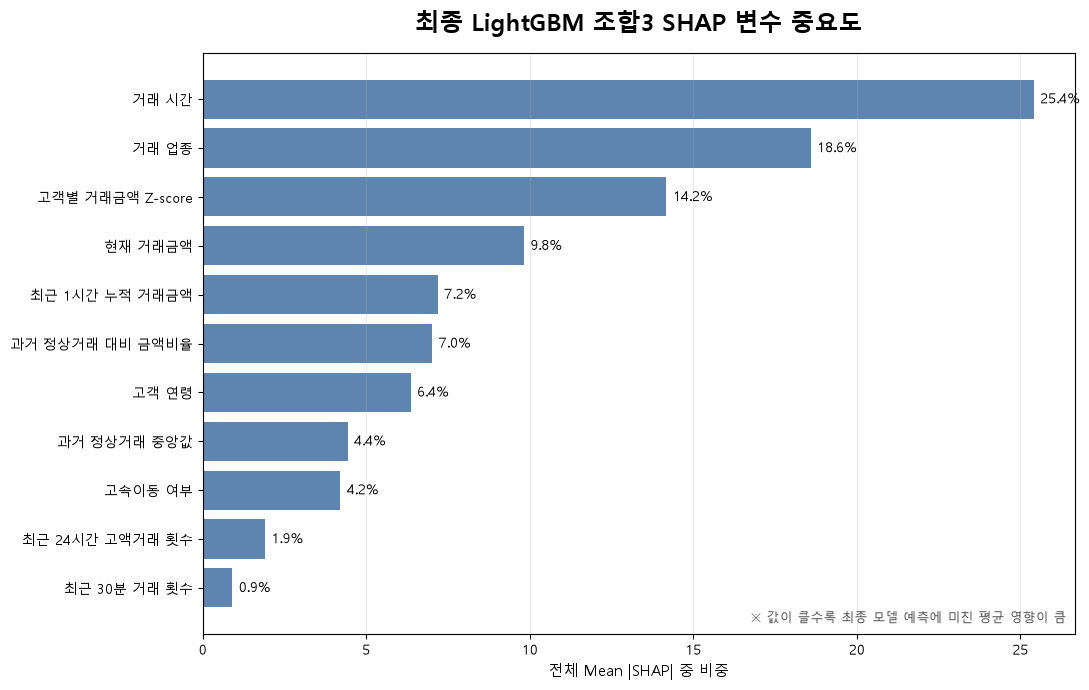

✅ SHAP 변수 중요도 저장 완료
그래프: final_combination3_shap_importance.png
결과표: final_combination3_shap_importance.csv


In [2]:
# ============================================================
# 최종 LightGBM 조합3 SHAP 변수 중요도
# - Ablation·재학습 없음
# - 전체 Train 중 30,000건 표본 사용
# - category는 하나의 원변수로 표시
# ============================================================

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from pathlib import Path


# ------------------------------------------------------------
# 1. 파일 경로
# ------------------------------------------------------------

MODEL_PATH_CANDIDATES = [
    Path("final_lightgbm_combination3.joblib"),
    Path("Modeling/final_lightgbm_combination3.joblib"),
    Path(
        r"C:\Users\splen\OneDrive\Desktop\BDAI_"
        r"\BDAI\Modeling\final_lightgbm_combination3.joblib"
    )
]

DATA_PATH_CANDIDATES = [
    Path("data/fraud_full_features.csv"),
    Path("../data/fraud_full_features.csv"),
    Path(
        r"C:\Users\splen\OneDrive\Desktop\BDAI_"
        r"\BOOSTMAP\Fraud-FDS-Project\data"
        r"\fraud_full_features.csv"
    )
]


def find_existing_path(candidates, file_name):

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"{file_name}을 찾을 수 없습니다.\n"
        "후보 경로:\n"
        + "\n".join(str(path) for path in candidates)
    )


MODEL_PATH = find_existing_path(
    MODEL_PATH_CANDIDATES,
    "최종 LightGBM 모델"
)

DATA_PATH = find_existing_path(
    DATA_PATH_CANDIDATES,
    "fraud_full_features.csv"
)

print("모델 경로:", MODEL_PATH.resolve())
print("데이터 경로:", DATA_PATH.resolve())


# ------------------------------------------------------------
# 2. 최종 모델 불러오기
# ------------------------------------------------------------

final_package = joblib.load(MODEL_PATH)

final_model = final_package["model"]
final_features = final_package["features"]
category_levels = final_package["category_levels"]

expected_features = [
    "category",
    "amt",
    "trans_hour",
    "age",
    "recent_24h_high_amt_count",
    "amt_to_prior_median_ratio",
    "rolling_sum_amt_1h",
    "amt_zscore_card",
    "prior_normal_median_amt",
    "count_30min",
    "high_speed"
]

if final_features != expected_features:
    raise ValueError(
        "저장된 모델의 변수가 확정 조합3과 다릅니다.\n"
        f"저장된 변수: {final_features}"
    )

print("✅ 최종 조합3 변수 11개 일치")
print("트리 수:", final_package["n_estimators"])
print("임계값:", final_package["threshold"])


# ------------------------------------------------------------
# 3. SHAP 분석용 Train 표본 준비
# ------------------------------------------------------------

SHAP_SAMPLE_SIZE = 10_000

train_features = pd.read_csv(
    DATA_PATH,
    usecols=final_features
)

if len(train_features) > SHAP_SAMPLE_SIZE:

    X_shap = train_features.sample(
        n=SHAP_SAMPLE_SIZE,
        random_state=42
    ).copy()

else:
    X_shap = train_features.copy()


# 최종 모델 학습 당시 category 수준과 동일하게 설정
for column, levels in category_levels.items():

    X_shap[column] = pd.Categorical(
        X_shap[column]
        .astype("string")
        .fillna("missing"),
        categories=levels
    )

print("SHAP 분석 표본:", f"{len(X_shap):,}건")


# ------------------------------------------------------------
# 4. SHAP 계산
# ------------------------------------------------------------

explainer = shap.TreeExplainer(
    final_model
)

shap_values = explainer.shap_values(
    X_shap
)


# SHAP 버전별 반환 형식 처리
if isinstance(shap_values, list):

    shap_matrix = np.asarray(
        shap_values[-1]
    )

else:

    shap_matrix = np.asarray(
        shap_values
    )

    # 이진분류 결과가 3차원으로 반환되는 경우
    if shap_matrix.ndim == 3:

        if shap_matrix.shape[-1] == 2:
            shap_matrix = shap_matrix[:, :, 1]

        elif shap_matrix.shape[0] == 2:
            shap_matrix = shap_matrix[1]


if shap_matrix.shape[1] != len(final_features):
    raise ValueError(
        "SHAP 변수 수와 최종 모델 변수 수가 다릅니다.\n"
        f"SHAP shape: {shap_matrix.shape}"
    )


# ------------------------------------------------------------
# 5. Mean absolute SHAP 계산
# ------------------------------------------------------------

mean_abs_shap = np.abs(
    shap_matrix
).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": final_features,
    "mean_abs_shap": mean_abs_shap
})

shap_importance_df[
    "importance_pct"
] = (
    shap_importance_df["mean_abs_shap"]
    / shap_importance_df["mean_abs_shap"].sum()
    * 100
)

shap_importance_df = (
    shap_importance_df
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance_df.insert(
    0,
    "rank",
    range(1, len(shap_importance_df) + 1)
)

display(
    shap_importance_df.style.format({
        "mean_abs_shap": "{:.4f}",
        "importance_pct": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 6. 한글 변수명
# ------------------------------------------------------------

feature_korean_names = {
    "category": "거래 업종",
    "amt": "현재 거래금액",
    "trans_hour": "거래 시간",
    "age": "고객 연령",

    "recent_24h_high_amt_count":
        "최근 24시간 고액거래 횟수",

    "amt_to_prior_median_ratio":
        "과거 정상거래 대비 금액비율",

    "rolling_sum_amt_1h":
        "최근 1시간 누적 거래금액",

    "amt_zscore_card":
        "고객별 거래금액 Z-score",

    "prior_normal_median_amt":
        "과거 정상거래 중앙값",

    "count_30min":
        "최근 30분 거래 횟수",

    "high_speed":
        "고속이동 여부"
}

plot_df = shap_importance_df.copy()

plot_df["feature_korean"] = (
    plot_df["feature"]
    .map(feature_korean_names)
)


# ------------------------------------------------------------
# 7. 발표용 변수 중요도 그래프
# ------------------------------------------------------------

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plot_df = (
    plot_df
    .sort_values(
        "mean_abs_shap",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.barh(
    plot_df["feature_korean"],
    plot_df["importance_pct"],
    color="#4C78A8",
    alpha=0.9
)

ax.set_title(
    "최종 LightGBM 조합3 SHAP 변수 중요도",
    fontsize=17,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "전체 Mean |SHAP| 중 비중",
    fontsize=11
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.25
)


for bar, value in zip(
    bars,
    plot_df["importance_pct"]
):

    ax.text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )


ax.text(
    0.99,
    0.02,
    "※ 값이 클수록 최종 모델 예측에 미친 평균 영향이 큼",
    transform=ax.transAxes,
    ha="right",
    fontsize=9,
    color="#555555"
)

plt.tight_layout()

plt.savefig(
    "final_combination3_shap_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 8. 결과 저장
# ------------------------------------------------------------

shap_importance_df.to_csv(
    "final_combination3_shap_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ SHAP 변수 중요도 저장 완료")
print("그래프: final_combination3_shap_importance.png")
print("결과표: final_combination3_shap_importance.csv")

In [10]:
# =========================================================
# 상관분석 (Pearson vs Spearman)
# =========================================================

import pandas as pd

TARGET = "is_fraud"

FINAL_FEATURES = [
    "category",
    "amt",
    "trans_hour",
    "age",
    "recent_24h_high_amt_count",
    "amt_to_prior_median_ratio",
    "rolling_sum_amt_1h",
    "amt_zscore_card",
    "prior_normal_median_amt",
    "count_30min",
    "high_speed",
]

# category 는 범주형이라 상관분석 대상에서 제외, 나머지 10개 숫자형만 사용
NUMERIC_FEATURES = [c for c in FINAL_FEATURES if c != "category"]


# =========================================================
# 상관검증 함수
# =========================================================
def 상관검증(data, x, y, 상한=None):
    """두 숫자 컬럼의 상관을 4가지 방식으로 검증한다 (pandas만 사용)"""

    결과 = pd.DataFrame(index=["전체"], data={
        "n":        [len(data)],
        "pearson":  [data[x].corr(data[y])],
        "spearman": [data[x].corr(data[y], method="spearman")],
    })

    if 상한 is not None:
        작은 = data[data[y] < 상한]
        결과.loc[f"{y} < {상한:,} 제외"] = [len(작은),
                                        작은[x].corr(작은[y]),
                                        작은[x].corr(작은[y], method="spearman")]

    결과["n"] = 결과["n"].astype(int)
    print(결과.round(3).to_string())

    차 = abs(결과.loc["전체", "pearson"] - 결과.loc["전체", "spearman"])
    print()
    if 차 >= 0.2:
        print(f"⚠️  pearson 과 spearman 차이 {차:.3f} — 극단값 영향이 큽니다. pearson 을 믿지 마세요.")
    else:
        print(f"✅ pearson 과 spearman 차이 {차:.3f} — 안정적입니다.")

    if len(data) < 10:
        print("⚠️  점이 10개 미만입니다. 상관계수를 보고하지 마세요.")


# =========================================================
# 1) 다중공선성 체크 — 최종 10개 숫자형 피처끼리
# =========================================================
print("=" * 60)
print("1. 최종 피처 간 다중공선성 (Pearson)")
print("=" * 60)

corr_matrix = df[NUMERIC_FEATURES].corr()
print(corr_matrix.round(2).to_string())

# |상관계수| >= 0.7 인 쌍만 따로 추출
print("\n[|r| >= 0.7 인 변수쌍]")
strong_pairs = (
    corr_matrix
    .where(lambda x: (x.abs() >= 0.7) & (x.abs() < 1.0))
    .stack()
    .dropna()
    .reset_index()
)
strong_pairs.columns = ["var1", "var2", "corr"]
strong_pairs = strong_pairs[strong_pairs["var1"] < strong_pairs["var2"]]

if strong_pairs.empty:
    print("없음 — 다중공선성 우려되는 변수쌍 없음")
else:
    print(strong_pairs.round(3).to_string(index=False))


# =========================================================
# 2) 피처 x is_fraud 상관 — pearson vs spearman
#    amt 계열은 이상치가 크므로 상한 지정해서 이상치 제외 버전도 같이 확인
# =========================================================
print("\n" + "=" * 60)
print("2. 피처 x is_fraud 상관 (Pearson vs Spearman)")
print("=" * 60)

# amt 관련 변수는 이상치 영향이 큰 게 특징이라 상한을 따로 지정
상한_설정 = {
    "amt": df["amt"].quantile(0.99),
    "rolling_sum_amt_1h": df["rolling_sum_amt_1h"].quantile(0.99),
    "prior_normal_median_amt": df["prior_normal_median_amt"].quantile(0.99),
}


for feature in NUMERIC_FEATURES:
    print(f"\n[{feature} ~ {TARGET}]")
    상관검증(df, TARGET, feature, 상한=상한_설정.get(feature))  # x=TARGET, y=feature
    print("-" * 60)


# =========================================================
# 3) 선형 상관 거의 없는 변수 재검증 — pd.cut + groupby 로 비선형 확인
#    (2번 결과 보고 |pearson| < 0.05 근처인 변수만 골라서 채워 넣기)
# =========================================================
print("\n" + "=" * 60)
print("3. 비선형 관계 재확인 (구간화 후 fraud_rate)")
print("=" * 60)

# 예시: trans_hour, count_30min — PPT에서 이미 비선형(야간 급등, 30분 재사용 급등) 확인된 변수들
빈_구간_설정 = {
    "trans_hour": range(0, 25, 2),          # 2시간 단위
    "count_30min": [0, 1, 2, 3, 5, 10, 100],  # 재사용 횟수 구간
}

for feature, bins in 빈_구간_설정.items():
    print(f"\n[{feature} 구간별 fraud_rate]")
    임시 = df.copy()
    임시["구간"] = pd.cut(임시[feature], bins=bins, right=False)
    구간별 = (
        임시.groupby("구간", observed=True)[TARGET]
        .agg(거래건수="count", 이상거래건수="sum")
    )
    구간별["fraud_rate_pct"] = (구간별["이상거래건수"] / 구간별["거래건수"] * 100).round(4)
    print(구간별.to_string())

1. 최종 피처 간 다중공선성 (Pearson)
                            amt  trans_hour   age  recent_24h_high_amt_count  amt_to_prior_median_ratio  rolling_sum_amt_1h  amt_zscore_card  prior_normal_median_amt  count_30min  high_speed
amt                        1.00       -0.02 -0.01                       0.11                       0.90                0.87             0.52                     0.07        -0.02       -0.01
trans_hour                -0.02        1.00 -0.17                       0.02                      -0.02                0.00            -0.01                    -0.05         0.21        0.12
age                       -0.01       -0.17  1.00                      -0.02                      -0.01               -0.02             0.00                    -0.05         0.01       -0.06
recent_24h_high_amt_count  0.11        0.02 -0.02                       1.00                       0.10                0.26             0.04                     0.03        -0.00        0.03
amt_to_prior_media

In [11]:
# =========================================================
# 상관분석 시각화 
# - df, NUMERIC_FEATURES, TARGET, corr_matrix, 상한_설정, 빈_구간_설정 재사용
# =========================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# Windows 한글 폰트 (맥이면 'AppleGothic'으로 변경)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 1) 다중공선성 히트맵
# =========================================================
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(NUMERIC_FEATURES)))
ax.set_yticks(range(len(NUMERIC_FEATURES)))
ax.set_xticklabels(NUMERIC_FEATURES, rotation=45, ha="right")
ax.set_yticklabels(NUMERIC_FEATURES)

for i in range(len(NUMERIC_FEATURES)):
    for j in range(len(NUMERIC_FEATURES)):
        value = corr_matrix.iloc[i, j]
        color = "white" if abs(value) >= 0.6 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                color=color, fontsize=8)

ax.set_title("최종 피처 간 다중공선성 (Pearson)", fontsize=13, pad=12)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig("corr_heatmap.png", dpi=300, bbox_inches="tight")
plt.close(fig)


# =========================================================
# 2) 피처별 pearson vs spearman 비교 막대그래프
#    (전체 데이터 기준 값 재계산)
# =========================================================
compare_rows = []
for feature in NUMERIC_FEATURES:
    compare_rows.append({
        "feature": feature,
        "pearson": df[feature].corr(df[TARGET]),
        "spearman": df[feature].corr(df[TARGET], method="spearman"),
    })

compare_df = pd.DataFrame(compare_rows).set_index("feature")
compare_df = compare_df.reindex(
    compare_df["pearson"].abs().sort_values(ascending=True).index
)

fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(compare_df))
bar_height = 0.35

ax.barh(y_pos - bar_height / 2, compare_df["pearson"], height=bar_height,
        label="Pearson", color="#4C72B0")
ax.barh(y_pos + bar_height / 2, compare_df["spearman"], height=bar_height,
        label="Spearman", color="#DD8452")

ax.set_yticks(y_pos)
ax.set_yticklabels(compare_df.index)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("is_fraud 과의 상관계수")
ax.set_title("피처 x is_fraud : Pearson vs Spearman", fontsize=13, pad=12)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("pearson_spearman_compare.png", dpi=300, bbox_inches="tight")
plt.close(fig)


# =========================================================
# 3) trans_hour 구간별 fraud_rate (비선형 확인)
# =========================================================
trans_hour_grouped = (
    df.assign(구간=pd.cut(df["trans_hour"], bins=빈_구간_설정["trans_hour"], right=False))
    .groupby("구간", observed=True)[TARGET]
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(8, 5))
labels = [str(interval) for interval in trans_hour_grouped.index]
bars = ax.bar(labels, trans_hour_grouped.values, color="#C44E52")
ax.set_ylabel("fraud_rate (%)")
ax.set_xlabel("거래 시간대 (2시간 단위)")
ax.set_title("trans_hour 구간별 이상거래율\n(선형상관 r=0.014, 실제로는 야간 급등)", fontsize=12, pad=12)
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}%",
            ha="center", va="bottom", fontsize=8)

fig.tight_layout()
fig.savefig("trans_hour_nonlinear.png", dpi=300, bbox_inches="tight")
plt.close(fig)


# =========================================================
# 4) count_30min 구간별 fraud_rate (비선형 확인)
# =========================================================
count_30min_grouped = (
    df.assign(구간=pd.cut(df["count_30min"], bins=빈_구간_설정["count_30min"], right=False))
    .groupby("구간", observed=True)
    .agg(거래건수=(TARGET, "count"), fraud_rate=(TARGET, "mean"))
)
count_30min_grouped["fraud_rate"] *= 100

fig, ax = plt.subplots(figsize=(8, 5))
labels = [str(interval) for interval in count_30min_grouped.index]
bars = ax.bar(labels, count_30min_grouped["fraud_rate"], color="#55A868")
ax.set_ylabel("fraud_rate (%)")
ax.set_xlabel("count_30min 구간")
ax.set_title("count_30min 구간별 이상거래율\n(선형상관 r=-0.023, 실제로는 U자형)", fontsize=12, pad=12)

for bar, n in zip(bars, count_30min_grouped["거래건수"]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}%\n(n={n})",
            ha="center", va="bottom", fontsize=8)

fig.tight_layout()
fig.savefig("count_30min_nonlinear.png", dpi=300, bbox_inches="tight")
plt.close(fig)

print("저장 완료: corr_heatmap.png, pearson_spearman_compare.png, trans_hour_nonlinear.png, count_30min_nonlinear.png")

저장 완료: corr_heatmap.png, pearson_spearman_compare.png, trans_hour_nonlinear.png, count_30min_nonlinear.png


In [12]:
# =========================================================
# 이상치 제외 전후 상관계수 비교 시각화 (PPT 삽입용)
# - df, TARGET, 상한_설정 재사용
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

OUTLIER_FEATURES = ["amt", "rolling_sum_amt_1h", "prior_normal_median_amt"]

rows = []
for feature in OUTLIER_FEATURES:
    cap = 상한_설정[feature]
    subset = df[df[feature] < cap]

    rows.append({
        "feature": feature,
        "pearson_전체": df[feature].corr(df[TARGET]),
        "pearson_제외": subset[feature].corr(subset[TARGET]),
        "spearman_전체": df[feature].corr(df[TARGET], method="spearman"),
        "spearman_제외": subset[feature].corr(subset[TARGET], method="spearman"),
    })

outlier_df = pd.DataFrame(rows).set_index("feature")
print(outlier_df.round(3).to_string())


# =========================================================
# 시각화: 변수별 4개 막대 (pearson 전체/제외, spearman 전체/제외)
# =========================================================
fig, axes = plt.subplots(1, len(OUTLIER_FEATURES), figsize=(13, 5), sharey=True)

bar_labels = ["Pearson\n(전체)", "Pearson\n(상위1% 제외)", "Spearman\n(전체)", "Spearman\n(상위1% 제외)"]
bar_colors = ["#4C72B0", "#8CA9D6", "#DD8452", "#F0B98D"]

for ax, feature in zip(axes, OUTLIER_FEATURES):
    values = [
        outlier_df.loc[feature, "pearson_전체"],
        outlier_df.loc[feature, "pearson_제외"],
        outlier_df.loc[feature, "spearman_전체"],
        outlier_df.loc[feature, "spearman_제외"],
    ]
    bars = ax.bar(bar_labels, values, color=bar_colors)
    ax.set_title(feature, fontsize=11)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.tick_params(axis="x", labelsize=8)

    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}",
                ha="center", va="bottom" if value >= 0 else "top", fontsize=8)

axes[0].set_ylabel("is_fraud 과의 상관계수")
fig.suptitle("이상치(상위 1%) 제외 전후 상관계수 변화", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("outlier_effect_compare.png", dpi=300, bbox_inches="tight")
plt.close(fig)

print("\n저장 완료: outlier_effect_compare.png")

                         pearson_전체  pearson_제외  spearman_전체  spearman_제외
feature                                                                  
amt                           0.219       0.102        0.088        0.036
rolling_sum_amt_1h            0.337       0.094        0.098        0.037
prior_normal_median_amt       0.001       0.002        0.000        0.000

저장 완료: outlier_effect_compare.png


In [ ]:
# =========================================================
# trans_hour(야간 급등)이 category 구성 때문인지 확인
# =========================================================

import pandas as pd

# 앞에서 확인한 야간 구간(22~24시, 0~4시)을 기준으로 이진 변수 생성
df["is_night"] = df["trans_hour"].apply(lambda h: 1 if (h >= 22 or h < 4) else 0)


# =========================================================
# 1) 야간 vs 주간, category 구성비가 다른지 확인
#    (구성이 같다면 심슨의 역설 후보에서 제외)
# =========================================================
print("=" * 60)
print("1. 야간 vs 주간 category 구성비 (열 기준 %)")
print("=" * 60)

구성비 = pd.crosstab(df["category"], df["is_night"], normalize="columns") * 100
구성비.columns = ["주간(%)", "야간(%)"]
구성비["차이(야간-주간)"] = 구성비["야간(%)"] - 구성비["주간(%)"]
print(구성비.round(2).sort_values("차이(야간-주간)", ascending=False).to_string())


# =========================================================
# 2) 전체 기준 야간 vs 주간 fraud_rate (참고용, 이미 확인한 숫자)
# =========================================================
print("\n" + "=" * 60)
print("2. 전체 기준 야간 vs 주간 fraud_rate")
print("=" * 60)

전체비교 = df.groupby("is_night")[TARGET].agg(거래건수="count", fraud_rate="mean")
전체비교["fraud_rate"] = (전체비교["fraud_rate"] * 100).round(4)
전체비교.index = ["주간", "야간"]
print(전체비교.to_string())


# =========================================================
# 3) 핵심 — category 고정하고 야간/주간 fraud_rate 비교
#    within-category로도 야간이 여전히 높은지 확인
# =========================================================
print("\n" + "=" * 60)
print("3. category별 야간 vs 주간 fraud_rate (핵심)")
print("=" * 60)

건수 = df.groupby(["category", "is_night"])[TARGET].count().unstack()
비율 = df.groupby(["category", "is_night"])[TARGET].mean().unstack() * 100

결과 = pd.DataFrame({
    "주간_건수": 건수[0],
    "야간_건수": 건수[1],
    "주간_fraud_rate": 비율[0].round(4),
    "야간_fraud_rate": 비율[1].round(4),
})
결과["야간-주간_차이"] = (결과["야간_fraud_rate"] - 결과["주간_fraud_rate"]).round(4)

print(결과.sort_values("야간-주간_차이", ascending=False).to_string())

# 표본이 너무 작은 셀(30건 미만) 경고
작은표본 = 결과[(결과["주간_건수"] < 30) | (결과["야간_건수"] < 30)]
if not 작은표본.empty:
    print("\n⚠️ 표본 30건 미만이라 신뢰하기 어려운 category:")
    print(작은표본.index.tolist())

1. 야간 vs 주간 category 구성비 (열 기준 %)
                주간(%)  야간(%)  차이(야간-주간)
category                               
gas_transport    8.82  14.49       5.67
grocery_pos      8.25  13.72       5.47
misc_net         4.40   6.45       2.05
grocery_net      3.04   5.02       1.98
misc_pos         5.92   6.88       0.97
shopping_net     7.39   7.94       0.55
shopping_pos     9.01   8.95      -0.06
travel           3.39   2.25      -1.14
entertainment    7.61   6.08      -1.53
food_dining      7.49   5.63      -1.86
health_fitness   7.22   4.67      -2.55
personal_care    7.62   4.97      -2.65
kids_pets        9.49   6.21      -3.28
home            10.34   6.73      -3.61

2. 전체 기준 야간 vs 주간 fraud_rate
      거래건수  fraud_rate
주간  991793      0.1153
야간  304882      2.0867

3. category별 야간 vs 주간 fraud_rate (핵심)
                 주간_건수  야간_건수  주간_fraud_rate  야간_fraud_rate  야간-주간_차이
category                                                             
shopping_net     73322  24221         0.3519    

In [ ]:
# =========================================================
# — amt-is_fraud 상관이 category별로 반전되는지 확인
# =========================================================

import pandas as pd

TARGET = "is_fraud"

# =========================================================
# 1) 전체 기준 amt-is_fraud 상관 (참고, 이미 확인한 값)
# =========================================================
print("=" * 60)
print("1. 전체 기준 amt ~ is_fraud")
print("=" * 60)
전체_pearson = df["amt"].corr(df[TARGET])
전체_spearman = df["amt"].corr(df[TARGET], method="spearman")
print(f"pearson={전체_pearson:.3f}, spearman={전체_spearman:.3f}")


# =========================================================
# 2) category 고정하고 amt ~ is_fraud 상관 재계산 (핵심)
# =========================================================
print("\n" + "=" * 60)
print("2. category별 amt ~ is_fraud 상관 (핵심)")
print("=" * 60)

rows = []
for category, group in df.groupby("category"):
    rows.append({
        "category": category,
        "거래건수": len(group),
        "평균amt": group["amt"].mean(),
        "fraud_rate_pct": group[TARGET].mean() * 100,
        "pearson": group["amt"].corr(group[TARGET]),
        "spearman": group["amt"].corr(group[TARGET], method="spearman"),
    })

결과 = pd.DataFrame(rows).set_index("category")
결과 = 결과.sort_values("pearson", ascending=False)
print(결과.round(3).to_string())

# 부호가 전체(양수)와 반대인 category만 따로 표시
반전 = 결과[결과["pearson"] < 0]
print("\n[전체와 부호가 반대인 category — pearson 음수]")
if 반전.empty:
    print("없음")
else:
    print(반전.round(3).to_string())

1. 전체 기준 amt ~ is_fraud
pearson=0.219, spearman=0.088

2. category별 amt ~ is_fraud 상관 (핵심)
                  거래건수    평균amt  fraud_rate_pct  pearson  spearman
category                                                          
misc_net         63287   80.865           1.446    0.520     0.204
shopping_net     97543   88.424           1.756    0.493     0.223
grocery_pos     123638  116.961           1.410    0.438     0.204
entertainment    94014   64.210           0.248    0.331     0.086
shopping_pos    116672   79.779           0.723    0.294     0.143
home            123115   58.270           0.161    0.164     0.068
misc_pos         79655   62.891           0.314    0.065     0.019
food_dining      91461   51.087           0.165    0.057     0.058
travel           40507  111.505           0.286   -0.009     0.041
personal_care    90758   47.968           0.242   -0.022    -0.014
health_fitness   85879   54.182           0.155   -0.028    -0.029
kids_pets       113035   57.537       

In [ ]:
# =========================================================
# 심슨의 역설 시각화
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

전체_pearson = df["amt"].corr(df[TARGET])

plot_df = 결과.sort_values("pearson", ascending=True)
colors = ["#4C72B0" if v < 0 else "#C44E52" for v in plot_df["pearson"]]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(plot_df.index, plot_df["pearson"], color=colors)

# 전체(pooled) 상관계수 기준선
ax.axvline(전체_pearson, color="black", linestyle="--", linewidth=1.2,
           label=f"전체(pooled) pearson = {전체_pearson:.3f}")
ax.axvline(0, color="gray", linewidth=0.8)

x_min = plot_df["pearson"].min()
x_max = plot_df["pearson"].max()
x_range = x_max - x_min
xlim_low = x_min - x_range * 0.28
xlim_high = x_max + x_range * 0.28
ax.set_xlim(xlim_low, xlim_high)

for bar, value, n in zip(bars, plot_df["pearson"], plot_df["거래건수"]):
    x = value + (x_range * 0.015 if value >= 0 else -x_range * 0.015)
    ha = "left" if value >= 0 else "right"
    ax.text(x, bar.get_y() + bar.get_height() / 2, f"{value:.3f} (n={n:,})",
            va="center", ha=ha, fontsize=8, clip_on=True)

ax.set_xlabel("category 내부 amt~is_fraud 상관계수 (pearson)")
ax.set_title("심슨의 역설: amt~is_fraud 상관, category로 쪼개면 방향이 바뀐다", fontsize=13, pad=12)
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig("simpsons_paradox_amt_category.png", dpi=300, bbox_inches="tight")
plt.close(fig)

print("저장 완료: simpsons_paradox_amt_category.png")

저장 완료: simpsons_paradox_amt_category.png
